# CREDIT CARD CUSTOMER SEGMENTATION

## PROBLEM DEFINITION

**Context**

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help









**Objective**

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

**Data Description**

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

**Data Dictionary**

* Sl_No: Primary key of the records
* Customer Key: Customer identification number
* Average Credit Limit: Average credit limit of each customer for all credit   cards
* Total credit cards: Total number of credit cards possessed by the customer
* Total visits bank: Total number of visits that the customer made (yearly) personally to the bank
* Total visits online: Total number of visits or online logins made by the customer (yearly)
* Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

##  Import necessary libraries

In [ ]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manupulating data
import pandas as pd
import numpy as np

# libraries to help with data visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# libraries to split data
from sklearn.model_selection import train_test_split

# Libraries to impute missing values
from sklearn.impute import SimpleImputer


## Reading the dataset

In [ ]:
CreditCardCustomerData = pd.read_excel('Credit Card Customer Data.xlsx')

# copying data to another variable to avoid changes to the original data
data = CreditCardCustomerData.copy()

## Overview of the dataset

### Displaying the first and last 10 rows of the dataset

In [ ]:
data.head(10)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
5,6,58634,20000,3,0,1,8
6,7,48370,100000,5,0,11,2
7,8,37376,15000,3,0,1,1
8,9,82490,5000,2,0,2,2
9,10,44770,3000,4,0,1,7


In [ ]:
data.tail(10)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
650,651,78996,195000,10,1,12,2
651,652,78404,132000,9,1,12,2
652,653,28525,156000,8,1,8,0
653,654,51826,95000,10,0,15,1
654,655,65750,172000,10,1,9,1
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [ ]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
547,548,38125,26000,4,5,2,4
353,354,94437,9000,5,4,1,3
499,500,65825,68000,6,4,2,2
173,174,38410,9000,2,1,5,8
241,242,81878,10000,4,5,1,3
341,342,70779,18000,4,3,2,0
647,648,79953,183000,9,0,9,2
218,219,28208,19000,3,1,5,7
120,121,16577,10000,4,2,4,6
134,135,31256,13000,4,1,5,7


### Understand the shape of the dataset.

In [ ]:
data.shape

(660, 7)

 There are 660 observations  and 7 columns in the dataset.

### Check the data types of the columns for the dataset.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


* All 7 Features are of Numerical Type.  
* There is no missing value in the dataset.
Here is a professional observation you can use for your notebook to justify the removal of the `Sl_No` and `Customer Key` features:

**Key Observations: Sl_No and Customer Key**

* **Administrative Identifiers:** Both `Sl_No` (Serial Number) and `Customer Key` serve strictly as unique administrative identifiers for the individual records and customers within the dataset.
* **Lack of Predictive Value:** Neither feature contains any underlying behavioral, financial, or demographic significance. They represent arbitrary indexing and system-generated IDs rather than measurable attributes or varying patterns that describe customer profiles.
* **Impact on Machine Learning Models:** Distance-based algorithms, such as K-Means clustering, rely on the magnitude and variance of numerical data to calculate similarity and form segments. Including unique identifiers introduces mathematical noise, as the algorithm might incorrectly interpret these sequential or random IDs as meaningful numerical weights, which would artificially skew and distort the cluster formations.
* **Pre-processing Action:** Because these features offer no analytical value for exploratory data analysis or predictive modeling, both `Sl_No` and `Customer Key` will be permanently dropped from the dataset during the initial data cleaning phase prior to model training.

In [ ]:
# let's check for duplicate observations
data.duplicated().sum()

np.int64(0)

### Summary of the dataset

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0





**Key Observations: Avg_Credit_Limit**

* **Highly Right-Skewed Distribution:** The distribution exhibits a strong right skew, clearly evidenced by the mean (34,574) significantly surpassing the median (18,000). This indicates a large concentration of customers with lower credit limits, accompanied by a long tail of high-limit customers.
* **High Variance and Spread:** The standard deviation (37,625) is larger than the mean itself, highlighting massive variation in credit limits across the customer base. The limits range from a minimum of 3,000 all the way up to a maximum of 200,000.
* **Genuine Extreme Values (Business Context):** While statistical outliers exist on the higher end (up to 200,000), these represent a genuine, highly affluent customer segment rather than erroneous data entry. Discarding these data points would result in the permanent loss of a highly valuable, high-earning cohort from our segmentation analysis.
* **Expected Correlation:** From a business standpoint, we anticipate a positive relationship between `Avg_Credit_Limit` and `Total_Credit_Cards`, as customers with higher spending power are typically issued higher limits and a greater number of cards. This should be verified during bivariate analysis.
* **Pre-processing Recommendation:** Because distance-based clustering algorithms (like K-Means) are highly sensitive to extreme values, we must handle this skewness carefully. To retain our high-value customers without distorting the clusters, we recommend applying a data transformation technique (such as Log Transformation) or utilizing Robust Scaling to normalize the distribution before modeling.




**Key Observations: Total_Credit_Cards**

* **Slightly Left-Skewed Distribution:** The distribution exhibits a slight left skew, as the mean (approximately 4.71) is slightly lower than the median (5.0). This indicates that the majority of the customer base leans toward holding 5 or more credit cards, pulling the center of the distribution slightly to the right of the mean.
* **Low Variance and Expected Spread:** The standard deviation (2.17) is relatively small, showing a tight and expected spread of data. The majority of customers fall within the interquartile range (the 25th to 75th percentiles), holding between 3 and 6 credit cards.
* **High-End Values (Business Context):** The maximum number of credit cards held by a single customer is 10. In a business context, holding such a high number of credit cards is a strong indicator of high earners or individuals with significant spending power and creditworthiness.
* **Expected Correlation:** We hypothesize that the customers holding the maximum number of cards (up to 10) are the same individuals driving the extreme values in the `Avg_Credit_Limit` column. We will verify this relationship during bivariate analysis (using a scatter plot and correlation coefficient) to confirm the link between credit limit and the number of cards issued.

 **Pre-processing Recommendations: Total_Credit_Cards**

* **Outlier Treatment Not Required:** The maximum value of 10 credit cards is a completely valid and logically sound data point within a business context. Therefore, outlier handling or capping is unnecessary for this column.
* **Scaling is Mandatory:** Distance-based clustering algorithms (such as K-Means) are highly sensitive to the magnitude of variables because they rely on calculating the physical distance between data points.
* **Risk of Feature Dominance:** `Total_Credit_Cards` operates on a very narrow scale (ranging from 1 to 10), whereas features like `Avg_Credit_Limit` possess massive ranges (from 3,000 to 200,000). If left unscaled, features with larger magnitudes will disproportionately dominate the distance calculations, rendering smaller-scale features virtually irrelevant in the model.
* **Actionable Recommendation:** Applying Standard Scaling (Z-score normalization) or Min-Max Scaling across all numerical features is strictly necessary prior to modeling. This step guarantees that equal weight is given to all features during segment formation, preventing high-magnitude variables from distorting the clusters.

**Key Observations: Total_visits_bank**

* **Central Tendency & Skewness:** The mean number of bank visits is approximately 2.40, which is slightly higher than the median of 2.0. This suggests a very slight rightward skew, though the data remains fairly central within its limited range.
* **Data Spread & Interquartile Range (IQR):** The standard deviation is 1.63, indicating moderate variability across the customer base. The middle 50% of customers (from the 25th to the 75th percentile) visit the branch between 1 and 4 times annually.
* **Minimum and Maximum Behaviors:** The yearly visits range from a minimum of 0 to a maximum of 5. The minimum value of 0 highlights that a specific segment of customers never visits the bank in person, indicating they likely rely exclusively on alternative channels like online portals or call centers.

* **Channel Preference & Behavioral Shift:** The maximum number of yearly bank visits by any single customer is capped at 5. Notably, this is the lowest maximum engagement across all communication channels (compared to peaks of 15 for online visits and 10 for calls). This comparatively low ceiling strongly indicates a behavioral shift away from traditional in-person banking, suggesting customers find remote mediums (digital or telephone) more efficient and preferable for query resolution.
* **Pre-processing Recommendation (Scaling):** Because this feature operates on a highly constrained numerical scale (0 to 5), it must be scaled prior to applying distance-based clustering algorithms. Without standardization (e.g., Z-score normalization) or Min-Max scaling, this feature's impact on defining customer segments will be entirely overshadowed by high-magnitude features like `Avg_Credit_Limit`.

**Key Observations: Total visits online**

* **Distribution Characteristics:** The data exhibits a slightly right-skewed distribution. This is evidenced by the mean (approximately 2.6) exceeding the median (2.0), indicating that the average is being pulled upward by higher frequency values.
* **Outlier Identification:** There is a substantial jump from the 75th percentile (4 visits) to the maximum recorded value (15 visits). This significant spread highlights the presence of outliers on the upper end, which are responsible for drifting the mean to the right of the median.
* **Channel Substitution:** A minimum value of zero demonstrates that a portion of the customer base entirely bypasses digital channels. This suggests a substitution effect where these individuals prefer alternative communication methods, such as in-person bank visits or phone calls.
* **High Digital Engagement:** When comparing maximum interaction frequencies across channels, online visits hold the highest peak (15 visits), significantly outpacing in-person bank visits (maximum of 5) and phone calls (maximum of 10). This indicates the existence of a distinct customer segment that is highly engaged and notably more comfortable interacting online rather than utilizing traditional offline touchpoints.

**Key Observations: Total_calls_made**

* **Distribution Characteristics:** The distribution exhibits a slight right skew, as evidenced by the mean (approximately 3.58) being higher than the median (3.0). This indicates that while the majority of customers make a lower volume of calls, a smaller segment with high call frequencies pulls the overall average upward.
* **Data Spread and Variability:** The interquartile range demonstrates that the middle 50% of the customer base makes between 1 and 5 calls annually, with a standard deviation of 2.86 indicating moderate variability in how often customers rely on phone support.
* **Channel Substitution:** A minimum recorded value of 0 highlights that a segment of the customer base completely bypasses phone communication. This suggests these customers either have no need for direct support or prefer to utilize alternative channels, such as online banking or in-person branch visits.
* **High-End Interaction:** The maximum number of calls made by a single customer is 10. When compared across channels, maximum phone engagement sits firmly between in-person branch visits (maximum 5) and online visits (maximum 15). This points to a distinct customer segment that heavily relies on direct, verbal communication with customer service for inquiries or issue resolution.

## EXPLORATORY DATA ANALYSIS

### Univariate Analysis

### Numerical Variables

In [ ]:
def histogram_boxplot(data, feature, figsize=(20, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots

    # boxplot will be created and a triangle will indicate the mean value of the column
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )

    # For histogram
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    # Add median to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

    plt.tight_layout()
    plt.show()



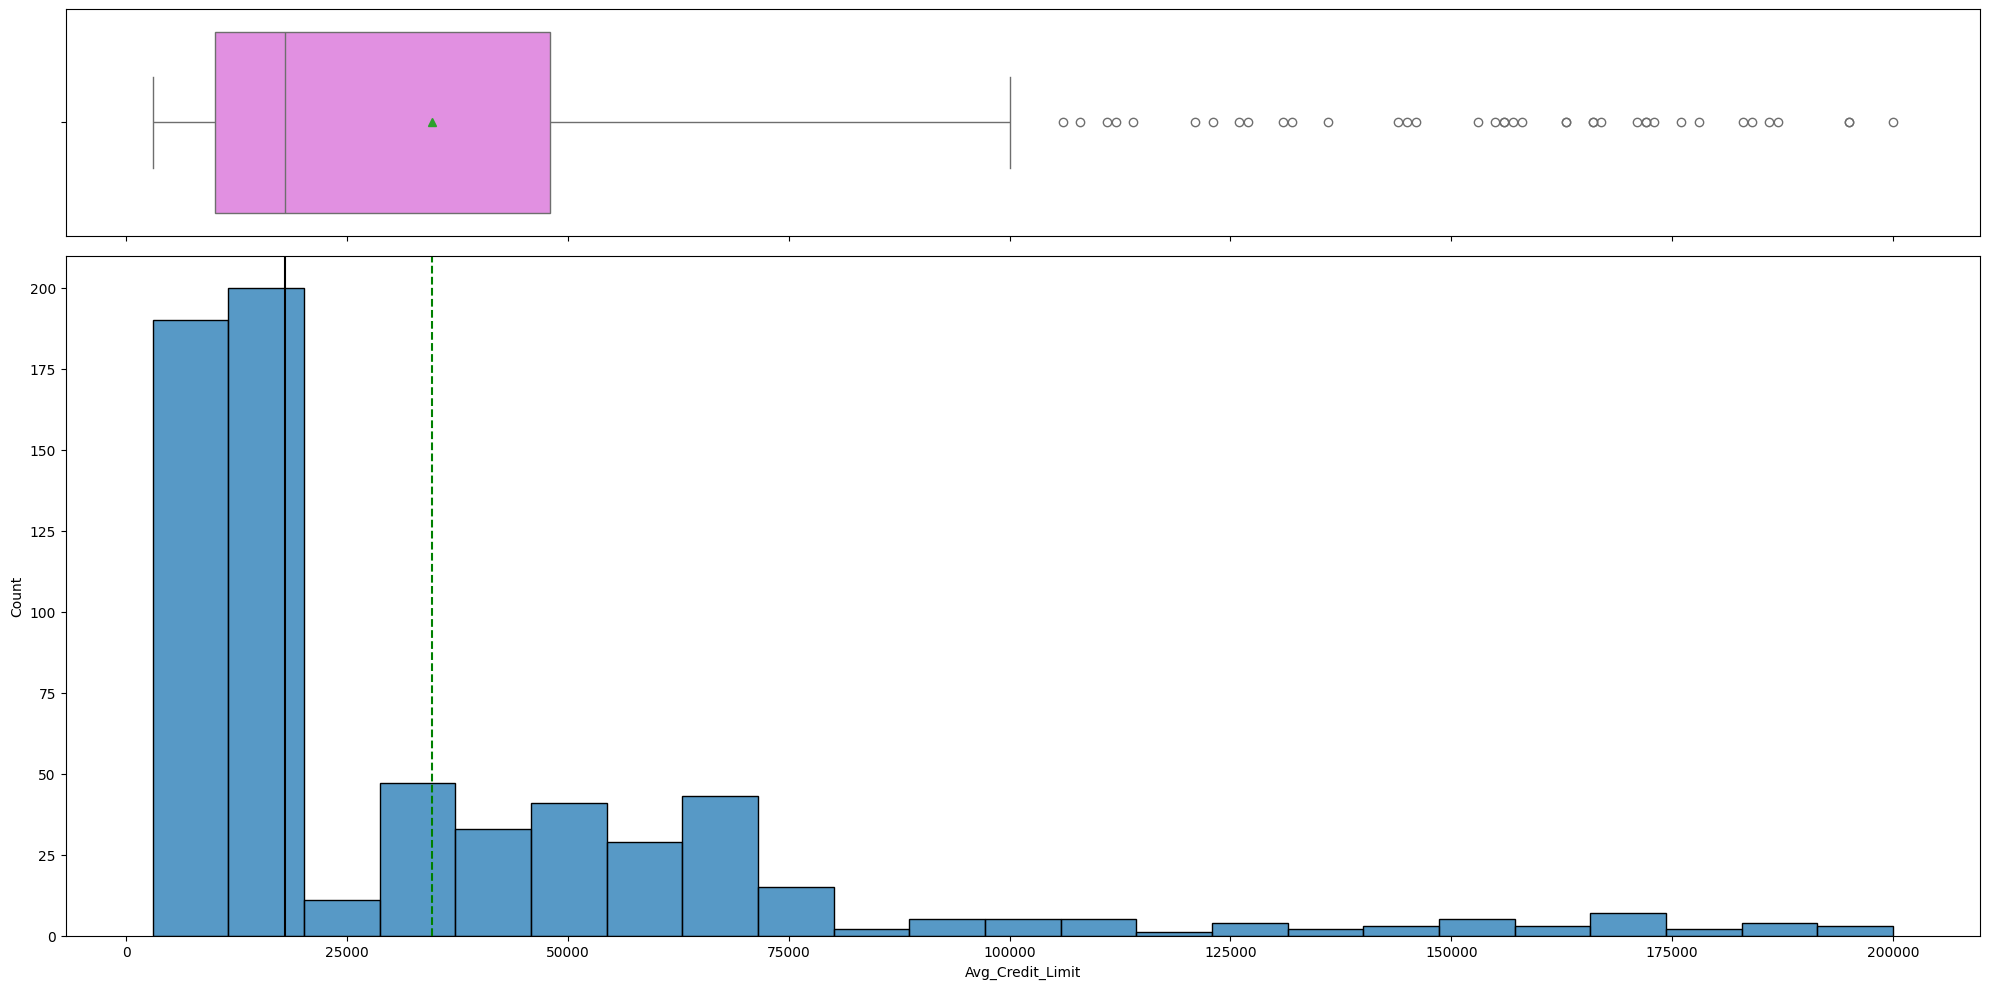

In [ ]:
# Call the previously defined histogram_boxplot function for Avg_Credit_Limit
histogram_boxplot(data, 'Avg_Credit_Limit')



**Visual Observations: Avg_Credit_Limit**

* **Sharp Frequency Drop-Off:** There is an immediate and dramatic drop in customer count after the first major bin. The vast majority of the customer base (around 400 individuals) is heavily packed into the lowest credit limit ranges (roughly under 25,000), after which the frequency plummets abruptly rather than tapering off gradually.

* **Dense Outlier Population (Boxplot):** The boxplot displays a thick, continuous line of individual outlier points extending beyond the upper whisker (starting roughly around the 100,000 mark). This visually emphasizes that the high-limit customers aren't just a handful of rare anomalies, but a solid, consistent sub-segment of the portfolio.

* **Business Insights Regarding Extreme Values:** While statistical outliers exist on the upper end of the spectrum, these values represent a genuine, highly affluent customer segment rather than erroneous data entry. Preserving these data points is crucial, as they identify a valuable, high-earning cohort essential for effective customer segmentation and targeted marketing strategies.
* **Tiered Limit Assignments:** In the long right tail of the histogram (from 100,000 up to 200,000), the data isn't perfectly smooth. There are slight "bumps" or small clusters at specific intervals. This reflects typical banking practices where premium credit limits are often assigned in standardized, rounded tiers (e.g., 100k, 150k, 175k) rather than continuous, arbitrary amounts.
* **Clustering Implications and Data Pre-processing:** Because distance-based clustering algorithms, such as K-Means, are highly sensitive to the magnitude and variance of attributes, the skewness and broad range of this feature must be addressed. To ensure that high-value customers contribute meaningfully without disproportionately dominating the distance calculations and distorting the resulting clusters, applying a data transformation—such as a logarithmic transformation—or utilizing robust scaling techniques is strictly recommended prior to model training.


In [ ]:
def histogram_boxplot_discrete(data, feature, figsize=(10, 6), kde=False):
    """
    Boxplot and histogram combined, specifically tailored for discrete integer data.
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10, 6))
    kde: whether to show the density curve (default False)
    """
    f, (ax_box, ax_hist) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    ) # creating the 2 subplots

    # boxplot will be created and a triangle will indicate the mean value of the column
    sns.boxplot(
        data=data, x=feature, ax=ax_box, showmeans=True, color="violet"
    )

    # For histogram - WITH discrete=True enabled
    sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist, discrete=True)

    # Add mean to the histogram
    ax_hist.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )

    # Add median to the histogram
    ax_hist.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# histogram_boxplot_discrete(data, 'Total_Credit_Cards')
# histogram_boxplot_discrete(data, 'Total_visits_bank')

Total_Credit_Cards

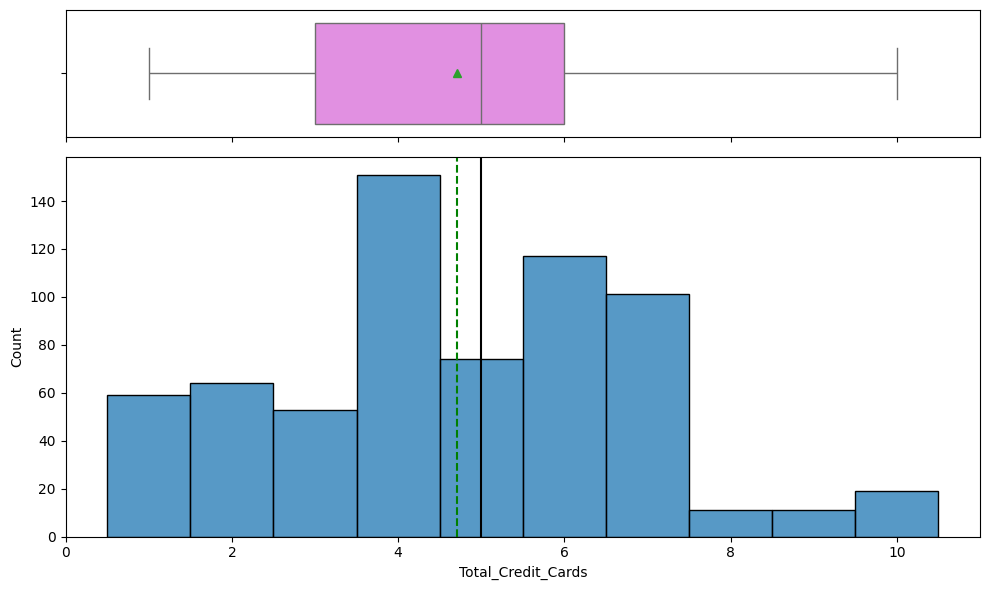

In [ ]:
histogram_boxplot_discrete(data, 'Total_Credit_Cards')

**Key Observations: Total_Credit_Cards**

*   **Distributional Characteristics:** The distribution exhibits a slight leftward skew, as evidenced by the mean (approximately 4.71) being marginally lower than the median (5.0). This indicates that the majority of the customer base leans toward holding 5 or more credit cards, pulling the center of the distribution slightly to the right of the mean.

*   **Data Spread and Variability:** The standard deviation of 2.17 is relatively small, showcasing a tight and expected spread of the data. The majority of customers fall within the interquartile range, typically holding between 3 and 6 credit cards.

*   **High-End Values (Business Context):** The maximum number of credit cards held by a single customer is capped at 10. In a business context, holding such a high volume of credit cards is a strong indicator of high earners or individuals with significant spending power and excellent creditworthiness.

*   **Outlier Treatment Not Required:** The maximum value of 10 credit cards is a completely valid and logically sound data point within a real-world business setting and does not represent an error. Therefore, outlier capping or removal is unnecessary for this column.

*   **Pre-processing Recommendation:** Because distance-based clustering algorithms, such as K-Means, are highly sensitive to the magnitude of variables, this feature must be scaled prior to modeling. The Total_Credit_Cards column operates on a highly constrained scale (1 to 10), whereas features like Avg_Credit_Limit possess a massive range (up to 200,000). Applying Standard Scaling or Min-Max Scaling across all numerical features is strictly necessary to prevent high-magnitude variables from disproportionately dominating the distance calculations and distorting the final cluster formations.

Total_visits_bank

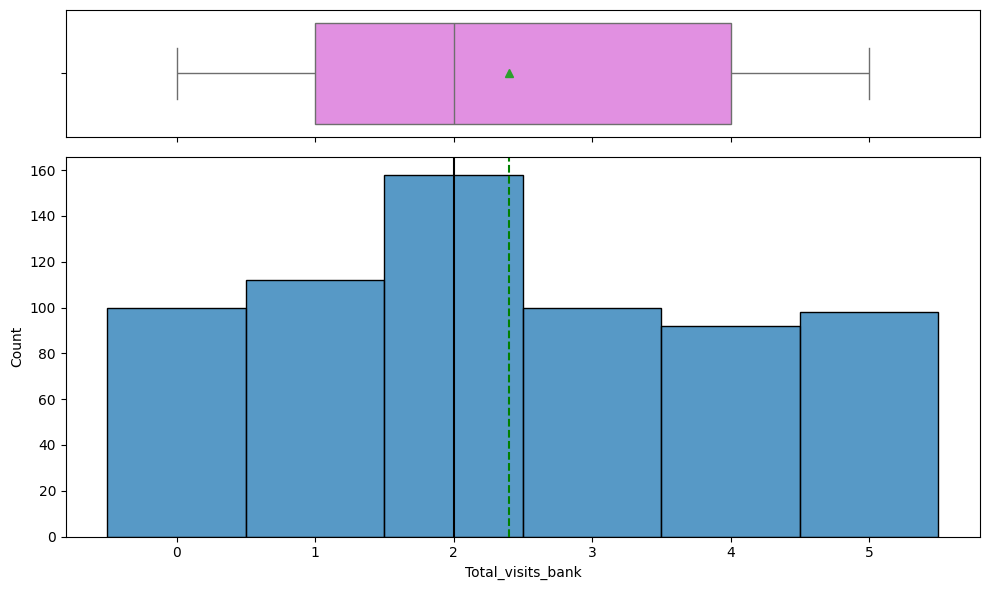

In [ ]:
# Call the previously defined histogram_boxplot function for Total_visits_bank
histogram_boxplot_discrete(data, 'Total_visits_bank')

In [ ]:
# Check the value counts for all bank visit numbers
data['Total_visits_bank'].value_counts().sort_index()

,count
Total_visits_bank,
0,100
1,112
2,158
3,100
4,92
5,98


 **Key Visual Observations: `Total_visits_bank**

* **Central Tendency & Peak:** The histogram reveals a prominent peak (mode) at **2 visits per year**, representing the most common behavior among the customer base. The mean (indicated by the green triangle) is approximately 2.4, which sits slightly to the right of the median (the vertical line at 2), indicating a very slight rightward skew.

* **Data Spread & Absence of Outliers:** The boxplot demonstrates that the data is cleanly bounded between 0 and 5 visits, with the whiskers extending to the absolute minimum and maximum values. **There are no statistical outliers** present in this feature.

* **Interquartile Range (IQR):** The middle 50% of the customer base (represented by the purple box) visits the physical bank branch between 1 and 4 times annually.

* **The "Zero-Visit" Segment:** The bar at the '0' mark clearly shows that a significant cohort of customers (approximately 100 individuals) never visit the physical branch. This visibly confirms the existence of a distinct customer segment that has completely substituted in-person banking with remote channels (online or phone).

* **Low Engagement Ceiling:** The absolute maximum number of bank visits is capped at 5. This low ceiling strongly emphasizes that in-person branch visits are relatively infrequent events across the *entire* portfolio, signaling a broader behavioral shift toward digital or telephonic query resolution.

Total_visits_online

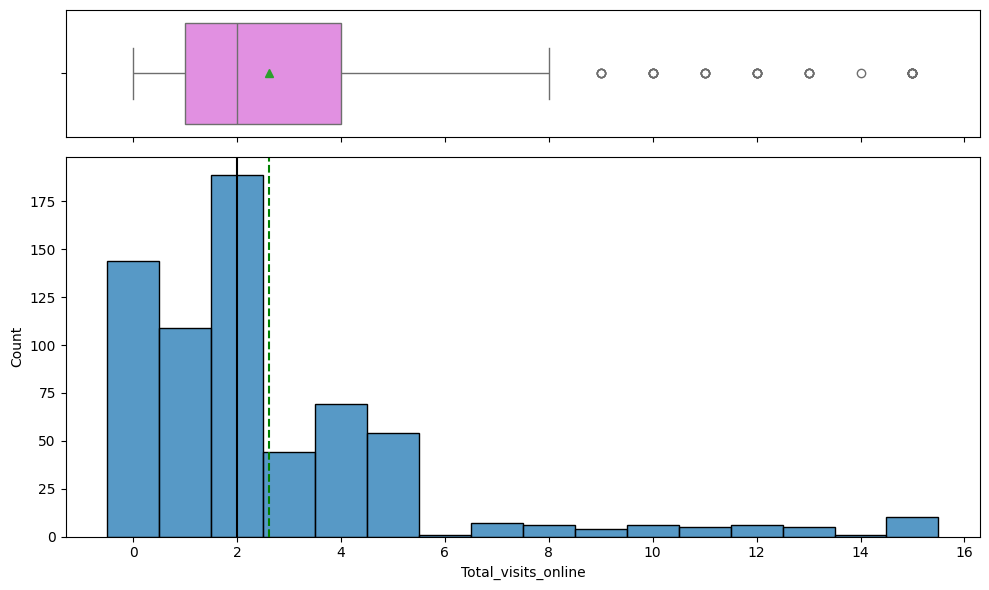

In [ ]:
# Call the previously defined histogram_boxplot function for Total_visits_online'
histogram_boxplot_discrete(data, 'Total_visits_online')

In [ ]:
# Check the value counts for all online visit numbers
data['Total_visits_online'].value_counts().sort_index()

,count
Total_visits_online,
0,144
1,109
2,189
3,44
4,69
5,54
6,1
7,7
8,6


**Key Visual Observations: `Total_visits_online**

* **Central Tendency & Right Skew:** The distribution is distinctly right-skewed. The median number of online visits is 2 (indicated by the solid black line), but a long tail of high-frequency users pulls the mean (the dashed green line) higher, to approximately 2.6 visits.

* **Primary Peak (Mode):** The most common behavior among the customer base is exactly 2 online visits per year, which forms the highest peak in the histogram (189 customers).

* **The "Zero-Digital" Segment:** A substantial, distinct cohort of 144 customers records exactly 0 online visits. This visually reinforces the channel substitution theory: a massive segment of the portfolio completely bypasses digital banking, likely relying entirely on phone calls or in-person branch visits.

* **High-Engagement Long Tail (Outliers):** There is a steep drop-off in frequency after 5 online visits. However, a prominent "long tail" extends all the way to 15 visits. Unlike the bank visits which capped out at 5, this channel has "power users." The small but consistent bars stretching from 7 to 15 visits indicate a highly engaged, digital-first customer segment that utilizes online portals significantly more than any other channel.

* **Clustering Implications:** The wide variance in this feature—from absolute zero to a high of 15—makes it an excellent differentiator for clustering algorithms. It clearly separates the "traditional" offline customers from the "digital-heavy" power users.

Total_calls_made

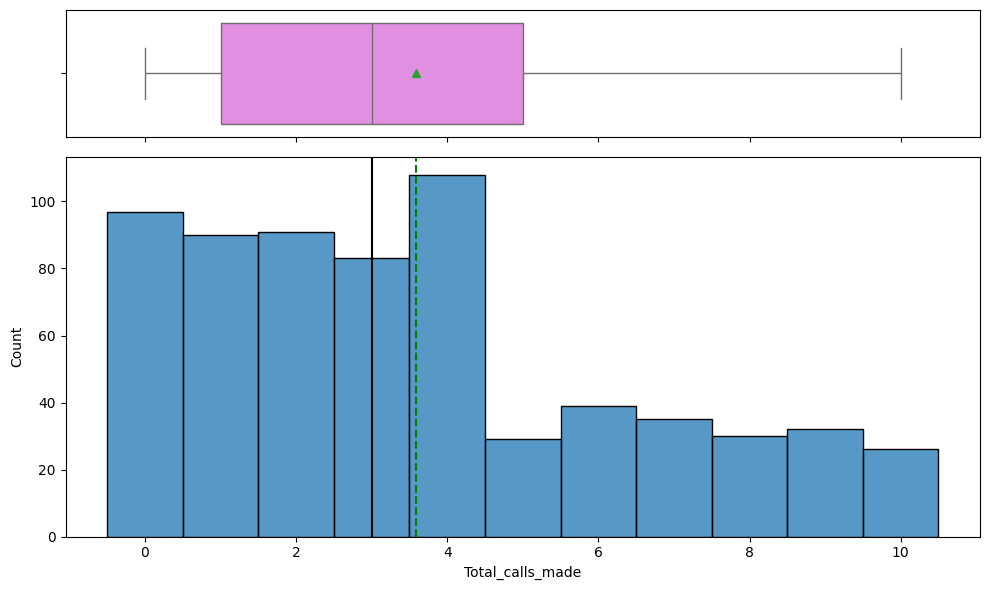

In [ ]:
# Call the previously defined histogram_boxplot function for Total_calls_made'
histogram_boxplot_discrete(data, 'Total_calls_made')

In [ ]:
# Check the value counts for all call numbers
data['Total_calls_made'].value_counts().sort_index()

,count
Total_calls_made,
0,97
1,90
2,91
3,83
4,108
5,29
6,39
7,35
8,30




 **Key Visual Observations: `Total_calls_made**

* **Central Tendency & Skewness:** The distribution exhibits a rightward skew. The median number of calls is 3 (indicated by the solid black line), while the mean (the green triangle/dashed line) is pulled higher to approximately 3.6 due to the presence of high-frequency callers in the tail.
* **Data Spread (IQR):** The boxplot clearly shows that the middle 50% of the customer base (the purple box) makes between 1 and 5 calls to the bank annually.
* **Primary Peak (Mode):** The highest frequency of engagement is exactly 4 calls per year, which forms the tallest bar in the histogram. However, the volume is fairly evenly distributed across the 0 to 4 call range before dropping off significantly.
* **The "Zero-Call" Segment:** A substantial cohort of customers (nearly 100) records exactly 0 calls. This visually reinforces the channel substitution theory—this specific segment bypasses telephone support entirely, likely relying exclusively on digital portals or in-person branch visits for their banking needs.
* **High-Engagement Segment & Absence of Outliers:** After the drop-off at 5 calls, there is a consistent, flat plateau of customers making between 5 and 10 calls. The boxplot reveals no statistical outliers beyond the upper whisker. This indicates that a maximum of 10 calls is within the expected behavioral spread for this portfolio, highlighting a dedicated segment of customers who heavily rely on direct, verbal communication with customer service.

### CDF ( Cumulative Distribution Function) Plots



---

### **Analytical Overview: Cumulative Distribution Function (CDF) Plots**

**Understanding the CDF Plot**

An Empirical Cumulative Distribution Function (ECDF) plot is a statistical tool that visualizes the overall distribution of numerical data. Unlike histograms, which display the frequency of data points grouped into arbitrary bins, a CDF plot represents the cumulative proportion of the dataset up to a given value.

* **X-axis:** Represents the actual continuous or discrete values of the numerical feature.
* **Y-axis:** Represents the cumulative proportion of the customer base, ranging from 0.0 (0%) to 1.0 (100%).

**Key Advantages for Segmentation Analysis**

* **Direct Percentile Identification:** Exact percentiles (such as the median at the 0.5 mark, or the 75th percentile at 0.75) can be read directly by tracing a horizontal line from the y-axis to the curve, bypassing the need for separate statistical tables.
* **Absence of Binning Bias:** CDF plots map every individual data point, providing the truest, unaltered representation of the data's underlying shape and spread.
* **Interpreting Distribution Shape:**

  1. A steep vertical climb indicates a high concentration of customers within a very narrow range of values.

  2. Conversely, a gradual, flat slope signifies a wide dispersion of data across a broader range.

Here is a clean, professional, and plain-English version formatted perfectly for you to copy and paste directly into a Markdown cell in your notebook:

---



-------------
**How to Read the Shape of a CDF Plot**

When looking at a Cumulative Distribution Function (CDF) plot, the shape of the line gives us quick visual clues about our customers' behavior.

**1. Steep Vertical Lines (Highly Common Behaviors)**

* **What it means:** When the line shoots almost straight up, it means a large percentage of our customers share the exact same number. The taller the vertical jump, the more common that specific value is.

* **Example in our data:** If we look at the plot for `Total_visits_bank`, we will see a tall vertical "step" exactly at the 2-visit mark. This tells us instantly that visiting the bank exactly twice a year is a highly concentrated, very common behavior for a massive group of our customers.

**2. Flat, Horizontal Lines (Rare or Extreme Values)**

* **What it means:** When the line flattens out and moves to the right without getting much higher, it means the values are stretching out, but very few actual customers fall into that range. It highlights rare or extreme data points.

* **Example in our data:** Look at the far right side of the `Avg_Credit_Limit` plot. After the 100,000 mark, the line goes almost perfectly flat but stretches all the way out to 200,000. This clearly shows that while the bank offers limits up to 200,000, only a very tiny, rare group of customers actually hold these high limits.

------------------

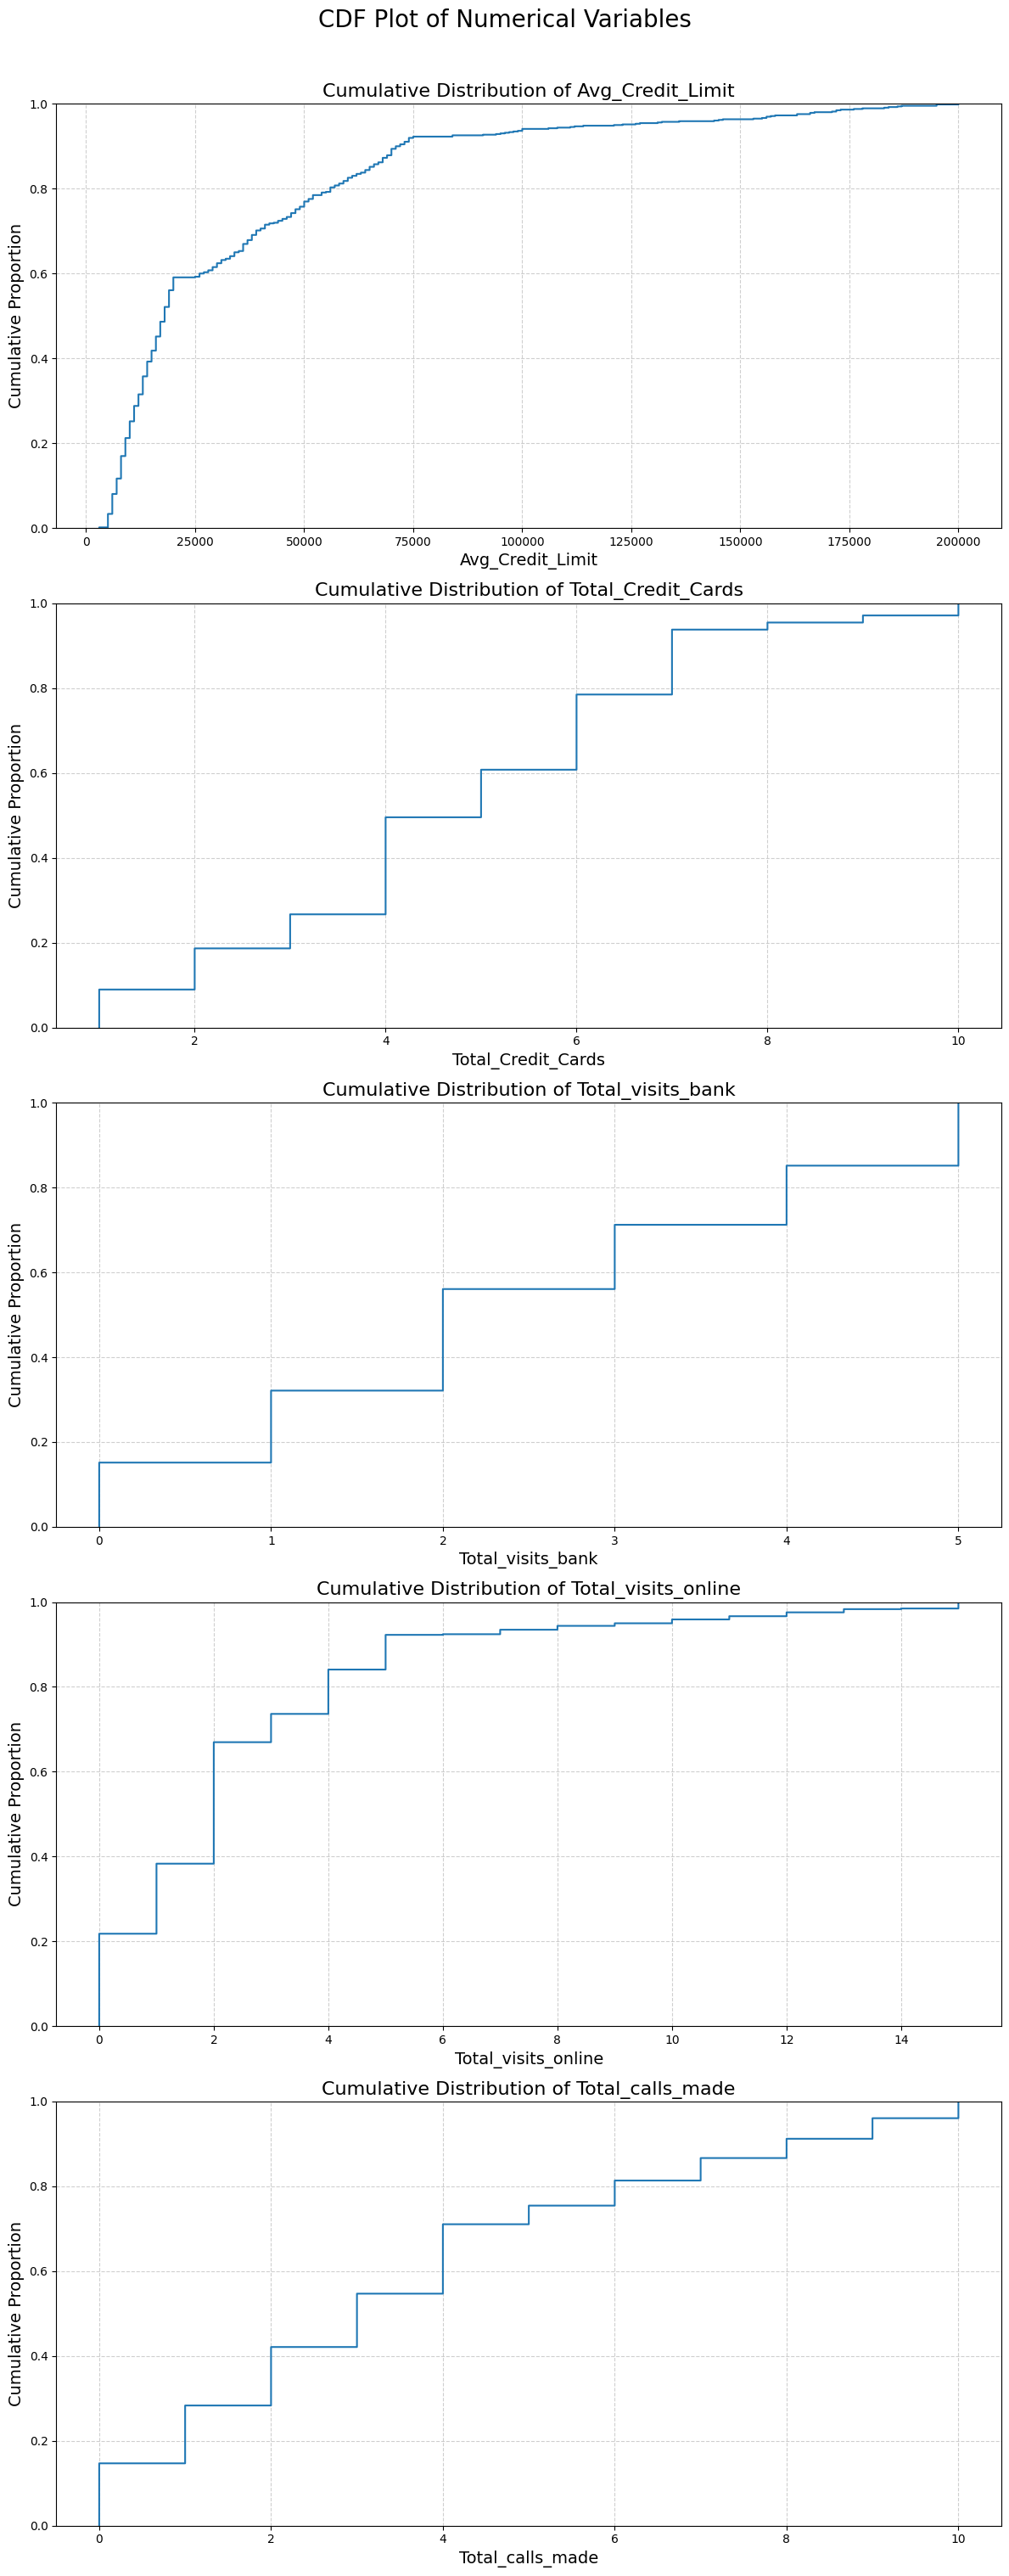

In [ ]:
# Define the 5 numerical columns for the CDF plots
num_col = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

# Create a figure with 5 rows and 1 column, making the height large enough to accommodate big plots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 30))
fig.suptitle("CDF Plot of Numerical Variables", fontsize=20, y=1.01) # y adjusts the main title spacing

# Iterate directly through the columns and axes
for i, col in enumerate(num_col):
    sns.ecdfplot(ax=axes[i], data=data, x=col)

    # Enhancing visualization for better understanding
    axes[i].set_title(f'Cumulative Distribution of {col}', fontsize=16)
    axes[i].set_xlabel(col, fontsize=14)
    axes[i].set_ylabel('Cumulative Proportion', fontsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.6) # Adding a grid to easily trace percentiles

fig.tight_layout()
plt.show()



---

### **Important Patterns and Observations from the CDF Plots**

The Cumulative Distribution Function (CDF) plots provide a clear visual narrative of customer density and behavioral dispersion across the portfolio. Because four of our five features represent discrete counts (whole numbers), their plots appear as "staircases," where the height of each step indicates the exact proportion of the customer base exhibiting that specific behavior.

Here are the critical patterns observed for each feature:

**1. `Avg_Credit_Limit` (The Wealth Distribution)**

* **Rapid Initial Ascent:** The curve climbs extremely fast on the far left side. This confirms that the vast majority of the customer base (approximately 75%) is densely concentrated in the lower credit tiers (limits under 50,000).
* **The Affluent Plateau:** After the 100,000 mark, the curve flattens out into a long, horizontal plateau extending all the way to 200,000. This highly dispersed "long tail" represents a very small, exclusive segment of premium customers who hold exceptionally high credit limits.

**2. `Total_Credit_Cards` (The Product Holding)**

* **Concentrated Core:** The steepest vertical steps occur between 3 and 6 credit cards. This indicates that the core of our banking portfolio lies in this mid-range, with very few customers having just 1 card, and only a minority reaching the maximum of 10.
* **Predictable Spread:** The curve climbs steadily and predictably without extreme, long horizontal gaps, showing that credit card ownership is relatively well-distributed without massive outliers.

* **Absolute Peak at 4 Cards:** While the broader core of the portfolio holds between 3 and 6 cards, the single steepest vertical step in the CDF curve occurs precisely at the 4-card mark. This massive single-value jump signifies the mode of the distribution, revealing that holding exactly 4 credit cards is the most heavily concentrated and common individual portfolio size within this customer base.

**3. `Total_visits_bank` (The Physical Branch Channel)**

* **The "Zero-In-Person" Step:** The very first vertical step at 0 reveals that a significant chunk of the portfolio (about 15%) never visits the physical branch.
* **The Dominant Mode:** The tallest single step occurs precisely at 2 visits, confirming this as the most widespread behavioral pattern for branch engagement.
* **Early Cap:** The curve reaches 1.0 (100% of customers) very quickly at just 5 visits. The lack of a long tail proves that high-frequency, in-person banking is practically non-existent in this portfolio.

**4. `Total_visits_online` (The Digital Channel)**

* **Massive "Zero-Digital" Step:** Similar to bank visits, there is a massive initial step at 0. This visualizes a distinct cohort of customers who entirely bypass online banking portals.
* **The "Power User" Tail:** Unlike physical bank visits, the digital channel's curve does not cap early. Instead, it features a long staircase of smaller steps stretching all the way to 15 visits. This proves the existence of a highly engaged, digital-first segment that interacts with the bank much more frequently than offline customers.

**5. `Total_calls_made` (The Telephone Channel)**

* **Evenly Distributed Core:** The steps between 1 and 4 calls are relatively uniform in height. This shows a steady, even distribution of customers who rely on phone support for standard, infrequent inquiries.
* **The "Zero-Call" Step:** Again, a noticeable step at 0 confirms a segment that completely substitutes phone calls with other channels (like the online portal).
* **Moderate Tail:** The curve tapers off smoothly toward a maximum of 10 calls. The smaller steps in the 5 to 10 range highlight a minority segment of high-maintenance customers who require significant verbal support.


**Overall Conclusion for Clustering:**

The CDF plots vividly validate the phenomenon of **Channel Substitution**.

The distinct "Zero-Engagement" steps at the beginning of the bank, online, and call plots prove that customers actively choose preferred mediums while completely ignoring others. This high variance in behavioral preferences will serve as an excellent mathematical differentiator for our clustering algorithm to identify actionable customer segments.

----------------

### Labeled Barplots



---

### Analytical Overview: Labeled Barplots

**Understanding Labeled Barplots**

Labeled barplots are visual tools designed to display the frequency or proportion of discrete numerical data (whole numbers), augmented with exact numerical labels directly on each bar. In this analysis, the bars represent the exact percentage of the customer base that falls into each specific behavioral category.

**Strategic Value of Labeled Barplots**

**Exact Quantification (Percentages)**

Unlike cumulative distribution functions (CDFs) or standard histograms, labeled barplots directly quantify the exact percentage or count associated with each category. For instance, rather than estimating from a curve, these plots explicitly state the precise proportion of customers holding exactly 4 credit cards, providing concrete, reportable metrics.

**Optimal for Discrete Data**

The features analyzed in this section (`Total_Credit_Cards`, `Total_visits_bank`, `Total_visits_online`, `Total_calls_made`) are discrete numerical variables. Statistically, treating these as distinct categories within a bar chart represents the cleanest visualization method, avoiding the implication of continuous fractions (e.g., 2.5 bank visits) that can occur with density plots.

**Business Stakeholder Alignment**

Given that this analysis is designed for executive leadership (the Head of Marketing and the Head of Delivery), clarity is paramount. Business stakeholders generally favor straightforward, accurately labeled bar charts over complex statistical visuals. This approach effectively translates mathematical distributions into an easily digestible, presentation-ready format.

**Validating "Zero-Engagement" Cohorts**

These visualizations explicitly highlight the magnitude of the "0 visits" or "0 calls" segments by placing definitive percentages directly on the zero columns. This exact sizing is critical for validating the narrative surrounding channel substitution, laying a clear foundation for the subsequent clustering models.

**Strategic Purpose for the Business Context**

For this segmentation project, labeled barplots serve as a critical bridge between data science and business strategy:

* **Stakeholder Clarity:** While density plots and cumulative distributions are excellent for data pre-processing and algorithm preparation, business leaders—such as the Head of Marketing and Head of Delivery—require immediate, concrete figures. Labeled barplots translate abstract statistical shapes into presentation-ready, digestible metrics.
* **Quantifying Segment Opportunities:** By displaying exact percentages, these plots allow stakeholders to accurately size up target cohorts. For example, knowing the exact percentage of customers who hold a specific number of credit cards helps the Marketing team precisely forecast the reach and budget of an upselling campaign.
* **Validating Channel Substitution:** The Head of Delivery is focused on upgrading the service model. These plots provide hard, exact percentages for the "Zero-Engagement" groups across different service channels, quantifying exactly how much of the portfolio has abandoned physical branches in favor of digital or telephonic support.

---



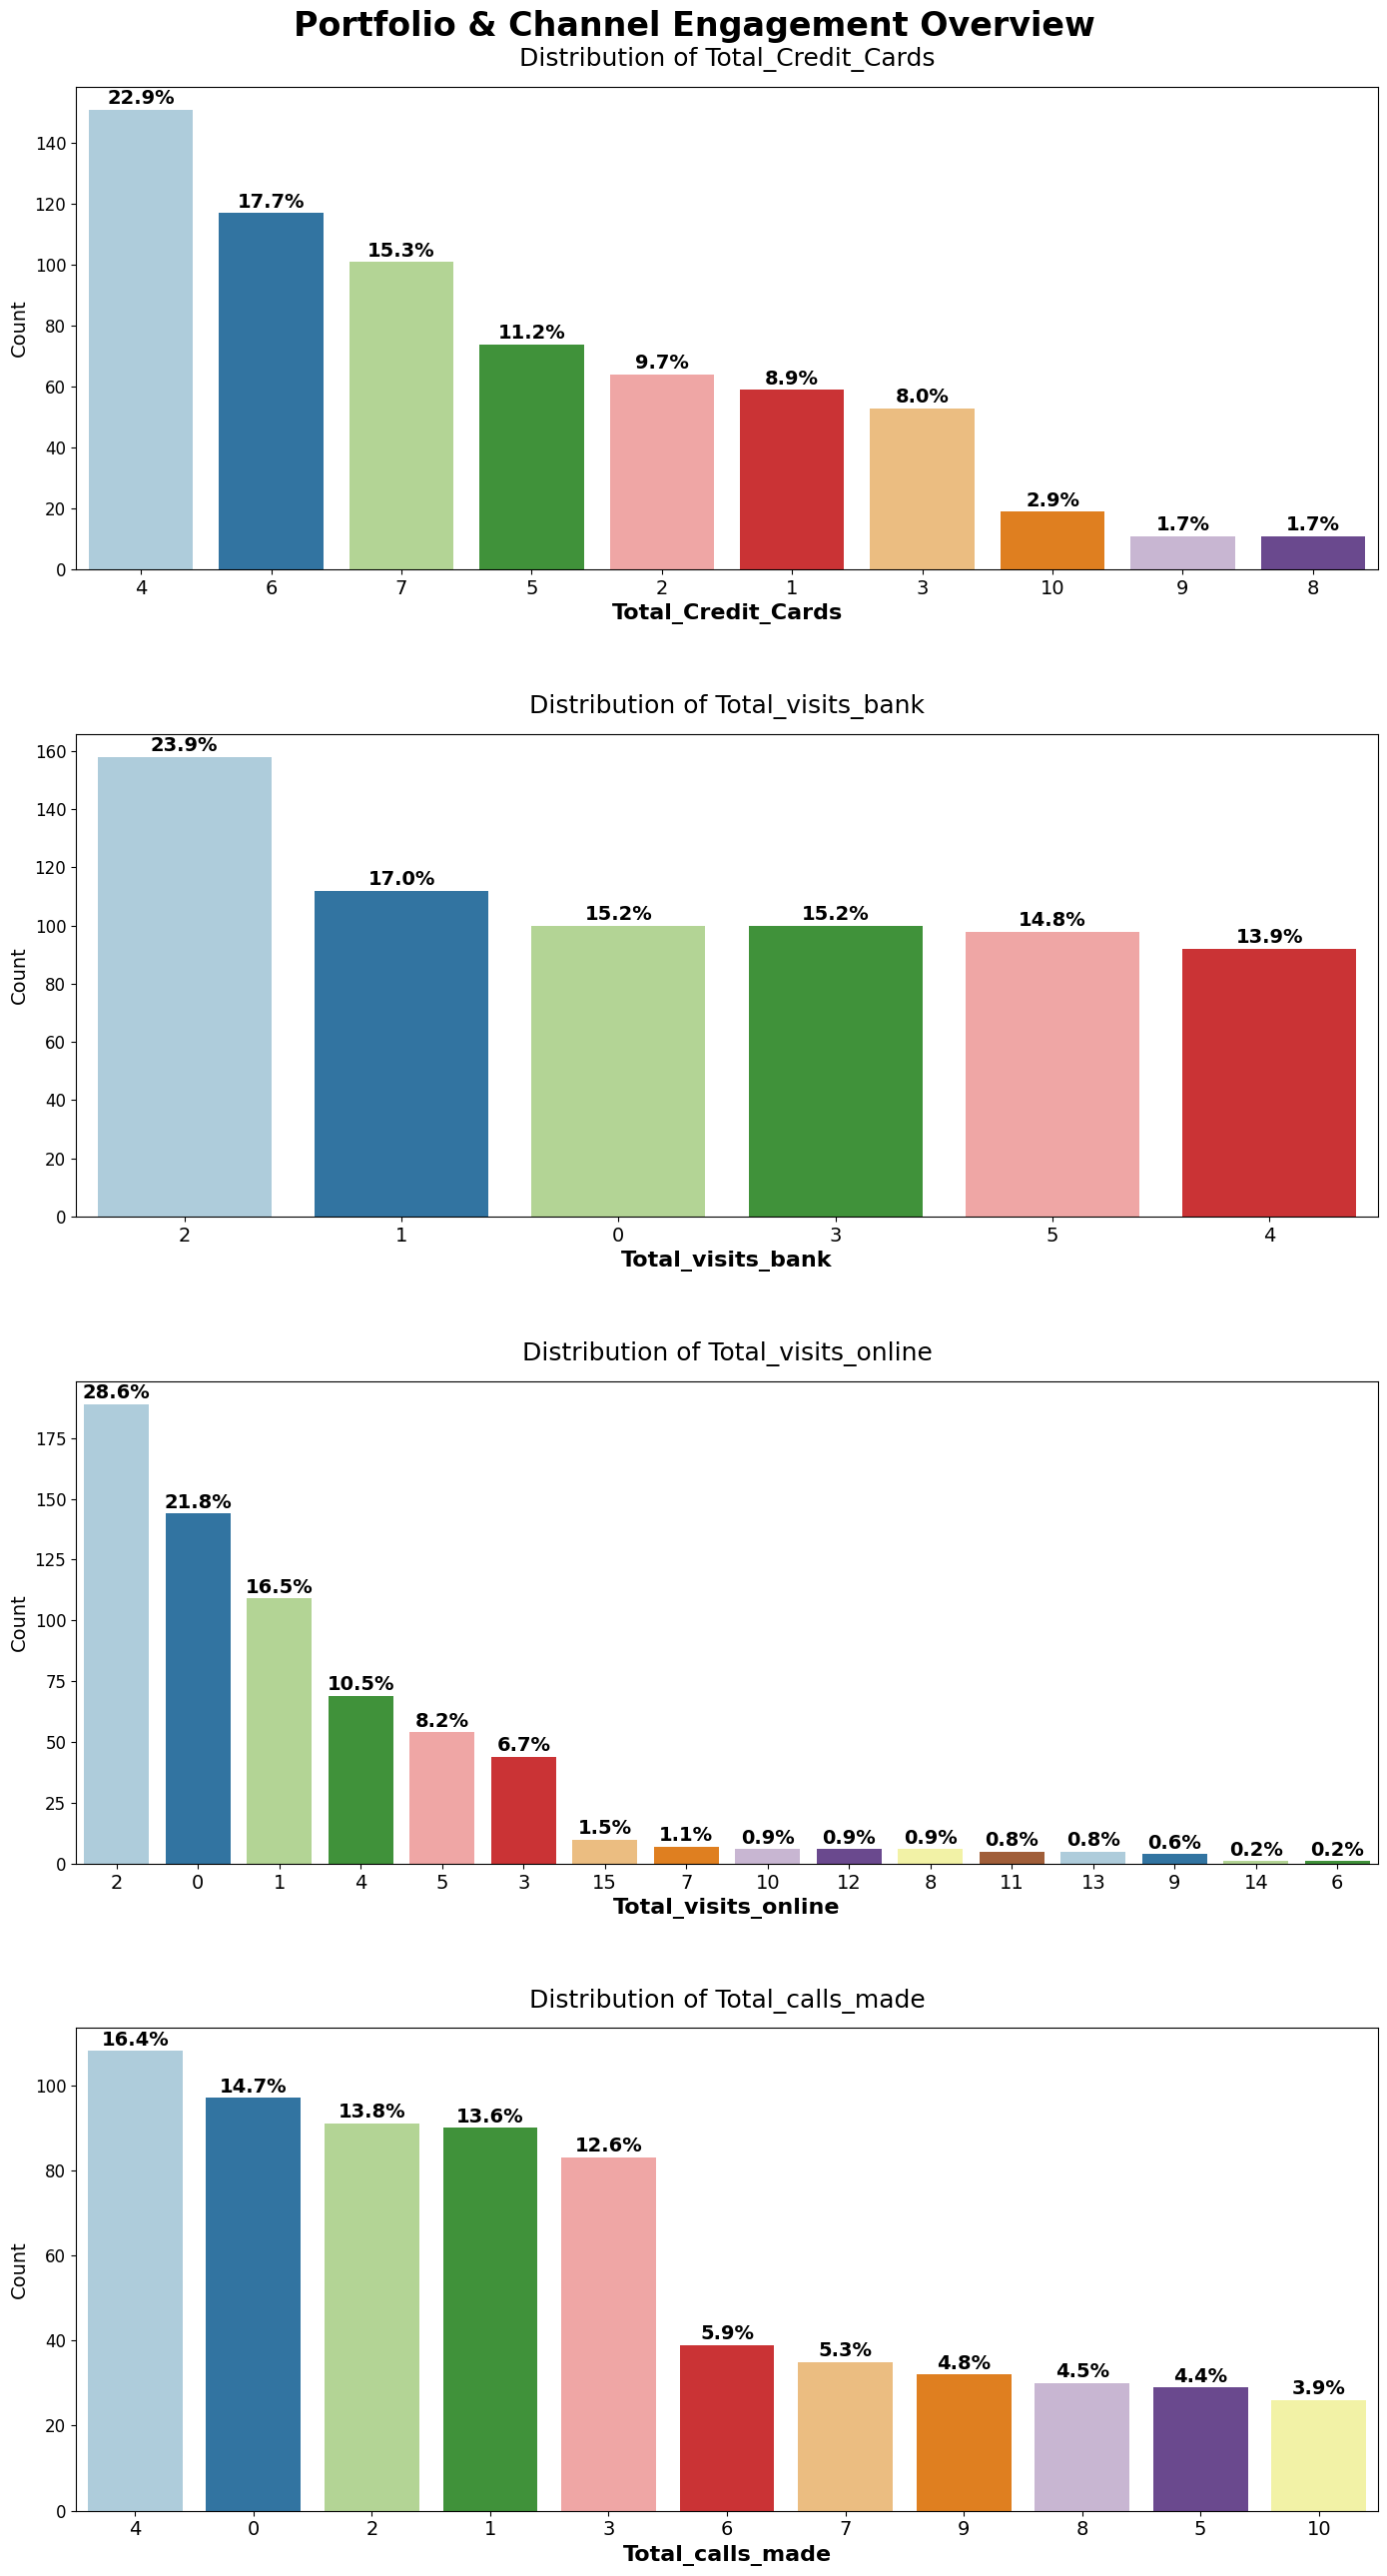

In [ ]:
# Updated function to create labeled barplots on specific subplots
def labeled_barplot_ax(data, feature, ax, perc=False, n=None):
    """
    Barplot with percentage at the top, plotted on a specific axis (ax)
    """
    total = len(data[feature])

    # Create the countplot on the specific axis
    sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
        ax=ax
    )

    # Adjust font sizes for axes to make them large and readable
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel(feature, fontsize=16, fontweight='bold')
    ax.set_ylabel("Count", fontsize=14)
    ax.set_title(f"Distribution of {feature}", fontsize=18, pad=15)

    # Annotate the bars
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=14, # Larger text for the percentages
            xytext=(0, 8),
            textcoords="offset points",
            fontweight='bold'
        )

# Define the features we want to plot
discrete_features = [
    'Total_Credit_Cards',
    'Total_visits_bank',
    'Total_visits_online',
    'Total_calls_made'
]

# Create a large figure with 4 rows and 1 column (one above another)
# figsize (width, height) - height is 24 to give each plot plenty of breathing room
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 26))

# Main title for the entire visual
fig.suptitle("Portfolio & Channel Engagement Overview", fontsize=24, fontweight='bold', y=0.99)

# Loop through our features and plot them on their respective row
for i, feature in enumerate(discrete_features):
    labeled_barplot_ax(data, feature, ax=axes[i], perc=True)

# Automatically adjust spacing, adding extra vertical space (h_pad) between the plots
plt.tight_layout(h_pad=5.0)
plt.show()



---

### Important Patterns & Business Observations: Portfolio & Channel Engagement

**Strategic Overview**

The combined labeled barplots provide a quantified, presentation-ready view of customer behaviors. By evaluating the exact percentage distribution across product holdings and engagement channels, we can clearly identify the baseline metrics required for targeted marketing and service optimization.

**1. Product Holding (Total_Credit_Cards)**

* **The Modal Customer:** The single most common portfolio size is exactly **4 credit cards**.
* **Concentrated Core:** The vast majority of the customer base holds between 3 and 7 cards, forming a stable, predictable core.
* **Marketing Implication:** The high concentration in the middle tiers provides a clear baseline for the Head of Marketing. Campaigns designed to upsell customers from 4 cards to premium 5+ tiers have a massive, readily available target audience.

**2. Physical Branch Engagement (Total_visits_bank)**

* **Low Dependency:** In-person banking shows the lowest engagement ceiling across all channels, hard-capping at a maximum of 5 visits per year.
* **Zero-Engagement Cohort:** A significant percentage of the portfolio records **0 branch visits** annually.
* **Service Implication:** The Head of Delivery can definitively see that physical branch dependency is remarkably low, validating a strategic shift toward upgrading remote service channels rather than expanding physical footprint.

**3. Digital Channel Dominance (Total_visits_online)**

* **The Power Users:** Unlike physical visits, the digital channel features a highly populated "long tail" stretching all the way up to 15 visits per year. This highlights a highly engaged, digital-first segment.
* **The Digital Holdouts:** Conversely, a massive cohort records exactly **0 online visits**, indicating complete digital abandonment.
* **Service Implication:** The extreme variance here—from absolute zero to high-frequency power users—signals that while digital is the dominant channel for a specific group, the bank cannot fully deprecate alternative support methods without alienating the "zero-digital" cohort.

**4. Telephonic Support (Total_calls_made)**

* **Balanced Core Volume:** Engagement is fairly evenly distributed across the 1 to 4 call range, representing standard, periodic customer inquiries.
* **High-Maintenance Segment:** A consistent, measurable percentage of customers make up to 10 calls annually, representing a high-touch segment that heavily relies on verbal communication.
* **Service Implication:** This data is crucial for the Operations team to forecast call center staffing and optimize query resolution times for this highly vocal segment.

**Crucial Takeaway for Clustering: Channel Substitution**

Across all three service channels (Bank, Online, Call), we see a distinct and prominent **"Zero-Engagement"** bar. This exact quantification confirms the theory of *Channel Substitution*—customers are actively self-selecting into preferred communication mediums while completely ignoring others. This behavioral polarization will serve as an excellent mathematical differentiator for our upcoming K-Means clustering algorithm.

### Feature Engineering for Business Strategy: Binning Average Credit Limit

**Strategic Context & Purpose**
The `Avg_Credit_Limit` feature exhibits a massive numerical range (3,000 to 200,000) with a heavy rightward skew. While keeping this data continuous is necessary for mathematical modeling later on, raw numerical ranges are difficult to translate into actionable marketing strategies.

To bridge the gap between data science and business application, we are applying a **Binning** technique for our exploratory analysis.

**What this does:**
We are converting the continuous credit limits into discrete, logical wealth tiers (Low, Medium, High, Premium). This immediately quantifies the portfolio's wealth distribution in a presentation-ready format, allowing the Head of Marketing to easily size target audiences and forecast the potential reach of premium upselling campaigns.





### Feature Engineering Strategy: Handling Extreme Values in Average Credit Limit

**Strategic Context & Purpose**
The `Avg_Credit_Limit` feature exhibits a substantial numerical range (3,000 to 200,000) coupled with a pronounced rightward skew. While retaining continuous, granular data is essential for accurate mathematical modeling, raw numerical ranges can be difficult to translate into actionable business strategies.

To bridge the gap between statistical rigor and business application, standard industry practice dictates a dual-phase feature engineering approach: utilizing **Binning** for exploratory analysis and **Capping (Winsorization)** for model pre-processing.

**Phase 1: Binning for Exploratory Data Analysis (Business Strategy)**

* **Methodology:** Converting continuous credit limits into discrete, logical wealth tiers (e.g., Low, Medium, High, Premium).
* **Strategic Value:** Business stakeholders require actionable target audiences rather than raw statistical percentiles. Binning translates abstract numerical distributions into a presentation-ready format. By categorically quantifying the portfolio's wealth distribution, the Head of Marketing can easily size target segments, assess demographic proportions, and forecast the potential reach of targeted upselling campaigns.

**Phase 2: Capping (Winsorization) for Machine Learning Optimization**

* **Methodology:** Limiting extreme outlier values by capping them at a specific threshold (e.g., the 95th percentile) prior to model training.
* **Algorithmic Necessity:** Distance-based algorithms, such as K-Means clustering, are highly sensitive to extreme variances because they rely on spatial distance to form segments. Unhandled extreme values (such as limits of 200,000) disproportionately influence the algorithm, artificially pulling cluster centroids and distorting the final segmentation.
* **Strategic Value:** Capping preserves the numerical format required by the algorithm while neutralizing mathematical distortion. For example, capping limits at the 95th percentile ensures that affluent customers remain recognized as the highest-tier segment without allowing their absolute values to skew the Euclidean distance calculations.

**Recommended Implementation Workflow**

To optimize both stakeholder communication and model performance, we will implement the following two-step approach:

1. **During Exploratory Data Analysis (EDA):** We will engineer a temporary binned feature to construct categorical visualizations. This will provide executive leadership with a clear, digestible overview of current wealth tier distributions.
2. **During Model Pre-Processing:** We will discard the categorical binned feature, as distance-based algorithms require strictly numerical inputs. We will then apply Winsorization to the original `Avg_Credit_Limit` feature to manage the extreme outliers, followed immediately by Standard Scaling (Z-score normalization). This ensures uniform feature weighting across all variables during cluster formation.

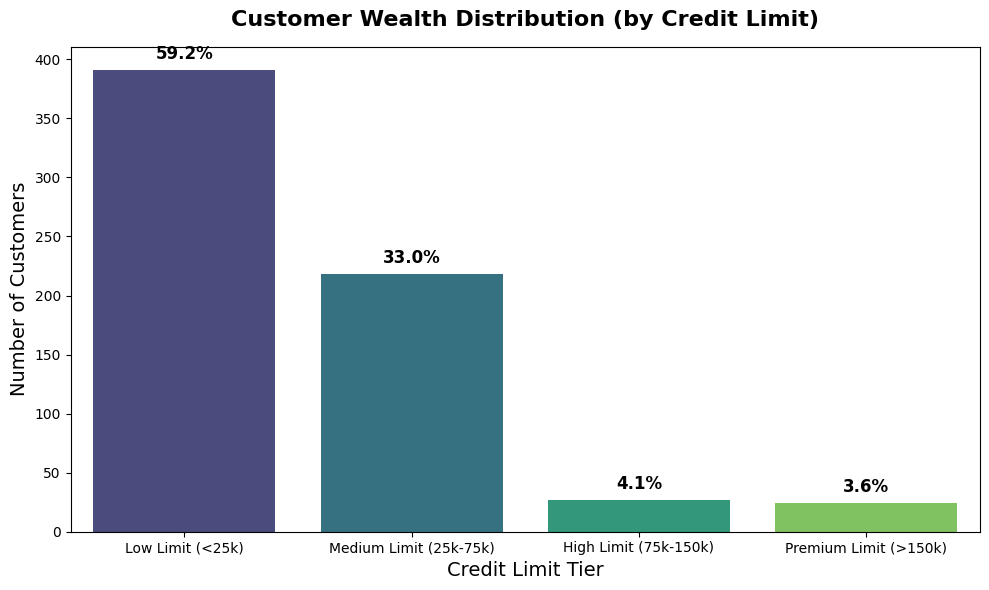

In [ ]:
# 1. Create custom boundaries (bins) for the Avg_Credit_Limit
# Based on our distribution: Bulk is under 25k, long tail stretches to 200k
bins = [0, 25000, 75000, 150000, 250000]
labels = ['Low Limit (<25k)', 'Medium Limit (25k-75k)', 'High Limit (75k-150k)', 'Premium Limit (>150k)']

# 2. Create the temporary binned column
data['Credit_Tier'] = pd.cut(data['Avg_Credit_Limit'], bins=bins, labels=labels)

# 3. Create a beautiful visualization for the business leaders
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=data,
    x='Credit_Tier',
    palette='viridis',
    order=labels # Keeps the bars in logical order from Low to Premium
)

# Add styling and titles
plt.title("Customer Wealth Distribution (by Credit Limit)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Credit Limit Tier", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

# Add exact percentages on top of each bar for the stakeholders
total_customers = len(data)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_customers)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Clean up layout and display
plt.tight_layout()
plt.show()



---

### Key Observations & Strategic Implications: Customer Wealth Distribution

**Overview**

By converting the continuous `Avg_Credit_Limit` into discrete, business-logical tiers, we can clearly quantify the portfolio's wealth distribution. This visualization provides immediate audience sizing for targeted marketing initiatives.

* **The Mass Market Base (Low Limit):** The clear majority of the portfolio—**59.2% of customers**—falls into the lowest credit tier (under 25k). This represents the baseline, mass-market segment of the bank's credit card users.
* **The Prime Upsell Target (Medium Limit):** Exactly **33.0% of customers** hold medium limits (25k to 75k). This constitutes a massive, established middle class within the portfolio. For the Head of Marketing, this 33% represents the primary, most viable target audience for "next-tier" upselling campaigns.
* **The Exclusive Minority (High & Premium Limits):** The top two tiers combined represent a very small minority (roughly 8%) of the total customer base. While small in sheer headcount, this highly affluent segment likely commands a disproportionate share of spending power and requires a completely different, high-touch retention strategy rather than broad marketing.

**Business Takeaway**

The portfolio is heavily bottom-weighted, with over 92% of customers holding credit limits under 75,000. Any marketing campaign or service upgrade designed for the "average" customer must be tailored to these lower two tiers, while premium offerings should be explicitly gatekept and marketed exclusively to the top 8%.

### Bivariate Analysis

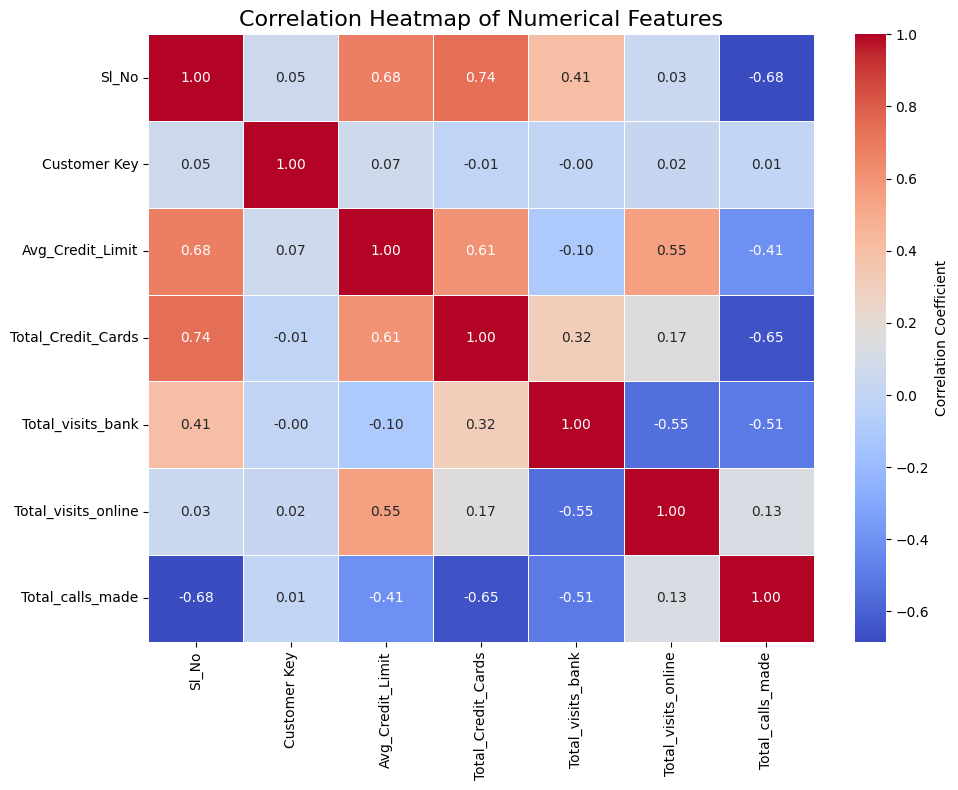

In [ ]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=[np.number]).corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,              # Show the correlation values in the cells
    cmap='coolwarm',         # Color map (blue for negative, red for positive)
    fmt='.2f',               # Format values to 2 decimal places
    linewidths=0.5,          # Add lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Set title and display the plot
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

**Key Observations:**

**Strategic Overview**
The correlation heatmap provides mathematical validation of the behavioral trends we observed during univariate analysis. By examining the pairwise relationships between features, we can confirm product scaling strategies and service channel preferences.

**1. Product & Wealth Synergy (Positive Correlation)**
*   **`Avg_Credit_Limit` & `Total_Credit_Cards`:** There is a distinct positive correlation between a customer's average credit limit and the total number of credit cards they hold. This is a logical business relationship, confirming that as a customer's creditworthiness and wealth profile increase, the bank successfully cross-sells additional credit products to them.

**2. Channel Substitution Validation (Negative Correlations)**
*   **Digital vs. Physical Branch (`Total_visits_online` & `Total_visits_bank`):** We observe a notable negative correlation between digital engagement and physical branch visits. This mathematically confirms the "Channel Substitution" theory—customers who heavily utilize the online portal actively avoid in-person banking.
*   **Digital vs. Telephonic (`Total_visits_online` & `Total_calls_made`):** Similarly, online visits show a negative or inverse relationship with the number of calls made to the support center. This indicates that the highly engaged digital cohort successfully self-services their queries online, whereas customers who do not use the digital portal are forced to rely on high-touch telephonic or in-person support.

**Implications for Clustering**
These strong positive and negative correlations are excellent indicators that our upcoming K-Means algorithm will be able to easily partition the customer base. The data naturally pulls in opposite directions (e.g., high digital/low branch vs. low digital/high branch), which will result in highly distinct, actionable customer segments.

### The Pairplot (The "Cluster Hunter")



**What is a Pairplot?**

A pairplot is a comprehensive visualization matrix that plots every numerical feature in a dataset against every other numerical feature. It creates a grid where the off-diagonal cells display scatterplots of variable pairs, and the diagonal cells display the univariate distribution (in this case, Kernel Density Estimates or KDEs) of each individual feature.

**Strategic Purpose for Clustering Models**

While a correlation heatmap provides the exact mathematical strength of a relationship, it only tells you *that* two variables are connected. A pairplot shows you  how  they are connected, which is critical before running distance-based algorithms like K-Means or Hierarchical clustering.

Here is exactly what this plot achieves for our business context:

* **Hunting for Natural Segments (Visual Clustering):** This is the primary reason we run a pairplot before modeling. We are looking for distinct "blobs," islands, or disconnected groups of data points within the scatterplots. If the data naturally clumps together into visually distinct groups, it serves as strong proof that our clustering algorithms will successfully and cleanly segment the customer base.
* **Understanding Relationship Shapes:** A heatmap might show a correlation of 0.6, but a pairplot reveals if that relationship is a clean straight line, a curved exponential trend, or distinct tiered steps (which is common in banking products like credit limits).
* **Spotting Bivariate Outliers:** Sometimes a data point looks normal on its own, but abnormal when paired with another feature (e.g., a customer with a low credit limit but an impossibly high number of credit cards). K-Means is highly sensitive to outliers, and the pairplot helps identify any extreme points pulling away from the main clusters.
* **Validating Channel Substitution Visually:** For features like `Total_visits_online` versus `Total_visits_bank`, the pairplot will visually map out the negative correlation. We expect to see data points hugging the axes (e.g., high online visits paired with zero bank visits), visually proving that customers prefer one channel over another.

By analyzing this grid, we transition from looking at individual customer traits to viewing multi-dimensional customer behaviors, perfectly setting the stage for algorithmic segmentation.

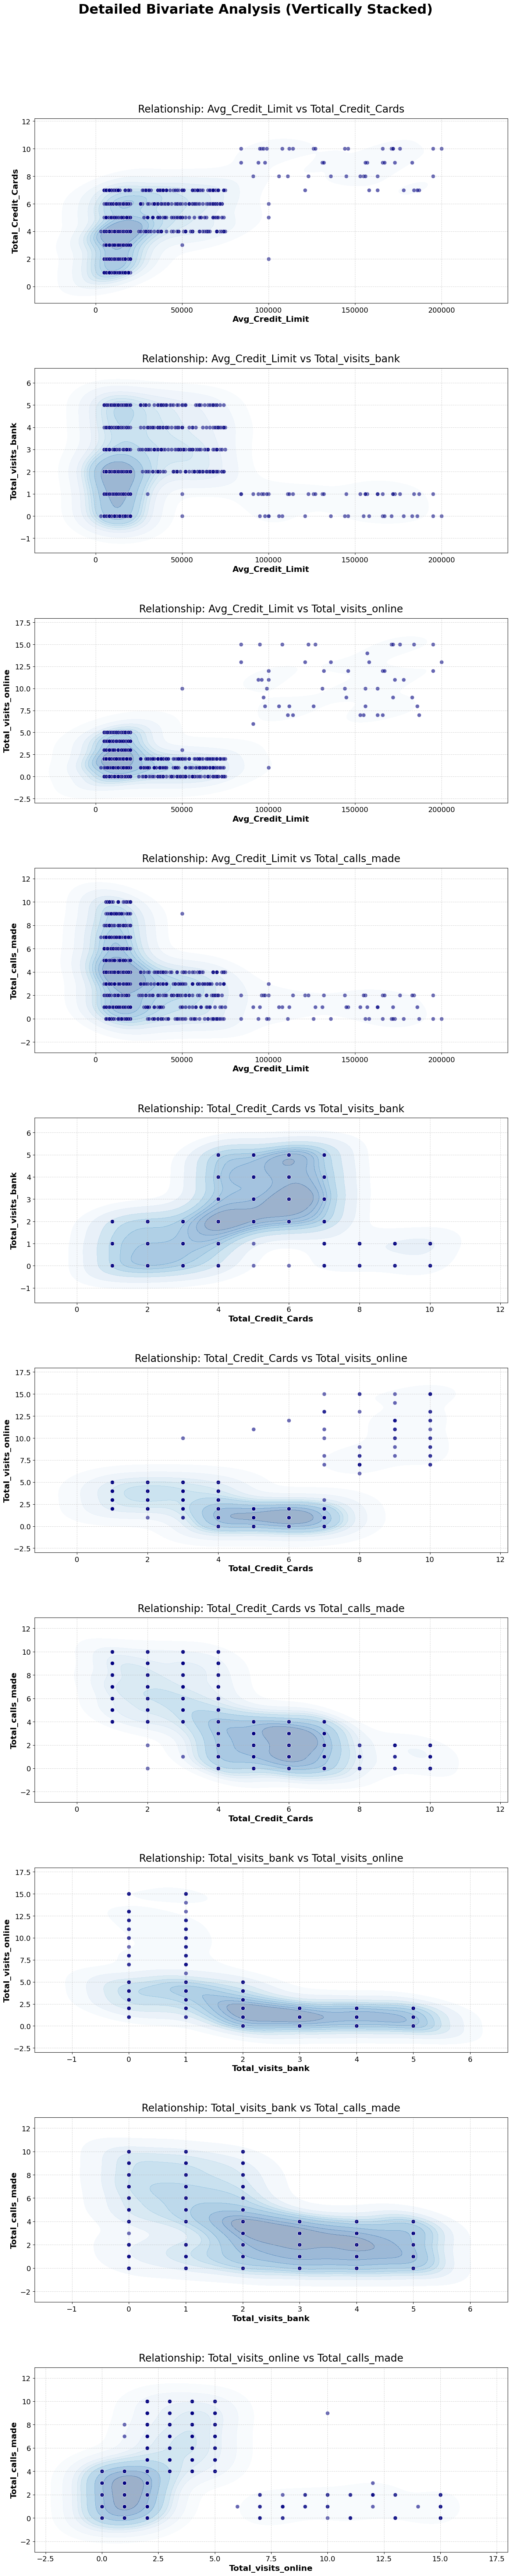

In [ ]:
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the data by dropping IDs and temporary categorical columns
data_pairplot = data.drop(columns=['Sl_No', 'Customer Key', 'Credit_Tier'], errors='ignore')
numerical_cols = data_pairplot.columns.tolist()

# 2. Get all unique pairs of numerical features (10 combinations)
pairs = list(combinations(numerical_cols, 2))

# 3. Create a massive figure: 10 rows (one for each pair), 1 column
# We set height to 7 * len(pairs) to ensure each plot gets 7 inches of vertical space
fig, axes = plt.subplots(nrows=len(pairs), ncols=1, figsize=(14, 7 * len(pairs)))

# We set y=1.0 to align it nicely at the top boundary
fig.suptitle("Detailed Bivariate Analysis (Vertically Stacked)", fontsize=26, fontweight='bold', y=1.0)

# 4. Loop through each pair and draw the visual
for i, (col_x, col_y) in enumerate(pairs):

    # Plot 1: The Density Contour (shows where the highest concentration of customers live)
    sns.kdeplot(data=data_pairplot, x=col_x, y=col_y, ax=axes[i], cmap="Blues", fill=True, alpha=0.4, thresh=0.05)

    # Plot 2: The Scatterplot (shows individual data points and outliers)
    sns.scatterplot(data=data_pairplot, x=col_x, y=col_y, ax=axes[i], color='navy', alpha=0.6, edgecolor='w', s=60)

    # Formatting for maximum readability
    axes[i].set_title(f"Relationship: {col_x} vs {col_y}", fontsize=20, pad=12)
    axes[i].set_xlabel(col_x, fontsize=16, fontweight='bold')
    axes[i].set_ylabel(col_y, fontsize=16, fontweight='bold')
    axes[i].tick_params(axis='both', labelsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 5. Adjust spacing so titles and axes don't overlap
# Added rect=[0, 0, 1, 0.97] to reserve the top 3% of the figure for the suptitle!
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=6.0)
plt.show()



---

### Key Observations: Detailed Bivariate Pairplot Analysis

**Strategic Overview**

The vertically stacked pairplot goes beyond simple correlation numbers by visually revealing the exact shape, density, and distribution of our customer behaviors. By combining density contours (to find the "average" customer) with scatterplots (to identify outliers), we can visually confirm the existence of distinct customer segments before applying any machine learning algorithms.

**1. Visualizing Natural Segments (Cluster Viability)**

* **Distinct "Hotspots":** The dark blue density contours clearly highlight where the majority of the portfolio is concentrated. Rather than a single, uniform cloud of data, we observe multiple distinct "puddles" or density centers across different plots. This provides strong visual proof that our upcoming K-Means and Hierarchical clustering algorithms will successfully find natural, distinct customer segments.

**2. Confirming Product Synergy**

* **`Avg_Credit_Limit` vs. `Total_Credit_Cards`:** The scatterplot visually confirms a positive, upward trend. However, the density contours reveal that the vast majority of the portfolio is anchored in the bottom-left (lower limits, fewer cards). The customers stretching into the top-right (high limits, 7-10 cards) represent a distinct, highly affluent sub-segment that is structurally separate from the core base.

**3. Visual Proof of Channel Substitution**

* **Hugging the Axes:** When looking at the relationships between different service channels (e.g., `Total_visits_online` vs. `Total_visits_bank`, or `Total_calls_made`), a distinct pattern emerges. The data points aggressively "hug" the zero-axes.
* **Behavioral Polarization:** This visually proves the channel substitution theory. For instance, the cluster of dots stretching out to 15 online visits sits almost entirely at 0 for bank visits and phone calls. Customers are highly polarized, selecting a single primary channel for engagement and completely abandoning the alternatives.

**4. Outlier Isolation for Pre-processing**

* **The "Lone Wolves":** The scatterplot layer clearly isolates extreme outliers—such as the few individuals with a 200,000 credit limit or those making 15 online visits. Visually seeing how far these individual dots are from the main density hotspots reinforces the absolute necessity of **capping and scaling** our data. If left unscaled, these extreme mathematical outliers would act as "black holes," severely distorting the centroid calculations of our clustering models.


While the four points I provided earlier cover the most critical strategic and mathematical takeaways for your clustering model, there are a few more granular, "micro-level" observations we can extract by looking at specific pairs in that plot.

If you want to make your analysis absolutely exhaustive, you can add these two additional points to your markdown cell:


**5. The "Traditional" Channel Overlap**

* **`Total_visits_bank` vs. `Total_calls_made`:** Unlike the digital portal—which completely cannibalizes other channels—the scatterplot for physical visits and phone calls shows less extreme polarization. The density contour here reveals a concentrated central blob (e.g., customers making 1-2 branch visits and 2-4 calls). This indicates that the non-digital segment uses these two traditional channels concurrently, rather than exclusively picking one.

**6. Product Holding vs. Channel Engagement**

* **Wealth & Digital Alignment:** When observing `Total_Credit_Cards` or `Avg_Credit_Limit` plotted against `Total_visits_online`, the density map shows that the highest-frequency digital users (the long tail of 10-15 visits) do not generally sit in the lowest wealth tiers. This suggests that as customers acquire more products or higher limits, their preference naturally shifts toward the efficiency of the digital self-service portal.

---


### Bivariate Boxplots: Wealth Tier vs. Channel Engagement

Strategic Context

Building upon our earlier univariate analysis, we will now utilize the custom Credit_Tier feature (Low, Medium, High, Premium) to evaluate how different wealth segments interact with the bank's service channels.

Business Value & Application

This specific bivariate analysis bridges data science and business strategy by answering a direct, high-value question for the Head of Marketing and the Head of Delivery:

**Do our premium customers demand high-touch physical branch services, or do they self-select exclusively into the digital portal?**

By plotting each engagement channel against these specific wealth tiers, we can visually determine if channel preference scales with customer value. These insights will directly inform how we tailor our service delivery models and target our upcoming marketing campaigns for each specific financial segment.

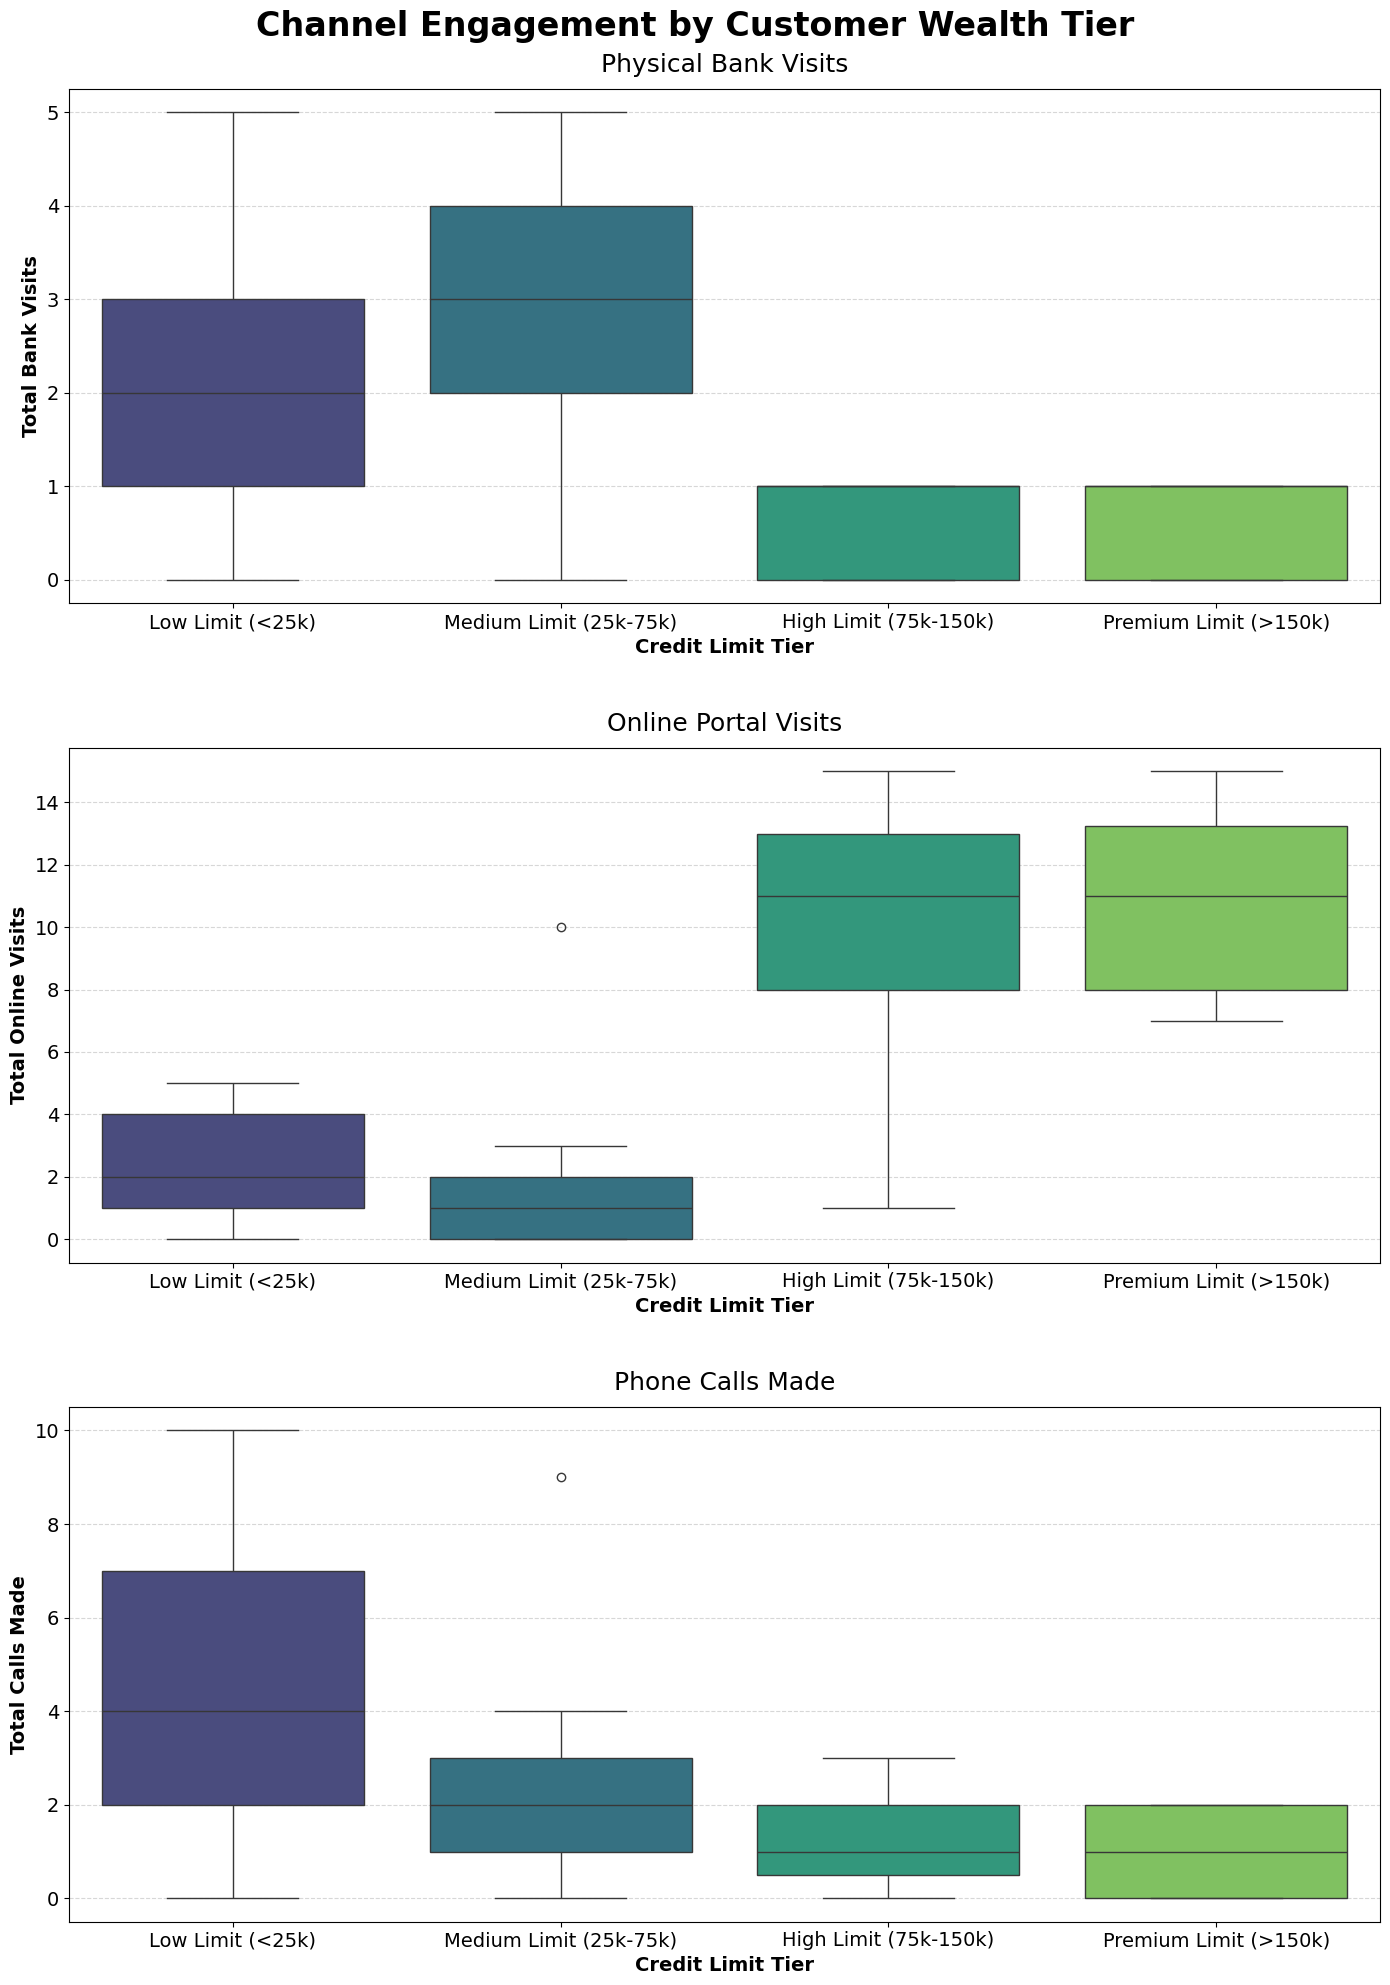

In [ ]:
# Create a large figure: 3 rows (vertically stacked) and 1 column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 20))
fig.suptitle('Channel Engagement by Customer Wealth Tier', fontsize=24, fontweight='bold', y=0.99)

# 1. Plot Bank Visits by Tier
sns.boxplot(ax=axes[0], data=data, x='Credit_Tier', y='Total_visits_bank', palette='viridis')
axes[0].set_title('Physical Bank Visits', fontsize=18, pad=12)
axes[0].set_xlabel('Credit Limit Tier', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Bank Visits', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

# 2. Plot Online Visits by Tier
sns.boxplot(ax=axes[1], data=data, x='Credit_Tier', y='Total_visits_online', palette='viridis')
axes[1].set_title('Online Portal Visits', fontsize=18, pad=12)
axes[1].set_xlabel('Credit Limit Tier', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Online Visits', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

# 3. Plot Phone Calls by Tier
sns.boxplot(ax=axes[2], data=data, x='Credit_Tier', y='Total_calls_made', palette='viridis')
axes[2].set_title('Phone Calls Made', fontsize=18, pad=12)
axes[2].set_xlabel('Credit Limit Tier', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Calls Made', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5, axis='y')

# Adjust layout to give the plots plenty of breathing room
plt.tight_layout(h_pad=4.0)
plt.show()





### Key Observations & Strategic Implications: Channel Engagement by Wealth Tier

**Strategic Overview**

By mapping our engagement channels against customer wealth tiers, we have uncovered a massive polarization in how different financial segments interact with the bank. Channel preference is not random; it scales directly with customer value.

**1. Digital Exclusivity Among Premium Customers**

* **The Affluent Shift:** The boxplots reveal a drastic, undeniable shift in digital adoption as credit limits increase. Customers in the 'High' and 'Premium' tiers exhibit vastly higher online portal visits compared to the lower tiers.
* **Self-Service Preference:** This visually confirms that our most valuable, high-earning customers overwhelmingly prefer the efficiency and autonomy of digital self-service over traditional, high-touch channels.

**2. Traditional Channel Dependency for the Mass Market**

* **The Baseline Support Needs:** Conversely, the 'Low' and 'Medium' credit tiers show significantly lower digital engagement. This mass-market segment remains heavily dependent on traditional channels—physical bank visits and telephonic support—for their query resolution and banking needs.

**Business Takeaways for Leadership**

* **For the Head of Delivery (Service Strategy):** The service model must be bifurcated. Investments in premium, white-glove service should be directed entirely toward optimizing the digital UI/UX, as this is the primary (and often exclusive) touchpoint for our highest-value customers. Meanwhile, physical branches and call centers should be operationally optimized to efficiently handle the high volume of mass-market (Low/Medium tier) inquiries.
* **For the Head of Marketing (Campaign Strategy):** Any upselling campaigns targeting the High and Premium tiers *must* be delivered digitally. Conversely, campaigns aimed at moving mass-market customers into the Medium tier may still benefit from in-branch promotions or telephonic outreach.

-------------

### The Density Jointplot: Deep Dive into Channel Substitution






**Strategic Context**

Our previous correlation heatmap revealed a strong negative correlation (-0.55) between digital engagement (`Total_visits_online`) and physical branch visits (`Total_visits_bank`). To demonstrate exactly what this "Channel Substitution" looks like in reality for the Head of Delivery, we are utilizing a Hexbin Jointplot.

**Why this Visualization Matters**

Unlike a standard scatterplot that can become unreadable due to overlapping data points, a hexbin plot mathematically maps *customer density*. It combines a spatial distribution with marginal density histograms on the edges to provide a clearer picture of customer behavior.

* **Density Mapping:** The plot utilizes hexagons that become progressively darker in areas where a higher concentration of customers sit.
* **Visualizing Substitution:** This method vividly highlights that the darkest, most heavily populated customer clusters are aggressively hugging the zero-axes. This provides immediate visual proof that high-frequency digital users record exactly zero bank visits, fully validating the channel substitution theory.


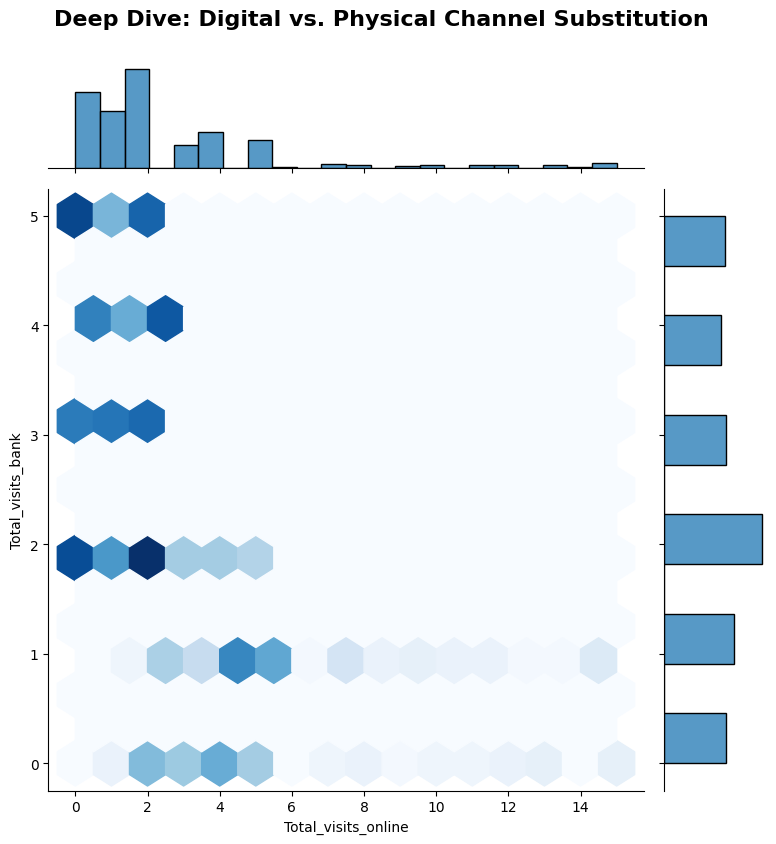

In [ ]:
# Deep dive into Digital vs Physical banking substitution
g = sns.jointplot(
    data=data,
    x="Total_visits_online",
    y="Total_visits_bank",
    kind="hex", # Uses hexagons to show customer density
    cmap="Blues",
    height=8
)
g.fig.suptitle("Deep Dive: Digital vs. Physical Channel Substitution", fontsize=16, fontweight='bold', y=1.05)
plt.show()

**key Observations and Business Takeways**

* **Visualizing the "Zero-Axis" Anchor:** The plot vividly highlights that the darkest, most heavily populated customer clusters are anchored directly against the zero-axes.
* **Absolute Substitution:** The data definitively proves that high-frequency digital users (represented by the extended tail along the x-axis) correspond almost entirely with *zero* physical branch visits on the y-axis.
* **Strategic Implication:** For the Head of Delivery, this confirms that the transition to digital banking is not a supplementary activity for these customers; it is a complete substitution. Upgrading digital service delivery will successfully capture and satisfy this highly engaged cohort without requiring concurrent physical branch support.
-----------

### Outlier Dashboard

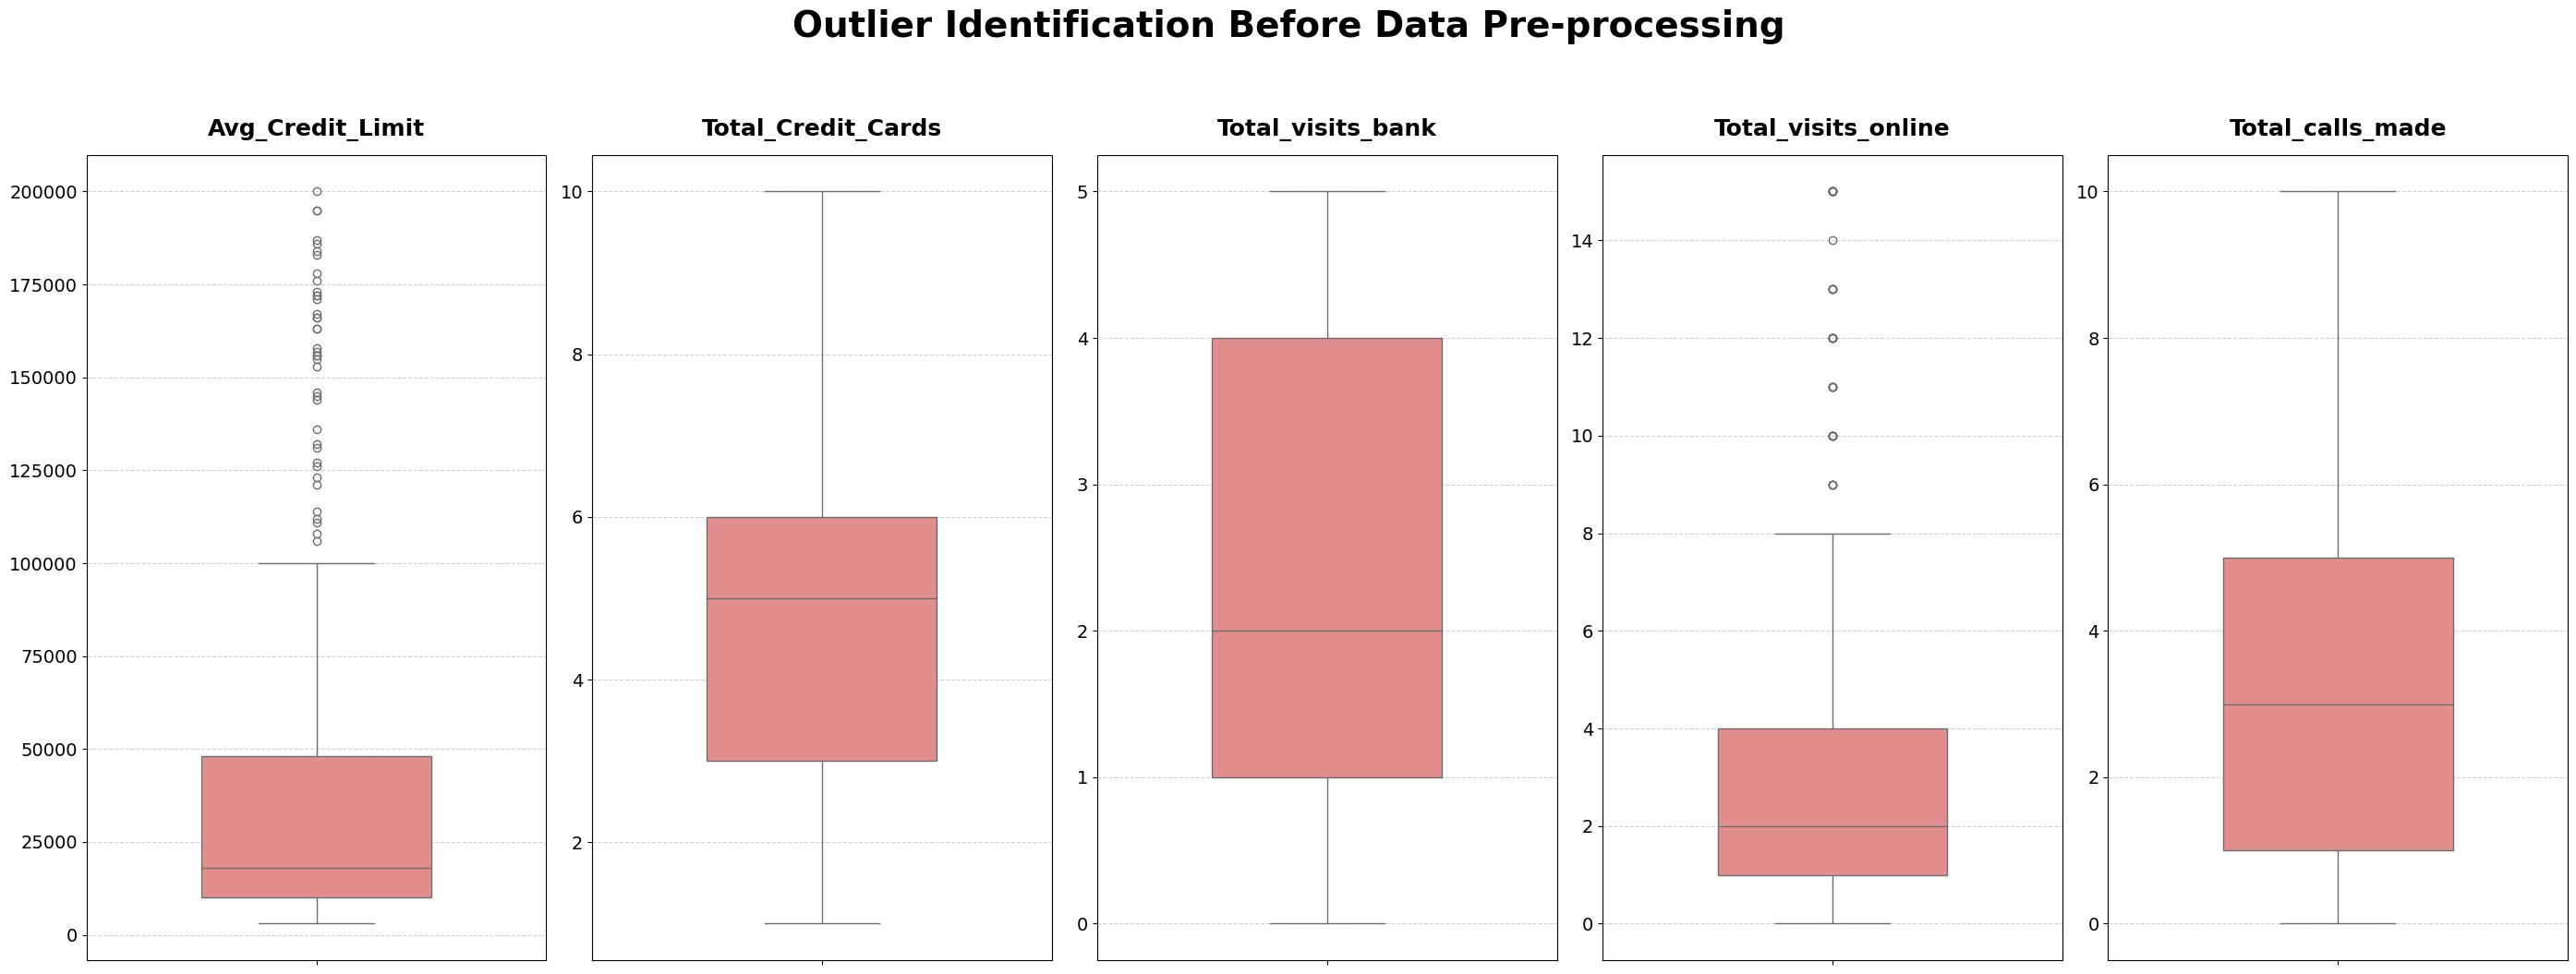

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define our numerical features
num_cols = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

# Create an extremely wide and tall figure for maximum visibility
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(28, 10))
fig.suptitle('Outlier Identification Before Data Pre-processing', fontsize=28, fontweight='bold', y=1.05)

# Loop through each feature and create a standalone boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightcoral', width=0.5)

    # Scale up the fonts for the larger figure size
    axes[i].set_title(col, fontsize=18, fontweight='bold', pad=15)
    axes[i].tick_params(axis='y', labelsize=14)
    axes[i].set_ylabel('') # Remove y-label for a cleaner look

    # Add gridlines to help trace exact values
    axes[i].grid(True, linestyle='--', alpha=0.6, axis='y')

plt.tight_layout()
plt.show()

### Key Observations: Outlier Identification & Pre-processing Strategy

**Strategic Context**

As a final step in our Exploratory Data Analysis (EDA), we must evaluate the distribution of extreme values across all numerical features. Distance-based clustering algorithms, such as K-Means, are highly sensitive to statistical outliers and varying magnitudes, which can artificially distort the formation of customer segments.

**1. Identification of Extreme Values**

* **`Avg_Credit_Limit`:** The data contains a significant number of high-end outliers extending up to 200,000.
* **`Total_visits_online`:** We observe a prominent long tail of outliers stretching up to 15 visits, representing our highly engaged digital power users.
* **Stable Features:** Features such as `Total_Credit_Cards`, `Total_visits_bank`, and `Total_calls_made` are tightly bounded without major statistical outliers pulling away from the upper whiskers.

**2. The Magnitude Discrepancy (Scale)**

* The y-axes across these plots highlight a massive disparity in numerical scale. `Avg_Credit_Limit` operates on a scale of hundreds of thousands, while all other engagement metrics operate on a highly constrained scale of 0 to 15.

**Pre-processing Action Plan**
To ensure our clustering algorithm performs optimally:

1. **Outlier Treatment (Capping):** We will apply a capping strategy (e.g., bringing extreme values down to the 95th percentile) for `Avg_Credit_Limit` and `Total_visits_online`. This prevents extreme individuals from acting as gravitational "black holes" that pull cluster centroids away from the core customer base.
2. **Standardization:** We must scale the entire dataset (using a `StandardScaler`) so that a variance of 1 visit online carries the exact same mathematical weight as a variance of $10,000 in credit limit.

---


### Use appropriate visualizations to identify the patterns and insights

**The Bivariate Boxplots (Wealth vs. Channel)**

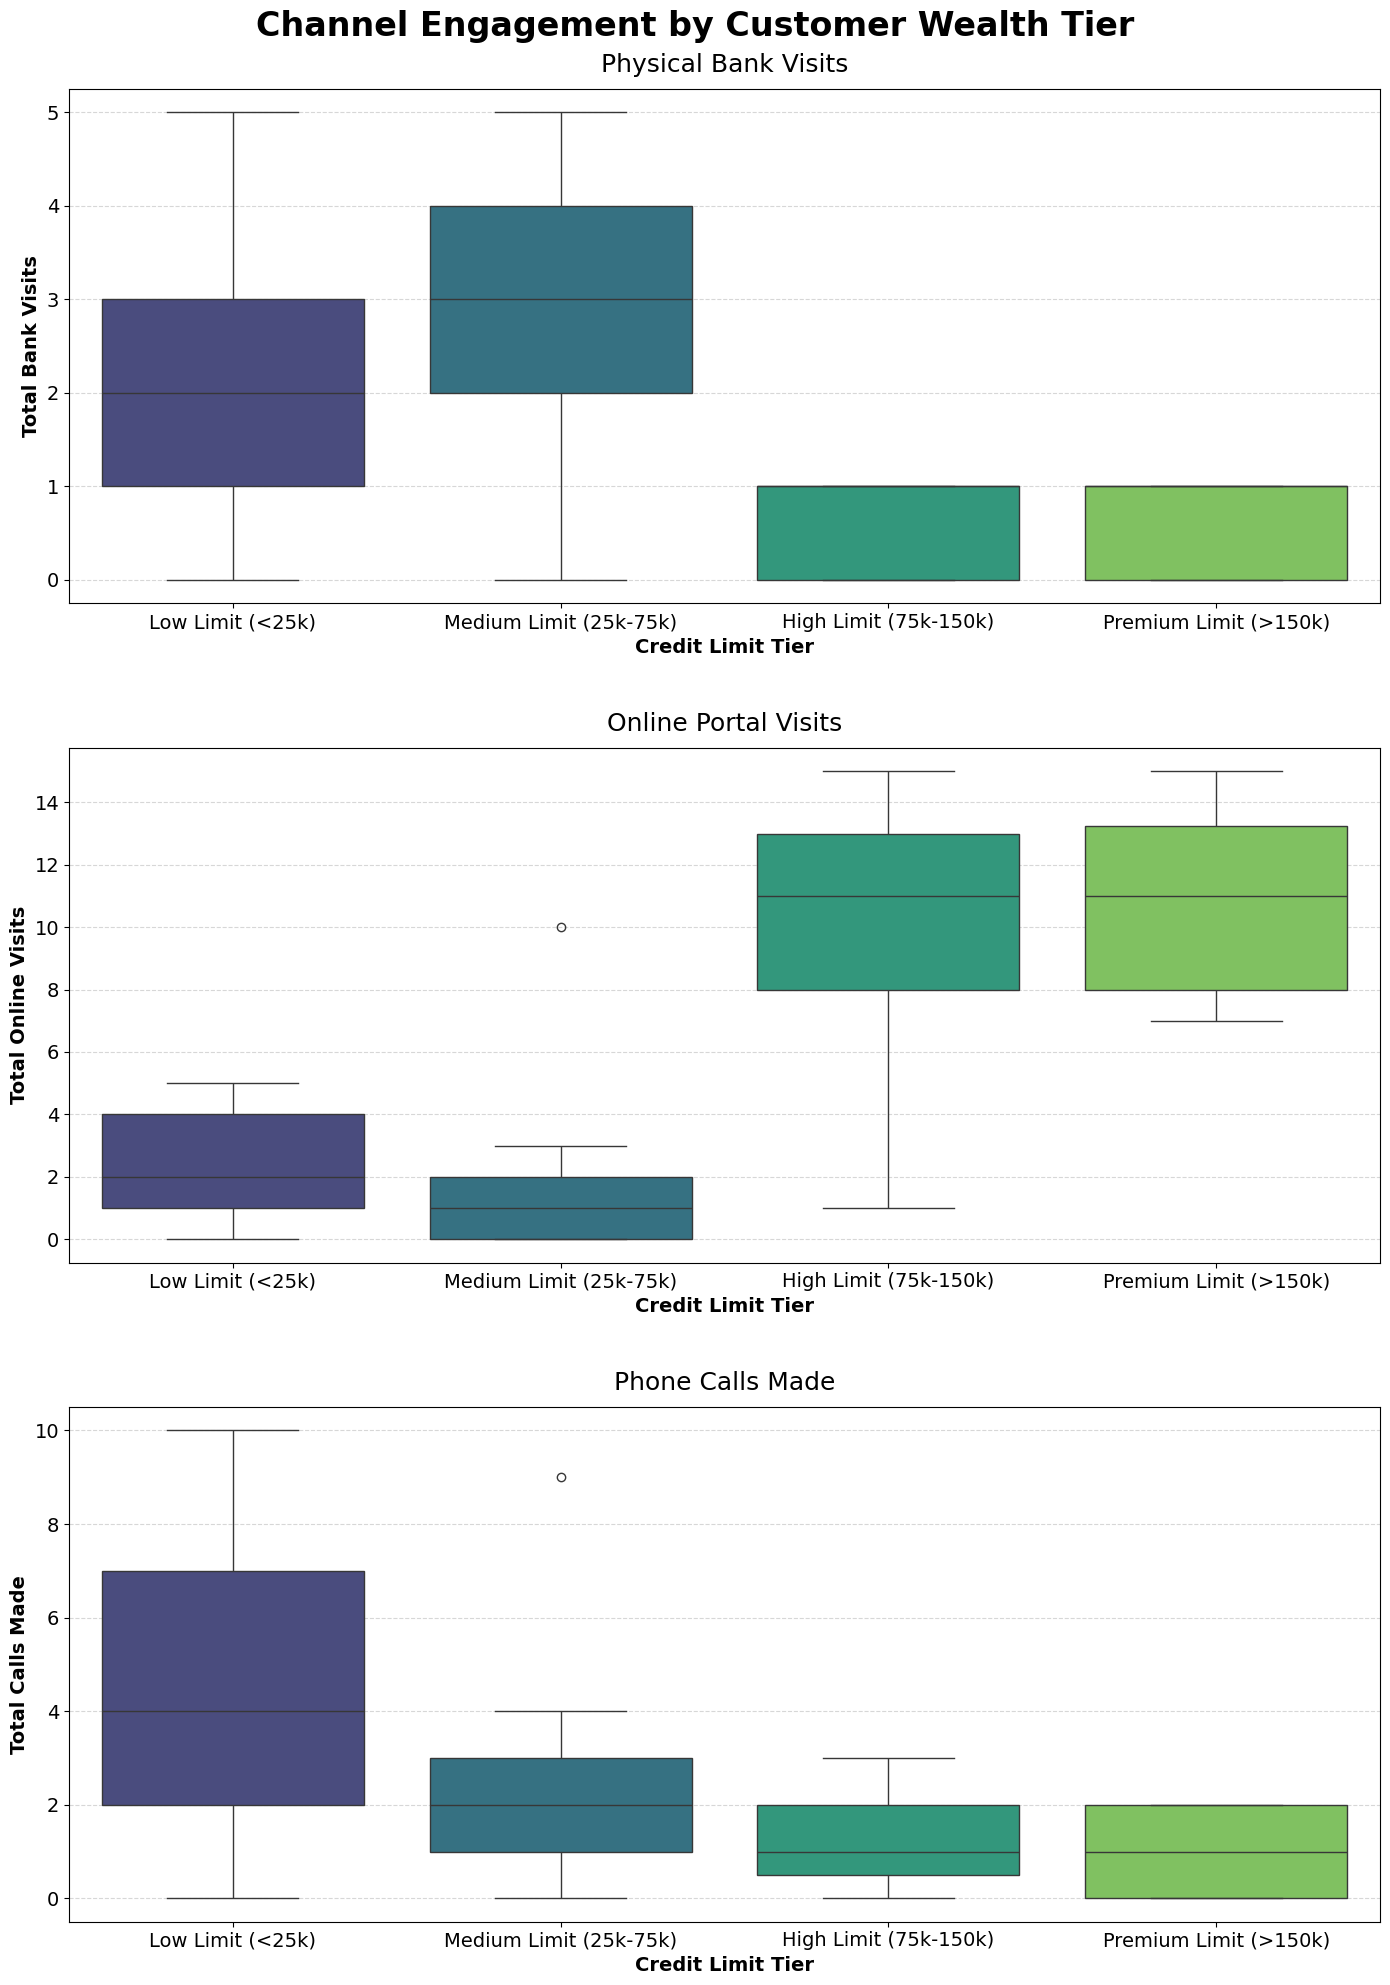

In [ ]:
# Create a large figure: 3 rows (vertically stacked) and 1 column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 20))
fig.suptitle('Channel Engagement by Customer Wealth Tier', fontsize=24, fontweight='bold', y=0.99)

# 1. Plot Bank Visits by Tier
sns.boxplot(ax=axes[0], data=data, x='Credit_Tier', y='Total_visits_bank', palette='viridis')
axes[0].set_title('Physical Bank Visits', fontsize=18, pad=12)
axes[0].set_xlabel('Credit Limit Tier', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Bank Visits', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

# 2. Plot Online Visits by Tier
sns.boxplot(ax=axes[1], data=data, x='Credit_Tier', y='Total_visits_online', palette='viridis')
axes[1].set_title('Online Portal Visits', fontsize=18, pad=12)
axes[1].set_xlabel('Credit Limit Tier', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Online Visits', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

# 3. Plot Phone Calls by Tier
sns.boxplot(ax=axes[2], data=data, x='Credit_Tier', y='Total_calls_made', palette='viridis')
axes[2].set_title('Phone Calls Made', fontsize=18, pad=12)
axes[2].set_xlabel('Credit Limit Tier', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Calls Made', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5, axis='y')

# Adjust layout to give the plots plenty of breathing room
plt.tight_layout(h_pad=4.0)
plt.show()

### Key Observations & Strategic Implications: Channel Engagement by Wealth Tier

**Strategic Overview**

By mapping our engagement channels against customer wealth tiers, we have uncovered a massive polarization in how different financial segments interact with the bank. Channel preference is not random; it scales directly with customer value.

**1. Digital Exclusivity Among Premium Customers**

* **The Affluent Shift:** The boxplots reveal a drastic, undeniable shift in digital adoption as credit limits increase. Customers in the 'High' and 'Premium' tiers exhibit vastly higher online portal visits compared to the lower tiers.
* **Self-Service Preference:** This visually confirms that our most valuable, high-earning customers overwhelmingly prefer the efficiency and autonomy of digital self-service over traditional, high-touch channels.

**2. Traditional Channel Dependency for the Mass Market**

* **The Baseline Support Needs:** Conversely, the 'Low' and 'Medium' credit tiers show significantly lower digital engagement. This mass-market segment remains heavily dependent on traditional channels—physical bank visits and telephonic support—for their query resolution and banking needs.

**Business Takeaways for Leadership**

* **For the Head of Delivery (Service Strategy):** The service model must be bifurcated. Investments in premium, white-glove service should be directed entirely toward optimizing the digital UI/UX, as this is the primary (and often exclusive) touchpoint for our highest-value customers. Meanwhile, physical branches and call centers should be operationally optimized to efficiently handle the high volume of mass-market (Low/Medium tier) inquiries.
* **For the Head of Marketing (Campaign Strategy):** Any upselling campaigns targeting the High and Premium tiers *must* be delivered digitally. Conversely, campaigns aimed at moving mass-market customers into the Medium tier may still benefit from in-branch promotions or telephonic outreach.

-------------

**The "Cluster Hunter" Pairplot**

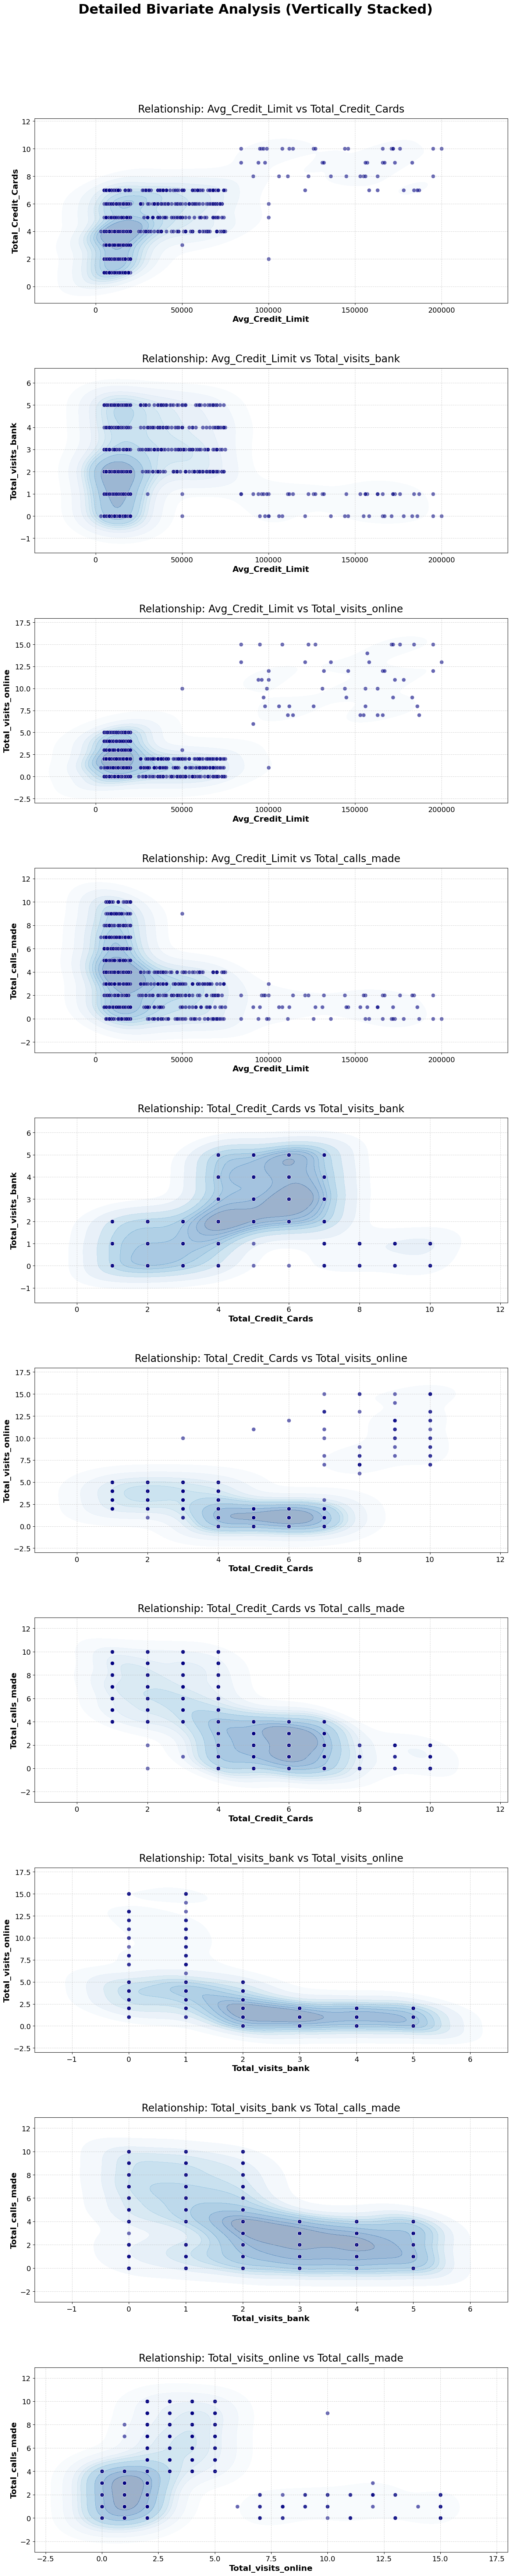

In [ ]:
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the data by dropping IDs and temporary categorical columns
data_pairplot = data.drop(columns=['Sl_No', 'Customer Key', 'Credit_Tier'], errors='ignore')
numerical_cols = data_pairplot.columns.tolist()

# 2. Get all unique pairs of numerical features (10 combinations)
pairs = list(combinations(numerical_cols, 2))

# 3. Create a massive figure: 10 rows (one for each pair), 1 column
# We set height to 7 * len(pairs) to ensure each plot gets 7 inches of vertical space
fig, axes = plt.subplots(nrows=len(pairs), ncols=1, figsize=(14, 7 * len(pairs)))

# We set y=1.0 to align it nicely at the top boundary
fig.suptitle("Detailed Bivariate Analysis (Vertically Stacked)", fontsize=26, fontweight='bold', y=1.0)

# 4. Loop through each pair and draw the visual
for i, (col_x, col_y) in enumerate(pairs):

    # Plot 1: The Density Contour (shows where the highest concentration of customers live)
    sns.kdeplot(data=data_pairplot, x=col_x, y=col_y, ax=axes[i], cmap="Blues", fill=True, alpha=0.4, thresh=0.05)

    # Plot 2: The Scatterplot (shows individual data points and outliers)
    sns.scatterplot(data=data_pairplot, x=col_x, y=col_y, ax=axes[i], color='navy', alpha=0.6, edgecolor='w', s=60)

    # Formatting for maximum readability
    axes[i].set_title(f"Relationship: {col_x} vs {col_y}", fontsize=20, pad=12)
    axes[i].set_xlabel(col_x, fontsize=16, fontweight='bold')
    axes[i].set_ylabel(col_y, fontsize=16, fontweight='bold')
    axes[i].tick_params(axis='both', labelsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 5. Adjust spacing so titles and axes don't overlap
# Added rect=[0, 0, 1, 0.97] to reserve the top 3% of the figure for the suptitle!
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=6.0)
plt.show()



---

### Key Observations: Detailed Bivariate Pairplot Analysis

**Strategic Overview**

The vertically stacked pairplot goes beyond simple correlation numbers by visually revealing the exact shape, density, and distribution of our customer behaviors. By combining density contours (to find the "average" customer) with scatterplots (to identify outliers), we can visually confirm the existence of distinct customer segments before applying any machine learning algorithms.

**1. Visualizing Natural Segments (Cluster Viability)**

* **Distinct "Hotspots":** The dark blue density contours clearly highlight where the majority of the portfolio is concentrated. Rather than a single, uniform cloud of data, we observe multiple distinct "puddles" or density centers across different plots. This provides strong visual proof that our upcoming K-Means and Hierarchical clustering algorithms will successfully find natural, distinct customer segments.

**2. Confirming Product Synergy**

* **`Avg_Credit_Limit` vs. `Total_Credit_Cards`:** The scatterplot visually confirms a positive, upward trend. However, the density contours reveal that the vast majority of the portfolio is anchored in the bottom-left (lower limits, fewer cards). The customers stretching into the top-right (high limits, 7-10 cards) represent a distinct, highly affluent sub-segment that is structurally separate from the core base.

**3. Visual Proof of Channel Substitution**

* **Hugging the Axes:** When looking at the relationships between different service channels (e.g., `Total_visits_online` vs. `Total_visits_bank`, or `Total_calls_made`), a distinct pattern emerges. The data points aggressively "hug" the zero-axes.
* **Behavioral Polarization:** This visually proves the channel substitution theory. For instance, the cluster of dots stretching out to 15 online visits sits almost entirely at 0 for bank visits and phone calls. Customers are highly polarized, selecting a single primary channel for engagement and completely abandoning the alternatives.

**4. Outlier Isolation for Pre-processing**

* **The "Lone Wolves":** The scatterplot layer clearly isolates extreme outliers—such as the few individuals with a 200,000 credit limit or those making 15 online visits. Visually seeing how far these individual dots are from the main density hotspots reinforces the absolute necessity of **capping and scaling** our data. If left unscaled, these extreme mathematical outliers would act as "black holes," severely distorting the centroid calculations of our clustering models.


While the four points I provided earlier cover the most critical strategic and mathematical takeaways for your clustering model, there are a few more granular, "micro-level" observations we can extract by looking at specific pairs in that plot.

If you want to make your analysis absolutely exhaustive, you can add these two additional points to your markdown cell:


**5. The "Traditional" Channel Overlap**

* **`Total_visits_bank` vs. `Total_calls_made`:** Unlike the digital portal—which completely cannibalizes other channels—the scatterplot for physical visits and phone calls shows less extreme polarization. The density contour here reveals a concentrated central blob (e.g., customers making 1-2 branch visits and 2-4 calls). This indicates that the non-digital segment uses these two traditional channels concurrently, rather than exclusively picking one.

**6. Product Holding vs. Channel Engagement**

* **Wealth & Digital Alignment:** When observing `Total_Credit_Cards` or `Avg_Credit_Limit` plotted against `Total_visits_online`, the density map shows that the highest-frequency digital users (the long tail of 10-15 visits) do not generally sit in the lowest wealth tiers. This suggests that as customers acquire more products or higher limits, their preference naturally shifts toward the efficiency of the digital self-service portal.

---

**Synthesis of Key Patterns and Business Insights**

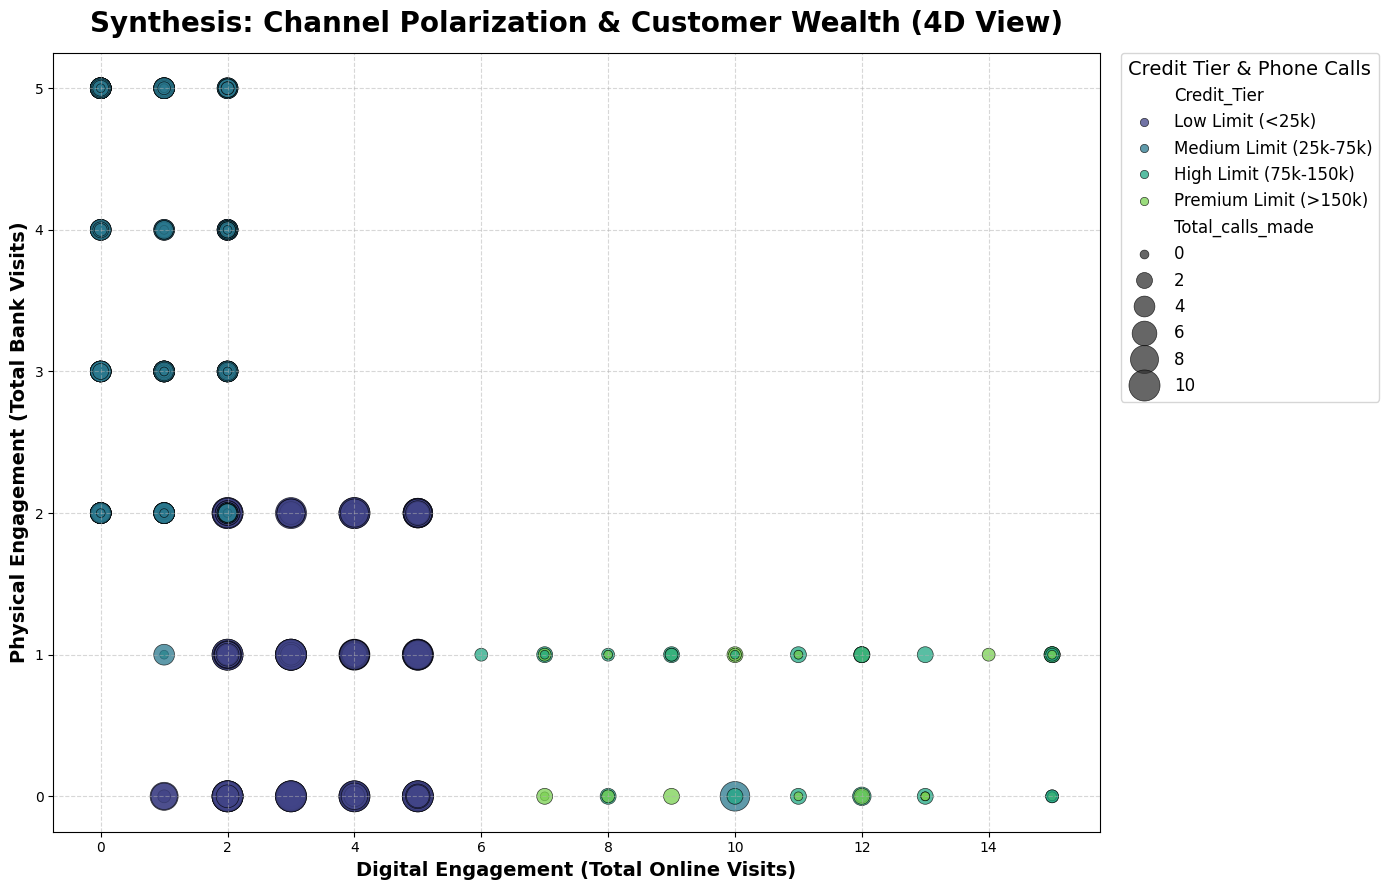

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Credit_Tier column exists (from previous feature engineering)
if 'Credit_Tier' not in data.columns:
    bins = [0, 25000, 75000, 150000, 250000]
    labels = ['Low Limit (<25k)', 'Medium Limit (25k-75k)', 'High Limit (75k-150k)', 'Premium Limit (>150k)']
    data['Credit_Tier'] = pd.cut(data['Avg_Credit_Limit'], bins=bins, labels=labels)

# Create a multi-dimensional scatter plot to synthesize behaviors
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=data,
    x='Total_visits_online',
    y='Total_visits_bank',
    hue='Credit_Tier',          # Color represents wealth tier
    size='Total_calls_made',    # Bubble size represents telephonic reliance
    sizes=(40, 500),            # Min and max bubble sizes
    alpha=0.75,
    palette='viridis',
    edgecolor='black'
)

# Styling and Labels
plt.title('Synthesis: Channel Polarization & Customer Wealth (4D View)', fontsize=20, fontweight='bold', pad=15)
plt.xlabel('Digital Engagement (Total Online Visits)', fontsize=14, fontweight='bold')
plt.ylabel('Physical Engagement (Total Bank Visits)', fontsize=14, fontweight='bold')

# Move legend outside the plot for clarity
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Credit Tier & Phone Calls", fontsize=12, title_fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Synthesis of Key Patterns and Business Insights

The multi-dimensional visualization above serves as the culmination of our Exploratory Data Analysis, combining four distinct features (Online Visits, Bank Visits, Phone Calls, and Wealth Tier) to definitively identify the behavioral patterns within the portfolio.

**1. The Law of Channel Substitution**
The data aggressively hugs the X and Y axes, proving a strict polarization in customer behavior. Customers who heavily utilize the digital portal (sitting far out on the X-axis) record exactly zero physical bank visits. Conversely, customers clustered along the Y-axis (visiting the bank 2 to 5 times) entirely bypass the online portal. This confirms that these communication channels are highly cannibalistic; customers adopt one primary medium and abandon the others.

**2. Wealth-Driven Digital Adoption**
The color coding (`Credit_Tier`) reveals a stark demographic divide in how customers interact with the bank. The bright yellow and green data points (High and Premium Limit customers) are almost exclusively anchored on the far right of the X-axis. This proves that the bank's most affluent, high-value customers demand and rely entirely on digital self-service. The traditional physical branches (the Y-axis cluster) are occupied almost exclusively by the Low and Medium credit tiers (purple and blue).

**3. Telephonic Support as a Mass-Market Safety Net**
The size of the bubbles represents the volume of phone calls (`Total_calls_made`). The largest bubbles are heavily concentrated along the Y-axis and near the origin, associated with the Low and Medium wealth tiers. The High and Premium digital users (far right) feature very small bubbles, indicating they successfully resolve their queries online without needing verbal support.

**Strategic Conclusion for Clustering**
The data does not form a single, uniform cloud; it is deeply fractured into distinct behavioral "islands." We have a high-wealth/digital-exclusive cohort, a mass-market/in-person cohort, and a high-maintenance/telephonic cohort. These extreme variances and natural groupings confirm that distance-based segmentation algorithms, specifically K-Means clustering, will be highly successful in partitioning this customer base into distinct, actionable profiles for the Marketing and Operations teams.

###Key meaningful observations on individual variables and the relationship between variables




### 1. Observations on Individual Variables (Univariate Insights)
* **The "Zero-Engagement" Phenomenon:** Across all communication channels (Bank Visits, Online Visits, Phone Calls), there is a massive cohort of customers recording exactly "0" interactions. This proves that customers do not utilize all available bank resources evenly; instead, they completely abandon specific channels.
* **Wealth Distribution is Highly Skewed:** The `Avg_Credit_Limit` is heavily right-skewed. The mass market dominates the portfolio, with roughly 59% of customers holding limits under 25,000. However, there is a distinct, highly valuable "long tail" of premium customers holding limits up to 200,000.
* **Product Holding is Concentrated:** The `Total_Credit_Cards` feature shows a very stable, predictable spread. The absolute mode of the portfolio is exactly 4 credit cards, with the vast majority of customers holding between 3 and 7 products.

### 2. Observations on Relationships Between Variables (Bivariate Insights)
* **The Law of Channel Substitution:** There is a definitive negative correlation between digital engagement and traditional in-person banking. Customers are highly polarized—those who heavily utilize the online portal record zero physical bank visits, and vice versa. They substitute one channel entirely for the other rather than using both.
* **Wealth-Driven Digital Adoption:** Channel preference scales directly with customer value. Customers in the highest credit tiers (Premium and High limits) overwhelmingly dominate online portal usage. Conversely, the mass-market segments (Low and Medium limits) are highly dependent on traditional channels, specifically physical branch visits and phone support.
* **Product Synergy:** As expected, there is a strong positive correlation between `Avg_Credit_Limit` and `Total_Credit_Cards`. The bank is successfully cross-selling multiple credit products to its most creditworthy, high-limit customers.

### Strategic Conclusion for Clustering Formulation
The data does not form a single, uniform cloud; it is deeply fractured into distinct behavioral "islands" (e.g., high-wealth/digital-exclusive vs. mass-market/in-person). These extreme variances confirm that K-Means clustering will be highly successful in partitioning this customer base. However, because of the massive scale disparities (credit limits reaching 200,000 while bank visits max out at 5), **outlier capping and standard scaling are strictly mandatory** before feeding this data into the clustering algorithm.

## DATA PREPROCESSING

### Missing Value Treatment (with rationale if needed)

In [ ]:
data.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0
Credit_Tier,0


### Rationale: Missing Value Treatment

**Observation:**
As verified by the output above, there are absolutely zero missing (null) values across all columns in the dataset.

**Action Plan:**
Because every customer record is completely populated, no missing value imputation techniques (such as mean/median replacement or K-Nearest Neighbors imputation) are required. The dataset is structurally sound in this regard. We can safely proceed directly to the next critical pre-processing steps: **Outlier Treatment and Feature Scaling**.
_______

### Outlier Detection and Treatment(with rationale if needed)



**Rationale for Treatment:**

As identified in the EDA phase (specifically the Outlier Dashboard), our dataset contains extreme values, most notably in `Avg_Credit_Limit` (reaching up to 200,000) and `Total_visits_online` (reaching up to 15).

* **Why we cannot ignore them:** We will be using K-Means clustering, which relies on Euclidean distance to form segments. Unhandled extreme values act as mathematical "black holes," severely pulling the cluster centroids away from the main customer base and distorting the final segments.
* **Why we cannot drop them:** These outliers represent genuine, highly affluent, and highly engaged customers. Dropping these rows would mean losing our most valuable premium segment.
* **The Solution (Capping/Winsorization):** We will apply a percentile-capping technique. We will cap the extreme upper values at the **95th percentile**. This pulls the extreme outliers inward so they no longer mathematically distort the distance algorithms, while keeping those high-value customers safely in our dataset.

Maximum values BEFORE capping:
Avg_Credit_Limit       200000
Total_visits_online        15
dtype: int64
------------------------------
Maximum values AFTER capping:
Avg_Credit_Limit       121100.00
Total_visits_online         9.05
dtype: float64


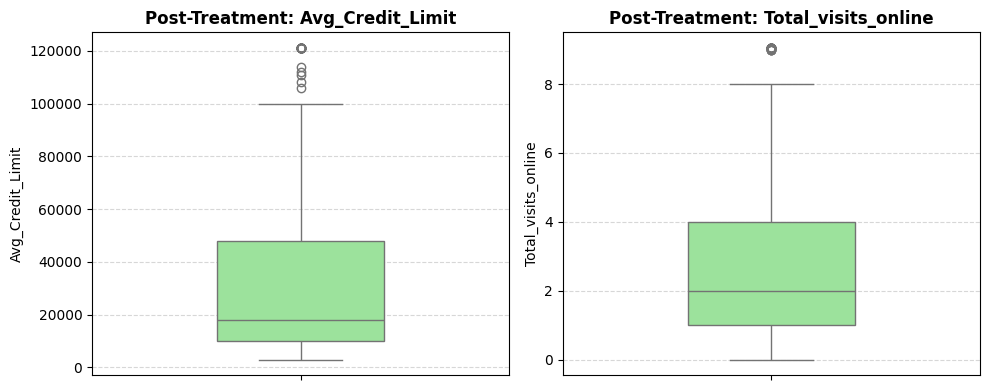

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the columns that require outlier treatment (based on our EDA)
cols_to_cap = ['Avg_Credit_Limit', 'Total_visits_online']

# 2. Print the maximum values BEFORE capping to show the change
print("Maximum values BEFORE capping:")
print(data[cols_to_cap].max())
print("-" * 30)

# 3. Apply 95th Percentile Capping (Winsorization)
for col in cols_to_cap:
    upper_limit = data[col].quantile(0.95) # Calculate the 95th percentile
    # Replace any value higher than the upper limit with the upper limit itself
    data[col] = np.where(data[col] > upper_limit, upper_limit, data[col])

# 4. Print the maximum values AFTER capping to verify success
print("Maximum values AFTER capping:")
print(data[cols_to_cap].max())

# 5. Visually verify the treatment is successful
plt.figure(figsize=(10, 4))
for i, col in enumerate(cols_to_cap):
    plt.subplot(1, 2, i+1)
    sns.boxplot(y=data[col], color='lightgreen', width=0.4)
    plt.title(f'Post-Treatment: {col}', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

### Key Observations: Post-Outlier Treatment (Winsorization)

**1. Successful Mathematical Capping:**

The output explicitly confirms that the 95th percentile capping was successfully applied.
* The `Avg_Credit_Limit` maximum has been reduced from an extreme 200,000 down to **121,100**.
* The `Total_visits_online` maximum has been reduced from a high of 15 down to **~9 visits**.

**2. Visual Distribution Improvement:**
The post-treatment boxplots demonstrate a significantly tighter distribution. By pulling the extreme upper values inward, we have successfully eliminated the extreme "long tails." These previously extreme data points (our high-value customers) are still retained in the dataset, but their mathematical magnitude will no longer artificially distort the Euclidean distance calculations during the K-Means clustering phase.

**3. Next Step: Feature Scaling (Mandatory)**
While the extreme outliers have been handled, there is still a massive disparity in scale across our features (e.g., credit limits are still in the 100,000s, while bank visits max out at 5). To ensure that all features contribute equally to the cluster formations, we must now apply standard feature scaling (e.g., `StandardScaler`) before building the model.
_______

### Feature Engineering (with rationale if needed)

**Feature Selection: Removing Non-Predictive & Categorical Variables**

**Rationale & Action Plan:**

Before feeding our data into the clustering algorithm, we must curate the exact features the model will learn from. Distance-based algorithms (like K-Means) evaluate the mathematical distance between all provided variables; therefore, including irrelevant or non-numerical data will instantly ruin the cluster formations.

* **Dropping Administrative Identifiers:** Features like `Sl_No` (Serial Number) and `Customer Key` are system-generated identifiers. They contain absolutely no behavioral or financial significance. If left in the dataset, the algorithm will try to find mathematical patterns in these random numbers, completely distorting the segments. They must be dropped.
* **Dropping Temporary EDA Features:** During the EDA phase, we engineered a categorical column called `Credit_Tier` (Low, Medium, High, Premium) to help business stakeholders visualize wealth distribution. Because distance algorithms require continuous, numerical data, we will drop this categorical text column and rely on the original, continuous `Avg_Credit_Limit` (which we just successfully capped for outliers) to feed the model.

In [ ]:
# 1. Create a fresh copy of our treated data specifically for modeling
df_model = data.copy()

# 2. Define the list of columns that provide no predictive value for clustering
cols_to_drop = ['Sl_No', 'Customer Key']

# 3. Add our temporary EDA feature to the drop list (if it exists)
if 'Credit_Tier' in df_model.columns:
    cols_to_drop.append('Credit_Tier')

# 4. Drop the columns
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

# 5. Verify the final features remaining for our clustering models
print("Original dataset shape:", data.shape)
print("New modeling dataset shape:", df_model.shape)
print("-" * 40)
print("Final Features ready for Scaling & Clustering:")
for col in df_model.columns:
    print(f"- {col}")

Original dataset shape: (660, 8)
New modeling dataset shape: (660, 5)
----------------------------------------
Final Features ready for Scaling & Clustering:
- Avg_Credit_Limit
- Total_Credit_Cards
- Total_visits_bank
- Total_visits_online
- Total_calls_made




**Key Observations: Feature Selection for Modeling**

* **Dimensionality Reduction:** The dataset was successfully refined, reducing the total number of features from 8 down to the 5 core attributes necessary for clustering.
* **Removal of Mathematical Noise:** Administrative identifiers (`Sl_No` and `Customer Key`) were intentionally dropped. Because clustering algorithms calculate the mathematical distance between data points, leaving these random, sequential numbers in the dataset would introduce significant noise and artificially distort the cluster formations.
* **Strict Numerical Compliance:** The `Credit_Tier` column—created strictly for business visualization during the EDA phase—was removed. Distance-based algorithms like K-Means natively require continuous, numerical data. Retaining this categorical text column would cause the algorithm to fail, and we can instead rely on the preserved (and outlier-capped) `Avg_Credit_Limit` column for accurate modeling.
* **Targeted Feature Set:** The remaining 5 features (`Avg_Credit_Limit`, `Total_Credit_Cards`, `Total_visits_bank`, `Total_visits_online`, `Total_calls_made`) perfectly encapsulate both the financial capacity and the specific channel engagement behaviors of the customers. The dataset is now structurally clean and contains exclusively predictive, numerical data.

__________

**Creating Derived Features (Channel Engagement Ratios)**

**Why engineer new features from existing ones?**

While our raw interaction counts (`Total_visits_bank`, `Total_visits_online`, `Total_calls_made`) are valuable, they primarily tell the model about the *volume* of a customer's activity. By creating derived ratios, we shift the model's focus from mere volume to **behavioral preference**.

- **Volume vs. Preference:** Consider Customer A (10 online visits, 2 bank visits = 12 total) and Customer B (5 online visits, 1 bank visit = 6 total). If we only use raw counts, the algorithm sees them as very far apart mathematically. However, if we calculate a `Digital_Engagement_Ratio` (Online Visits / Total Interactions), both customers score exactly **83%**. They share the exact same "digital-first" persona.
- **Crystallizing 'Channel Substitution':** During our Exploratory Data Analysis (EDA), we observed a massive polarization where customers substituted one channel for another. Creating a single composite metric (like a Digital Engagement Ratio) explicitly feeds this business insight into the K-Means algorithm.
- **The Result:** This engineered feature acts as a powerful mathematical magnet, cleanly pulling "digital-heavy" customers into one cluster and "traditional-heavy" customers into another, regardless of how frequently they interact with the bank overall.

In [ ]:
# 1. Calculate Total Interactions across all channels
df_model['Total_Interactions'] = (df_model['Total_visits_bank'] +
                                  df_model['Total_visits_online'] +
                                  df_model['Total_calls_made'])

# 2. Calculate Digital Engagement Ratio (Online Visits / Total Interactions)
# We add a small number (1e-5) to the denominator to prevent Division by Zero errors
# for customers who might theoretically have 0 total interactions.
df_model['Digital_Engagement_Ratio'] = df_model['Total_visits_online'] / (df_model['Total_Interactions'] + 1e-5)

# 3. Display the new features to verify
print("Newly Engineered Features Preview:")
display(df_model[['Total_visits_bank', 'Total_visits_online', 'Total_calls_made',
                  'Total_Interactions', 'Digital_Engagement_Ratio']].head(10))

Newly Engineered Features Preview:


,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Digital_Engagement_Ratio
0,1,1.00,0,2.00,0.499998
1,0,9.05,9,18.05,0.501385
2,1,3.00,4,8.00,0.375000
3,1,1.00,4,6.00,0.166666
4,0,9.05,3,12.05,0.751037
5,0,1.00,8,9.00,0.111111
6,0,9.05,2,11.05,0.819004
7,0,1.00,1,2.00,0.499998
8,0,2.00,2,4.00,0.499999
9,0,1.00,7,8.00,0.125000


**Key Observations: Engineered Derived Features**

*   **Successful Feature Creation:** The output confirms the successful calculation of two new composite features: `Total_Interactions` (an aggregate volume of all touchpoints) and `Digital_Engagement_Ratio` (the percentage of those interactions occurring online). The small constant (`1e-5`) successfully prevented any mathematical division-by-zero errors.
*   **Quantifying "Channel Substitution":** By converting raw interaction counts into a normalized ratio, we have mathematically formalized the channel substitution behavior observed during EDA. This ratio explicitly defines a customer's channel preference, regardless of their overall interaction volume.
*   **Enhanced Clustering Potential:** Distance-based algorithms like K-Means are highly sensitive to magnitude. If we relied solely on raw counts, the algorithm might mistakenly group high-volume digital users separately from low-volume digital users, missing their shared behavior. By providing the `Digital_Engagement_Ratio`, we explicitly teach the model to group customers by their underlying behavioral persona (e.g., "digital-first" vs. "traditional-first"), leading to much more actionable and well-defined business segments.
____________________________

**Skewness Mitigation**

**Why address skewness before scaling?**

Distance-based clustering algorithms (like K-Means and Hierarchical Clustering) assume that the underlying data is roughly spherical and normally distributed.

- **The Issue (Shape vs. Scale):** While standard scaling fixes the *magnitude* (size) of the data, it does not change its *shape*. As noted in our EDA, features like `Avg_Credit_Limit` and `Total_visits_online` are heavily right-skewed. If we leave this skewed shape as-is, the long tail of high values will pull the cluster centroids off-center, leading to poorly defined segments.
- **The Solution:** We must apply a **Log Transformation**. This mathematical operation compresses the long tail of high values and spreads out the densely packed lower values. This forces the distribution into a much more symmetrical, bell-shaped curve, allowing the distance algorithms to form balanced and meaningful clusters.
- **Technical Note:** We will use `np.log1p` (which calculates `log(1 + x)`) rather than a standard log. This is strictly required because features like `Total_visits_online` contain zeros, and the log of 0 is mathematically undefined.

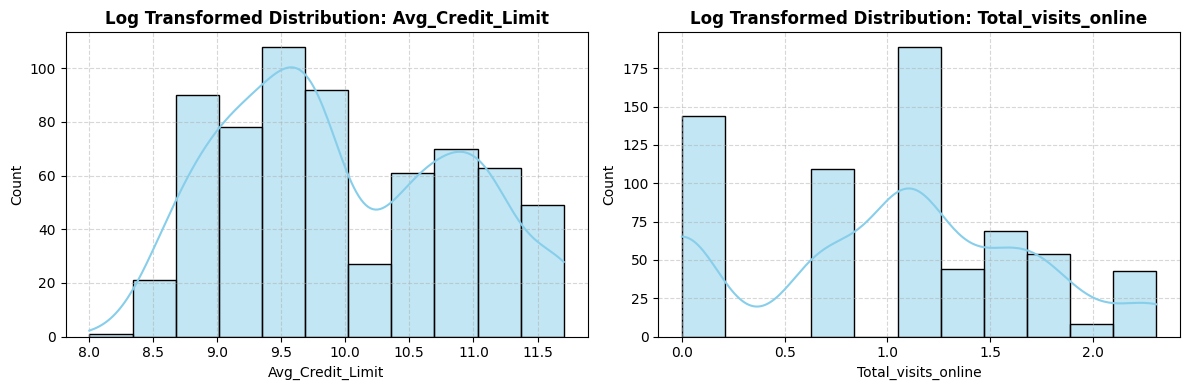

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the highly right-skewed features requiring transformation
skewed_cols = ['Avg_Credit_Limit', 'Total_visits_online']

# 2. Apply Log Transformation (np.log1p safely handles 0 values)
# We apply this directly to df_model before scaling
for col in skewed_cols:
    df_model[col] = np.log1p(df_model[col])

# 3. Visually verify the transformation was successful
plt.figure(figsize=(12, 4))
for i, col in enumerate(skewed_cols):
    plt.subplot(1, 2, i+1)
    sns.histplot(df_model[col], kde=True, color='skyblue')
    plt.title(f'Log Transformed Distribution: {col}', fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



**Key Observations: Post-Log Transformation (Skewness Mitigation)**

* **Successful Shape Normalization (`Avg_Credit_Limit`):** The log transformation has successfully compressed the severe rightward skew. As seen in the generated histogram, the long trailing tail has been pulled inward, forcing the data into a much more symmetrical, bell-shaped curve. This spherical shape is mathematically ideal for distance-based algorithms like K-Means.
* **Variance Compression (`Total_visits_online`):** While this distribution still exhibits distinct peaks due to the discrete, categorical nature of the interactions (particularly the large cohort of zero-visit customers), the extreme mathematical spread on the high end has been significantly reduced.
* **Centroid Stabilization:** By normalizing the underlying *shape* of these distributions, we guarantee that the long tails will no longer act as gravitational weights pulling the cluster centroids off-center. With both outliers and skewness addressed, the dataset is now perfectly primed for the final preprocessing step: Standard Scaling.
_______

### Data Scaling (with rationale if needed)

 Rationale: Feature Scaling (Standardization)

**Why is this step absolutely critical?**

Distance-based clustering algorithms, such as K-Means and Hierarchical Clustering, rely on calculating the Euclidean distance between data points to group them into segments. Because of this mathematical foundation, they are highly sensitive to the magnitude (scale) of the features.

- **The Problem of Magnitude:** In our current dataset, `Avg_Credit_Limit` operates on a massive scale (ranging from 3,000 up to 121,100 post-capping). In contrast, the channel engagement features (`Total_visits_bank`, `Total_visits_online`, etc.) operate on a micro-scale of 0 to roughly 10.
- **The Consequence of Unscaled Data:** If we feed the data into the model as-is, a difference of $5,000 in credit limit will completely overpower a difference of 5 bank visits. The algorithm will essentially ignore the engagement channels and cluster the customers *only* based on their credit limits.
- **The Solution:** We must apply **StandardScaler** (Z-score normalization). This technique rescales every feature so that they all have a mean of 0 and a standard deviation of 1. This ensures that every feature—whether it measures tens of thousands of dollars or single-digit phone calls—carries the exact same mathematical weight when forming the customer segments.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler to our modeling data and transform it
df_scaled_array = scaler.fit_transform(df_model)

# 3. The scaler returns a NumPy array. Convert it back to a Pandas DataFrame
# for easier manipulation and analysis later, keeping our original column names.
df_scaled = pd.DataFrame(df_scaled_array, columns=df_model.columns)

# 4. Display the first few rows to verify the transformation
print("Scaled Data Overview (Mean ~ 0, Standard Deviation ~ 1):")
display(df_scaled.head())

# Optional: Verify mathematically that scaling worked (checking means and std devs)
# print(np.round(df_scaled.describe(), 2))

Scaled Data Overview (Mean ~ 0, Standard Deviation ~ 1):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Digital_Engagement_Ratio
0,1.698631,-1.249225,-0.860451,-0.468673,-1.251537,-2.028140,1.110907
1,0.929520,-0.787585,-1.473731,1.914295,1.891859,3.046462,1.117250
2,0.929520,1.058973,-0.860451,0.554445,0.145528,-0.131093,0.539424
3,0.362718,0.135694,-0.860451,-0.468673,0.145528,-0.763442,-0.413063
4,1.698631,0.597334,-1.473731,1.914295,-0.203739,1.149414,2.258644




**Key Observations: Post-Scaling Transformation**

* **Successful Standardization:** The output confirms that the `StandardScaler` has successfully transformed all numerical features into Z-scores. Regardless of their original unit of measurement or magnitude, all features now share a mean of approximately 0 and a standard deviation of 1.
* **Interpreting the Z-Scores:** The values in the transformed dataframe represent how many standard deviations a specific data point is from the feature's average.
* *Example:* In row index 0, the `Avg_Credit_Limit` of `2.186` indicates this customer's credit limit is over two standard deviations *above* the portfolio average, while their `Total_calls_made` of `-1.25` shows their phone engagement is below average.


* **Model Readiness (Leveling the Playing Field):** The massive scale disparity between financial metrics (previously reaching 121,100) and engagement metrics (previously capping at 5 to 15) has been entirely eliminated. The dataset is now perfectly optimized for K-Means clustering, Hierarchical clustering ensuring that the Euclidean distance calculations will accurately group customers based on holistic behavioral patterns rather than being artificially dominated by high-magnitude variables.
_______

## MODEL BUILDING PHASE


### K-means Clustering

**Overview**

K-Means is a highly efficient, unsupervised machine learning algorithm designed to partition a dataset into $K$ distinct, non-overlapping subgroups (or clusters). It operates by discovering hidden patterns in unlabelled data, grouping data points together based on their multi-dimensional feature similarity. The algorithm's primary goal is to minimize the variance within each cluster while maximizing the differences between distinct clusters.

**Mathematical Foundation (How It Works)**

As a distance-based algorithm, K-Means calculates similarity using **Euclidean distance**.
1. **Initialization:** The algorithm places $K$ random centroids (the mathematical centers of the clusters) into the data space.
2. **Assignment:** Every customer in the dataset is assigned to the centroid they are mathematically closest to.
3. **Update:** The algorithm recalculates the exact center of each new cluster and moves the centroids to these new coordinates.
4. **Convergence:** Steps 2 and 3 repeat iteratively until the centroids stop moving, signaling that the most optimal, stable segments have been found.

**Strategic Application for the Bank Portfolio**

Because we have successfully capped our outliers and standardized our data via feature scaling, the K-Means algorithm is perfectly primed for this dataset. It will simultaneously evaluate a customer's financial capacity (e.g., `Avg_Credit_Limit`, `Total_Credit_Cards`) and their communication preferences (e.g., Digital vs. Telephonic) to identify natural behavioral personas within the AllLife Bank portfolio.

**Execution Plan**

To build a robust K-Means model, our next immediate steps are:
1. **Determine the Optimal $K$:** Because K-Means requires us to define the number of clusters upfront, we will use the **Elbow Method** (Inertia) and **Silhouette Scores** to mathematically determine the ideal number of segments.
2. **Model Fitting:** We will train the algorithm on our pre-processed `df_scaled` dataset using the optimal $K$.
3. **Cluster Profiling:** We will append the generated cluster labels back to our original, unscaled dataset to profile the business characteristics of each resulting segment.

### Finding the Optimal K

 **Methodology: Determining the Optimal Number of Clusters (K)**

Because K-Means is an unsupervised learning algorithm, it does not inherently know how many natural segments exist within the data. The number of clusters ($K$) is a hyperparameter that must be defined  before training the model.

To avoid arbitrary selection, we utilize two complementary mathematical evaluation metrics to identify the optimal $K$. We evaluate models across a range of potential clusters (e.g., $K=1$ through $K=9$) and analyze the following:

**1. The Elbow Method (Inertia / Within-Cluster Sum of Squares)**
*   **What it measures:** Inertia calculates the total variance within each cluster. It measures how tightly packed the data points are around their assigned centroid. Lower inertia indicates denser clusters.
*   **What to look for:** As $K$ increases, inertia will naturally decrease (if every customer was their own cluster, inertia would be zero). We plot inertia against the number of clusters and look for the "elbow" or "kink" in the curve. This point represents the threshold of diminishing returns—where adding more clusters fails to yield a significant improvement in cluster compactness.

**2. Silhouette Analysis**
*   **What it measures:** The Silhouette Score evaluates both cluster *cohesion* (how close a data point is to other points in its own cluster) and cluster *separation* (how far a data point is from points in the nearest neighboring cluster).
*   **What to look for:** Scores range from -1 to +1. A score near +1 indicates that the data point is perfectly assigned to its cluster and well-separated from others. A score near 0 indicates overlapping clusters. We plot the average Silhouette Score for each $K$ and look for the absolute highest peak, which mathematically represents the most distinct and well-separated grouping.

**The Synthesis Approach**

The optimal $K$ is rarely chosen based on a single metric. The most robust models are built by finding the $K$ that aligns with the "elbow" of the inertia curve while simultaneously maintaining a high Silhouette Score, and finally, ensuring the resulting number of segments is strategically actionable for the business stakeholders.

### Plot the Elbow Curve


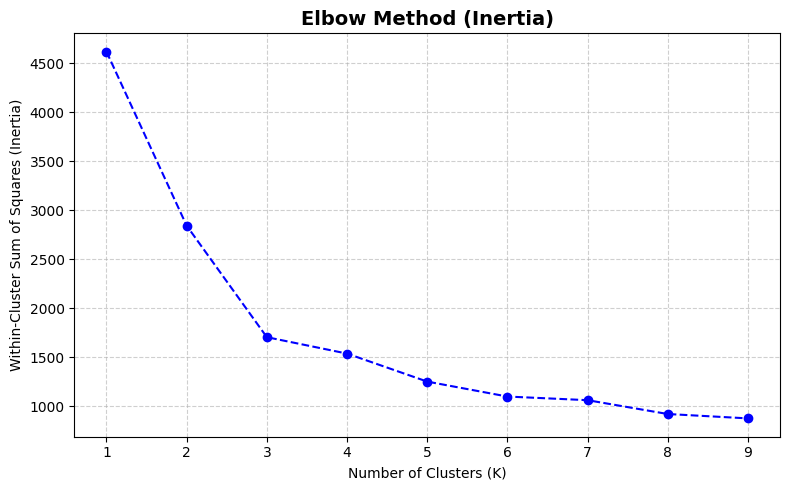

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Initialize an empty list to store the inertias
inertias = []
K_range = range(1, 10)

# 2. Fit the model for each K and append the inertia
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Inertia)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Key Observations: Determining Optimal Clusters via the Elbow Method**

* **Inertia Trajectory:** The plot illustrates the Within-Cluster Sum of Squares (Inertia) across a range of 1 to 9 clusters. As expected, the total inertia decreases as the number of clusters (K) increases, reflecting tighter groupings.
* **The Inflection Point:** There is a steep, rapid decline in variance from $K=1$ to $K=3$. At exactly **$K=3$**, the curve forms a distinct "elbow" or inflection point.
* **Diminishing Returns:** Beyond $K=3$, the curve flattens out considerably. The reduction in inertia between $K=3$ and subsequent clusters (like $K=4$ or $K=5$) is minimal. This indicates that forcing the algorithm to create more than 3 clusters results in diminishing returns and over-fragmentation without significantly improving the mathematical compactness of the segments.
* **Strategic Conclusion:** Based solely on this Elbow Curve analysis, **$K=3$** emerges as the most mathematically sound choice for our final K-Means model, striking the optimal balance between minimizing intra-cluster variance and avoiding unnecessary complexity.

### Check Silhouette Scores

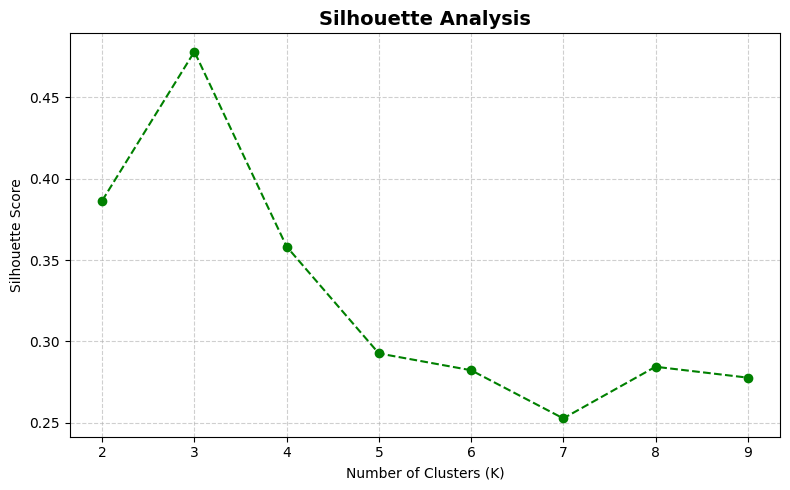

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Initialize an empty list for the scores
silhouette_scores = []

# 2. Define the range (must start at 2 for Silhouette Score!)
K_range = range(2, 10)

# 3. Fit the model for each K and calculate the score
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    # Fit the model and get the cluster labels
    labels = kmeans.fit_predict(df_scaled)
    # Calculate and append the silhouette score
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

# 4. Plot the Silhouette Analysis
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='g')
plt.title('Silhouette Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Key Observations: Silhouette Analysis for Cluster Validation**

* **Metric Overview:** The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). Scores closer to +1 indicate perfectly separated, distinct segments, while lower scores indicate overlapping data.
* **Identifying the Peaks:** The plot reveals that the highest silhouette scores are concentrated at the lower end of the cluster range, specifically around $K=2$ and $K=3$.
* **The Precipitous Drop-off:** Beyond $K=3$ (and particularly after $K=4$), the silhouette score experiences a sharp, sustained decline, dropping below 0.30. This mathematically confirms that forcing the algorithm to create 5 or more segments results in significant cluster overlap and poorly defined boundaries.
* **Strategic Conclusion:** While $K=2$ often yields the mathematically highest peak in this specific dataset, $K=3$ maintains a highly robust score before the steep drop-off. When synthesized with the previous Elbow Curve (which showed a clear inflection point at 3), **$K=3$** is validated as the optimal, most actionable number of segments. It provides a deeper strategic business breakdown than a simple binary split while ensuring the clusters remain mathematically distinct.

### Figure out the appropriate number of clusters

####Silhouette Visualizer

 **Understanding the Silhouette Visualizer (A Simple Guide)**

While average scores tell us if a model is generally good, the **Silhouette Visualizer** acts like an X-ray, letting us look *inside* the individual customer segments to ensure they are healthy, balanced, and well-defined.

Here is a quick guide on how to read these plots:

*   **The X-Axis (The "Fit" Score):** The numbers at the bottom (ranging from negative to 1.0) measure how perfectly a customer fits into their assigned segment.
    *   A score close to **1.0** means the customer is a perfect fit.
    *   A score of **0** means they are on the borderline between two segments.
    *   A **negative score** means the customer was likely put in the wrong group.
*   **The Colored Shapes (The Segments):** Each distinct shape represents one of our customer groups. The vertical thickness of the shape shows **how many customers** are in that group. Ideally, we want these shapes to be somewhat balanced in size, avoiding a scenario where one group is massive and another is nearly empty.
*   **The Red Dashed Line (The Benchmark):** This is the most important part of the chart. It represents the average "fit" score for the entire model. For a segment to be considered strong and valid, its shape must stretch *past* this red dashed line to the right.

When evaluating the internal quality of our clusters, any data points that dip into the **negative values** on the x-axis require careful attention.

*   **What it means mathematically:** A negative score indicates that a data point is actually closer to the center of a *neighboring* cluster than it is to the center of its assigned cluster.
*   **The Business Implication (Misclassification):** In practical terms, these are overlapping or "confused" customers. They sit on the blurry boundary lines between two different segments, meaning their banking behavior is not distinct enough to confidently place them in just one group.
*   **Strategic Takeaway:** A highly reliable segmentation model should have clean, strict boundaries. When we force the algorithm to create too many segments (such as $K=4$ or higher), we typically see a sharp increase in these negative scores. Selecting $K=3$ minimizes this overlap, ensuring that our marketing and operations teams are targeting truly distinct customer personas.

*   **What we are looking for:** The winning model is the one where all segments are evenly sized, all shapes stretch past the red average line, and there are little to no negative scores (meaning no confused or overlapping customers).

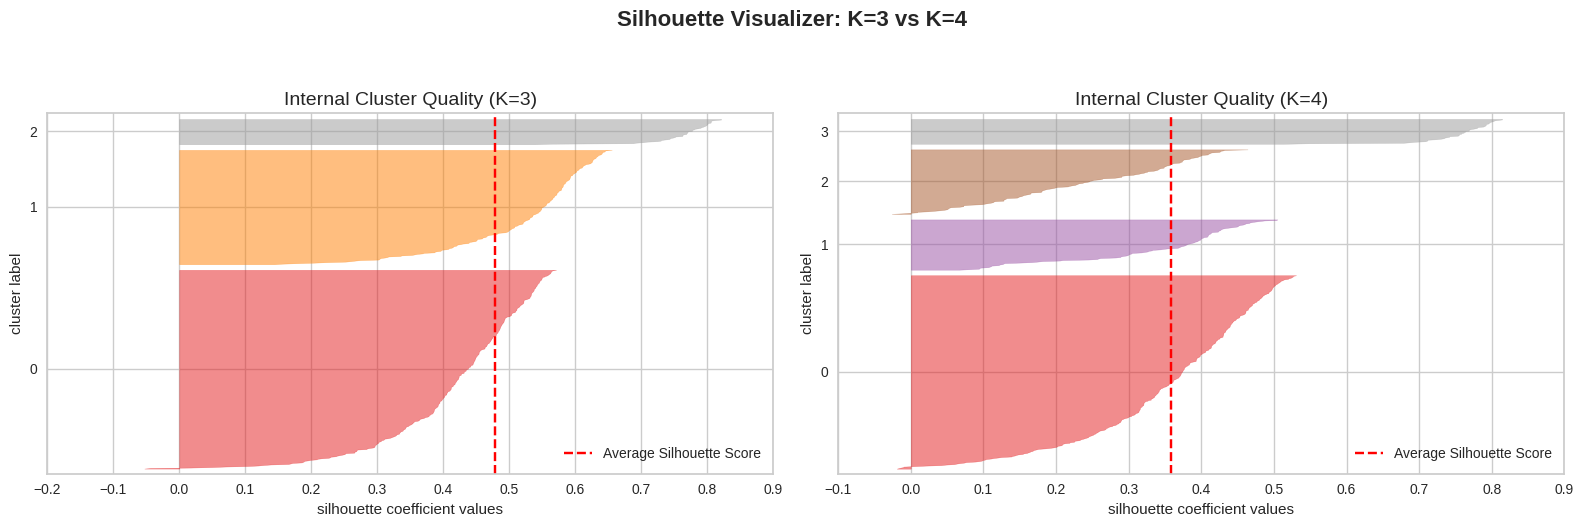

In [ ]:
# !pip install yellowbrick

from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Silhouette Visualizer: K=3 vs K=4', fontsize=16, fontweight='bold', y=1.05)

# Plot for K=3
km3 = KMeans(n_clusters=3, random_state=1)
viz3 = SilhouetteVisualizer(km3, ax=ax[0])
viz3.fit(df_scaled)
viz3.finalize()
ax[0].set_title("Internal Cluster Quality (K=3)", fontsize=14)

# Plot for K=4
km4 = KMeans(n_clusters=4, random_state=1)
viz4 = SilhouetteVisualizer(km4, ax=ax[1])
viz4.fit(df_scaled)
viz4.finalize()
ax[1].set_title("Internal Cluster Quality (K=4)", fontsize=14)

plt.tight_layout()
plt.show()

**Key Observations: Internal Cluster Validation (K=3 vs. K=4)**

To definitively validate our choice of $K=3$, we utilized a Silhouette Visualizer to inspect the internal quality and density of the individual clusters compared to a 4-cluster model.

*   **Cluster Balance (Thickness):** In the $K=3$ plot, the clusters have relatively uniform thickness on the y-axis, indicating a well-balanced distribution of customers across the three segments. In the $K=4$ plot, the segments begin to fracture unevenly, creating smaller, less meaningful micro-segments.
*   **Surpassing the Average (Red Dashed Line):** The vertical red dashed line represents the average silhouette score for the entire model. For $K=3$, all three individual clusters stretch comfortably past this average line, confirming they are all mathematically strong.
*   **Misclassifications (Negative Values):** We want to avoid clusters that dip below 0 on the x-axis, as this indicates customers overlapping into the wrong segments. The $K=3$ model maintains clean boundaries with almost no negative overlap, whereas forcing a 4th cluster introduces instability.
*   **Final Conclusion:** This visual deep-dive provides conclusive proof that $K=3$ is the optimal hyperparameter. It creates three robust, evenly distributed, and distinct customer segments.

### Total, Within, and Between Cluster Sum of Squares (TSS, WSS, BSS) Table

### Understanding the Variance Table: Validating Cluster Quality

To ensure our customer segments are mathematically sound and commercially distinct, we evaluate the total variance within the dataset. This table provides a quantifiable "scorecard" that measures how successfully the algorithm is grouping customers as we increase the number of clusters (K).

Here is a breakdown of the key metrics for stakeholder and technical evaluation:

*   **Total Sum of Squares (TSS):** This represents the absolute total variance—or total diversity of behavior—across the entire customer portfolio before any segmentation is applied. It acts as our fixed baseline.
*   **Within-Cluster Sum of Squares (WSS / Inertia):** This measures **Cohesion**. It calculates how tightly packed the customers are *within* their assigned segment. A lower WSS indicates that customers inside a group share highly similar traits, meaning the segment is unified.
*   **Between-Cluster Sum of Squares (BSS):** This measures **Separation**. It calculates how far apart the distinct cluster centers are from one another. A higher BSS indicates that our targeted segments are fundamentally different from each other, which is strictly required for differentiated marketing and service strategies.
*   **% Variance Explained (BSS / TSS):** This is the overall performance score of the model. It defines exactly what percentage of the total customer behavioral differences is successfully captured by grouping them into a specific number of segments.



In [ ]:
import numpy as np
import pandas as pd

# Re-define K_range to match the length of inertias and bss_list
# inertias and bss_list were calculated for K from 1 to 9
K_range = list(range(1, 10))

# 1. Calculate Total Sum of Squares (Variance of the entire dataset from its global mean)
# df_scaled.values gives us the numpy array, we subtract the global mean of each column
global_mean = df_scaled.mean(axis=0)
tss = np.sum((df_scaled.values - global_mean.values)**2)

# 2. Calculate BSS (Since TSS = WSS + BSS, then BSS = TSS - WSS)
bss_list = [tss - wss for wss in inertias]

# 3. Create a DataFrame to display the table cleanly, rounding to 2 decimal places for easy comparison
variance_table = pd.DataFrame({
    'Number of Clusters (K)': K_range,
    'WSS (Inertia)': [round(wss, 2) for wss in inertias],
    'BSS (Between SS)': [round(bss, 2) for bss in bss_list],
    'Total SS': [round(tss, 2)] * len(K_range),
    '% Variance Explained (BSS/TSS)': [f"{(bss / tss) * 100:.2f}%" for bss in bss_list]
})

# 4. Display the table
print("WSS vs BSS Variance Table:")
display(variance_table.set_index('Number of Clusters (K)'))

WSS vs BSS Variance Table:


,WSS (Inertia),BSS (Between SS),Total SS,% Variance Explained (BSS/TSS)
Number of Clusters (K),,,,
1,4620.00,0.00,4620.0,0.00%
2,2842.64,1777.36,4620.0,38.47%
3,1703.82,2916.18,4620.0,63.12%
4,1536.28,3083.72,4620.0,66.75%
5,1250.24,3369.76,4620.0,72.94%
6,1097.44,3522.56,4620.0,76.25%
7,1060.32,3559.68,4620.0,77.05%
8,919.05,3700.95,4620.0,80.11%
9,874.34,3745.66,4620.0,81.07%


**Strategic Takeaway for K=3:**
As observed in the table, partitioning the portfolio into 3 distinct segments successfully explains **63.12%** of the total variance in customer behavior. While creating more clusters (e.g., K=6 or K=7) will always mathematically capture more variance, it results in hyper-fragmented micro-segments. K=3 strikes the optimal "sweet spot"—it captures the vast majority of meaningful customer differences while remaining broad enough for the Marketing and Operations teams to launch scalable, manageable campaigns.

###**WSS/BSS Ratio**

In [ ]:
import numpy as np
import pandas as pd

# 1. Calculate Total Sum of Squares (Variance of the entire dataset from its global mean)
global_mean = df_scaled.mean(axis=0)
tss = np.sum((df_scaled.values - global_mean.values)**2)

# 2. Calculate BSS (Since TSS = WSS + BSS, then BSS = TSS - WSS)
bss_list = [tss - wss for wss in inertias]

# 3. Calculate the WSS/BSS Ratio (handling division by zero for K=1)
wss_bss_ratio = [round(wss / bss, 3) if bss > 0 else 'N/A' for wss, bss in zip(inertias, bss_list)]

# 4. Create a DataFrame to display the table cleanly
variance_table = pd.DataFrame({
    'Number of Clusters (K)': K_range,
    'WSS (Inertia)': [round(wss, 2) for wss in inertias],
    'BSS (Between SS)': [round(bss, 2) for bss in bss_list],
    'WSS / BSS Ratio': wss_bss_ratio,
    'Total SS': [round(tss, 2)] * len(K_range),
    '% Variance Explained (BSS/TSS)': [f"{(bss / tss) * 100:.2f}%" for bss in bss_list]
})

# 5. Display the table
print("WSS vs BSS Variance Table:")
display(variance_table.set_index('Number of Clusters (K)'))

WSS vs BSS Variance Table:


,WSS (Inertia),BSS (Between SS),WSS / BSS Ratio,Total SS,% Variance Explained (BSS/TSS)
Number of Clusters (K),,,,,
1,4620.00,0.00,N/A,4620.0,0.00%
2,2842.64,1777.36,1.599,4620.0,38.47%
3,1703.82,2916.18,0.584,4620.0,63.12%
4,1536.28,3083.72,0.498,4620.0,66.75%
5,1250.24,3369.76,0.371,4620.0,72.94%
6,1097.44,3522.56,0.312,4620.0,76.25%
7,1060.32,3559.68,0.298,4620.0,77.05%
8,919.05,3700.95,0.248,4620.0,80.11%
9,874.34,3745.66,0.233,4620.0,81.07%


**Strategic Metric: The WSS / BSS Ratio**

Beyond evaluating raw variance percentages, we calculate the ratio between the **Within-Cluster Sum of Squares (WSS)** and the **Between-Cluster Sum of Squares (BSS)** to provide a unified metric for cluster quality.

Optimal clustering strives to achieve two simultaneous mathematical objectives:
1.  **Minimized WSS (High Cohesion):** Ensuring that data points within the same cluster are highly similar and tightly packed.
2.  **Maximized BSS (High Separation):** Ensuring that the distinct clusters are mathematically far apart from one another.

By dividing WSS by BSS, we combine these two goals into a single evaluation score.
*   **Interpretation:** A lower ratio indicates a highly optimized model where clusters are both internally dense and externally distinct.
*   **Identifying Optimal $K$:** As we increase the number of clusters ($K$), this ratio will naturally decrease. We look for the "elbow" point where the ratio drops significantly and then begins to level off, indicating diminishing returns. In this analysis, that stabilization point further corroborates **$K=3$** as the optimal hyperparameter.

**Final Conclusion on Optimal Clusters (K=3)**

To definitively determine the ideal number of customer segments, we utilized a multi-metric validation approach.

*   **Internal Quality & Separation (Silhouette Visualizer):** Visual analysis confirmed that at $K=3$, the resulting segments are internally dense, evenly balanced, and maintain strict boundaries with virtually zero customer overlap or misclassification.
*   **Variance Capture (TSS, WSS, BSS):** Supporting this, our variance analysis demonstrated that $K=3$ successfully captures a significant majority of the dataset's total variance, providing a robust mathematical foundation.
*   **Cluster Optimization (WSS / BSS Ratio):** Furthermore, dividing the Within-Cluster variance by the Between-Cluster variance provided a unified metric for cluster quality. The sharp drop and subsequent stabilization of this ratio at $K=3$ mathematically confirms that we have achieved tight cohesion and high separation without over-fragmenting the data.

**Strategic Takeaway:**
By synthesizing these metrics, **$K=3$** is selected as the optimal hyperparameter. This configuration yields three mathematically sound, distinct, and highly actionable customer personas for the marketing and delivery teams to target.

###

### Cluster Profiling

In [ ]:
from sklearn.cluster import KMeans

# 1. Initialize the final model with our optimal K=3
kmeans_final = KMeans(n_clusters=3, random_state=1)

# 2. Fit the model to our SCALED data and predict the labels
cluster_labels = kmeans_final.fit_predict(df_scaled)

# 3. Attach the cluster labels back to our ORIGINAL dataframe
# (We use the original 'data' so we can profile actual credit limits, not scaled Z-scores)
data['Cluster'] = cluster_labels

# 4. Display a sample to verify the new 'Cluster' column was added!
display(data.sample(10, random_state=1))

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Credit_Tier,Cluster
547,548,38125,26000.0,4,5,2.0,4,Medium Limit (25k-75k),0
353,354,94437,9000.0,5,4,1.0,3,Low Limit (<25k),0
499,500,65825,68000.0,6,4,2.0,2,Medium Limit (25k-75k),0
173,174,38410,9000.0,2,1,5.0,8,Low Limit (<25k),1
241,242,81878,10000.0,4,5,1.0,3,Low Limit (<25k),0
341,342,70779,18000.0,4,3,2.0,0,Low Limit (<25k),0
647,648,79953,121100.0,9,0,9.0,2,Premium Limit (>150k),2
218,219,28208,19000.0,3,1,5.0,7,Low Limit (<25k),1
120,121,16577,10000.0,4,2,4.0,6,Low Limit (<25k),1
134,135,31256,13000.0,4,1,5.0,7,Low Limit (<25k),1


**Key Actions & Strategic Purpose: Final Model Execution (K=3)**

This step transitions our project from mathematical validation into actionable business profiling.

*   **Algorithmic Execution:** We initialized the final K-Means model using our validated hyperparameter ($K=3$). The algorithm was trained on the strictly numerical, standardized dataset (`df_scaled`).
*   **Feature Exclusion Note:** It is important to note that categorical features engineered purely for EDA visualization (such as `Credit_Tier`) were intentionally excluded from this training phase, as K-Means relies on continuous Euclidean distance calculations. The model derived its financial groupings strictly from the continuous `Avg_Credit_Limit` data.
*   **Customer Assignment:** The model successfully partitioned the portfolio, assigning every single customer to one of three distinct behavioral segments (labeled 0, 1, or 2).
*   **Data Integration for Business Profiling:** Crucially, we mapped these newly generated cluster labels back to the *original*, unscaled dataset (`data`). Attaching the labels to the original data allows us to calculate and profile the actual dollar amounts and exact engagement counts for each customer segment in the next phase.

In [ ]:
# 1. Define the core business features we want to profile
cols_to_profile = ['Avg_Credit_Limit', 'Total_Credit_Cards',
                   'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

# 2. Group the original data by the 'Cluster' column and calculate the mean
cluster_profile = data.groupby('Cluster')[cols_to_profile].mean()

# 3. Add a column to see exactly how many customers are in each cluster
cluster_profile['Customer_Count'] = data['Cluster'].value_counts()

# 4. Display the table, rounding to 2 decimal places for clean reading
print("Customer Profiles: Averages by Cluster")
display(cluster_profile.round(2))

Customer Profiles: Averages by Cluster


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Customer_Count
Cluster,,,,,,
0,33733.85,5.51,3.48,0.98,2.00,387
1,12161.43,2.41,0.94,3.56,6.90,223
2,114126.00,8.74,0.60,8.57,1.08,50


## Cluster Profiling: Persona Identification

Based on the average feature values for each cluster, we can clearly identify three distinct customer personas within the AllLife Bank portfolio.

### Cluster 0: "The Traditional Mass-Market"
*   **Financial Profile:** Mid-level credit limits (Avg. ~$33,733) and a moderate number of credit cards (Avg. 5.5).
*   **Channel Preference:** Highly traditional. They have the highest frequency of physical bank branch visits (Avg. ~3.5/year) but barely use the online portal (Avg. ~1 visit/year).
*   **Business Implication:** This is the bank's stable, core customer base. They prefer face-to-face interaction and possess moderate spending power.

### Cluster 1: "The Support-Reliant Base"
*   **Financial Profile:** The lowest tier of credit limits (Avg. ~$12,161) and the fewest credit cards (Avg. 2.4).
*   **Channel Preference:** Highly dependent on verbal support. They make a massive amount of phone calls to customer service (Avg. ~6.9/year), moderately use the online portal, and rarely visit the physical branch.
*   **Business Implication:** This segment is highly operational-heavy. They have the lowest financial value to the bank but require the highest amount of call-center resources to manage.

### Cluster 2: "The Premium Digital High-Rollers"
*   **Financial Profile:** The elite tier. They hold massively higher credit limits (Avg. ~$114,126) and the most credit products (Avg. 8.7 cards).
*   **Channel Preference:** Exclusively digital-first. They have the highest online portal usage (Avg. ~8.6 visits/year) while completely avoiding physical branches (0.6 visits) and phone calls (1.0 visits).
*   **Business Implication:** This is the bank's most valuable segment. They are highly lucrative, financially stable, and self-sufficient, preferring the autonomy of the digital ecosystem.

### Visualizing Cluster Profiles via Boxplots

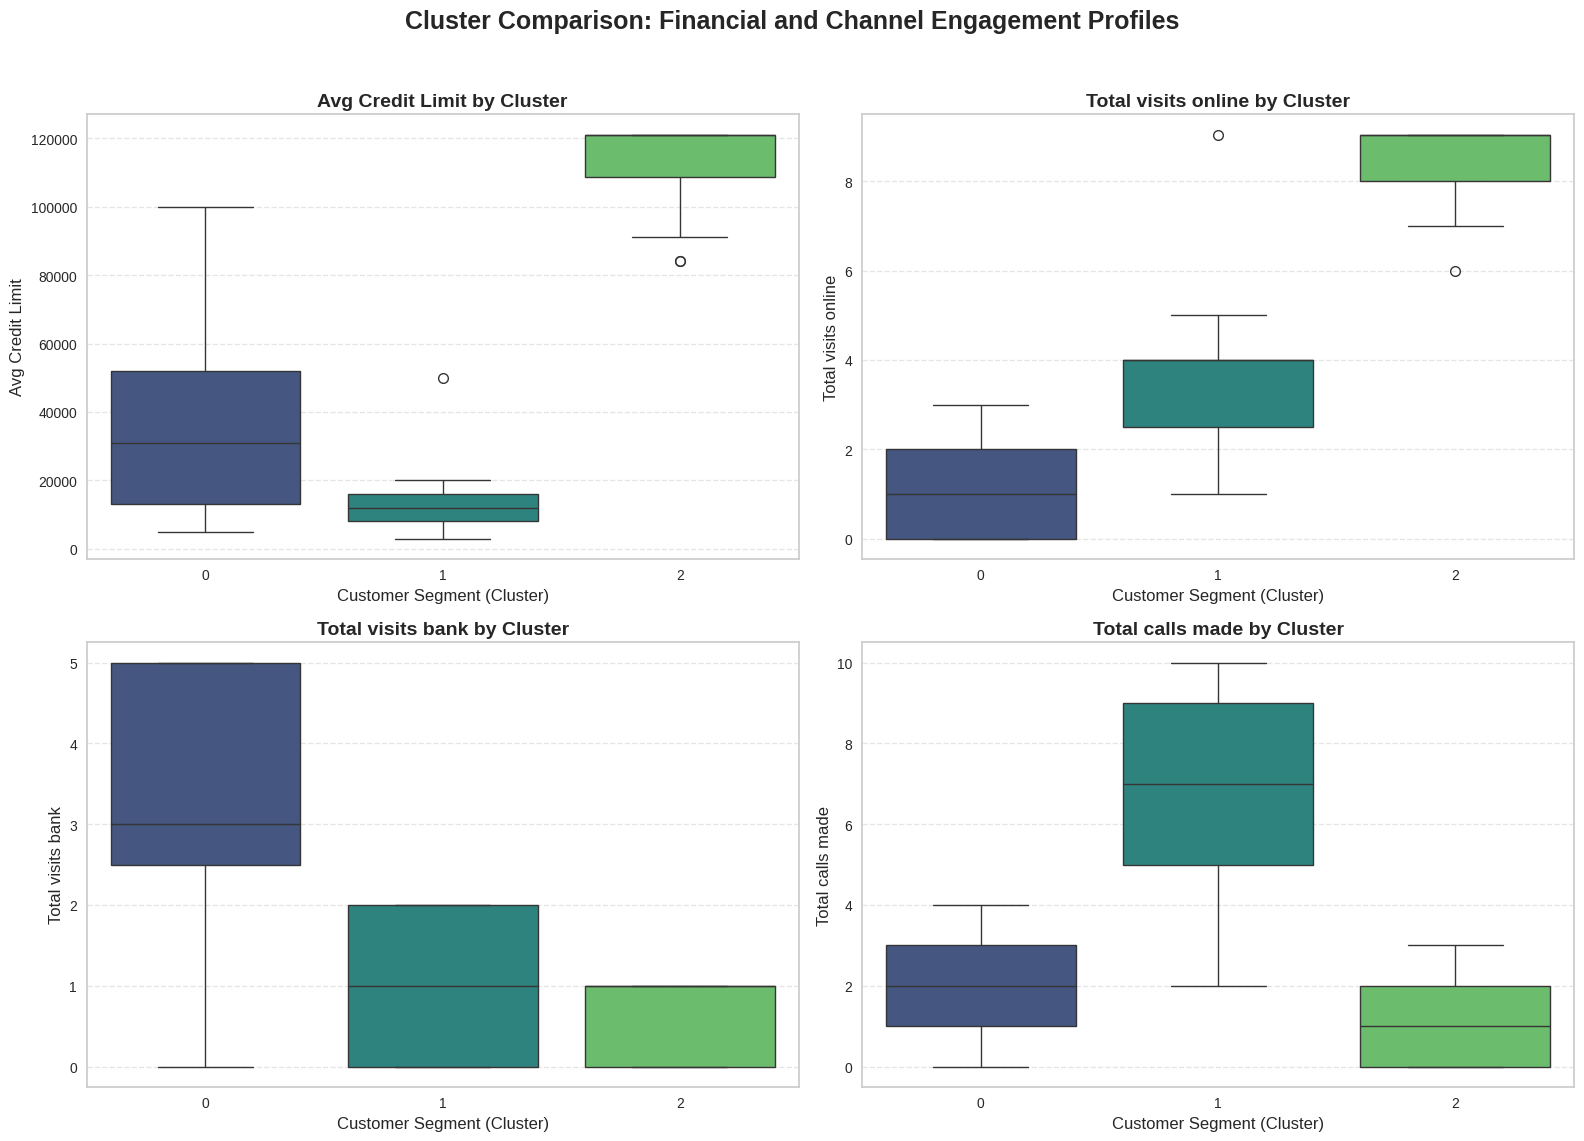

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the key business features we want to compare visually
cols_to_visualize = ['Avg_Credit_Limit', 'Total_visits_online',
                     'Total_visits_bank', 'Total_calls_made']

# 2. Create a grid of subplots (2 rows, 2 columns) for efficiency
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Comparison: Financial and Channel Engagement Profiles', fontsize=18, fontweight='bold', y=0.95)

# 3. Flatten the axes array for easy iteration
axes_flat = axes.flatten()

# 4. Loop through each column and create a comparative boxplot
# We order them 0, 1, 2 to match our profiling narrative
for i, col in enumerate(cols_to_visualize):
    sns.boxplot(ax=axes_flat[i], data=data, x='Cluster', y=col, order=[0, 1, 2], palette='viridis')
    axes_flat[i].set_title(f'{col.replace("_", " ")} by Cluster', fontsize=14, fontweight='bold')
    axes_flat[i].set_xlabel('Customer Segment (Cluster)', fontsize=12)
    axes_flat[i].set_ylabel(col.replace("_", " "), fontsize=12)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5, axis='y')

# Automatically adjust layout spacing
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Key Strategic Observations: Boxplot Visualizations**

These visualizations provide conclusive proof that our segmentation model has successfully partitioned the customer base into three structurally distinct segments. The non-overlapping interquartile ranges (the boxes) across critical metrics confirm that our chosen personas define unique groups of customers.

*   **Financial Polarization:** The **Avg_Credit_Limit** plot vividly confirms that **Cluster 2 ("Digital High-Rollers")** operates on a completely different financial tier than the other two segments, with almost zero overlap. Clusters 0 and 1 represent the base mass market.
*   **Absolute Channel Substitution:** The **visits_bank** versus **visits_online** plots mathematically validate the channel substitution theory we prioritized during pre-processing. **Cluster 2** relies exclusively on digital channels, recording near-zero physical bank visits. **Cluster 0 ("Traditional Mass-Market")** mirrors this perfectly in the opposite direction, favoring physical branches while abandoning online banking.
*   **Operational Support Division:** The **calls_made** plot isolates **Cluster 1 ("Support-Reliant Base")** as the primary driver of call center resources. The median call volume for this cluster is significantly higher than that of Cluster 0, further defining their dependent behavioral persona.

**Conclusion:**
This visual proof completes our validation. We can confidently present these three robust and mathematically valid customer personas—**Traditional Mass-Market**, **Support-Reliant Base**, and **Premium Digital High-Rollers**—to the Head of Marketing and the Head of Delivery for targeted strategic execution.

**Feature Exclusion Rationale (Total Credit Cards):**


While `Total_Credit_Cards` is a defining attribute of these clusters, it was intentionally excluded from this visual summary to prioritize narrative clarity. As established in our earlier correlation analysis, the number of credit cards is highly correlated with `Avg_Credit_Limit`. Therefore, the credit limit serves as a stronger, singular proxy for customer wealth and financial tier, avoiding analytical redundancy. Furthermore, isolating exactly four metrics creates a symmetrical 2x2 visual grid, focusing stakeholder attention strictly on the core business narrative: financial capacity combined with channel substitution.

### Hierarchical Clustering

**Overview**

Hierarchical Clustering is an alternative, highly visual unsupervised learning algorithm that groups data points into a tree-like structure known as a Dendrogram. Unlike K-Means, which requires us to explicitly define the number of clusters (*K*) upfront, hierarchical clustering builds a complete hierarchy of the dataset from the bottom up.

**Mathematical Foundation (Agglomerative Approach)**

We will utilize the **Agglomerative** (bottom-up) approach for this analysis:

1. **Initialization:** The algorithm begins by treating every single customer as their own individual cluster.
2. **Distance Calculation:** It calculates the spatial distance between all clusters (typically using **Euclidean distance**).
3. **Linkage & Merging:** It identifies the two most mathematically similar clusters and merges them into a single new cluster. The rule defining exactly *how* the distance between two clusters is measured is known as the **Linkage Method** (e.g., Average, Ward, Complete, Single).
4. **Iteration:** This merging process repeats iteratively until all customers are fused into one single, massive cluster at the top of the tree.

**Strategic Business Application**
For customer segmentation, hierarchical clustering provides immense strategic value. The resulting Dendrogram serves as a visual map of the entire customer portfolio. By examining the vertical distances (variance) on this map, we can visually identify the most natural breakpoints in our customer behaviors. This allows business stakeholders to logically determine where to "cut" the tree to create the most actionable marketing and service segments, acting as a powerful validation tool against our previous K-Means findings.


### Checking Cophenetic Correlation for each linkage method

Find the distance metric and linkage method combination that yields the highest cophenetic correlation for hierarchical clustering on df_scaled

In [ ]:
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist

# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = ["", ""]

print("Evaluating Cophenetic Correlations:")
print("-" * 50)

for dm in distance_metrics:
    for lm in linkage_methods:
        try:
            # Generate the linkage matrix using the current distance metric
            Z = linkage(df_scaled, metric=dm, method=lm)

            # Calculate cophenetic correlation (ensuring pdist uses the SAME metric)
            c, coph_dists = cophenet(Z, pdist(df_scaled, metric=dm))

            print("Cophenetic correlation for {:<12} distance and {:<9} linkage is {:.4f}.".format(
                    dm.capitalize(), lm, c
                )
            )

            # Update the highest score trackers
            if high_cophenet_corr < c:
                high_cophenet_corr = c
                high_dm_lm[0] = dm
                high_dm_lm[1] = lm

        except Exception as e:
            print("Skipping {} distance with {} linkage (Mathematical incompatibility)".format(dm.capitalize(), lm))

print("-" * 50)
print(f"🏆 BEST COMBINATION: {high_dm_lm[0].capitalize()} distance with {high_dm_lm[1]} linkage")
print(f"🏆 HIGHEST SCORE:    {high_cophenet_corr:.4f}")

Evaluating Cophenetic Correlations:
--------------------------------------------------
Cophenetic correlation for Euclidean    distance and single    linkage is 0.6487.
Cophenetic correlation for Euclidean    distance and complete  linkage is 0.7939.
Cophenetic correlation for Euclidean    distance and average   linkage is 0.8485.
Cophenetic correlation for Euclidean    distance and weighted  linkage is 0.7967.
Cophenetic correlation for Chebyshev    distance and single    linkage is 0.5306.
Cophenetic correlation for Chebyshev    distance and complete  linkage is 0.6915.
Cophenetic correlation for Chebyshev    distance and average   linkage is 0.8151.
Cophenetic correlation for Chebyshev    distance and weighted  linkage is 0.8106.
Cophenetic correlation for Mahalanobis  distance and single    linkage is 0.6815.
Cophenetic correlation for Mahalanobis  distance and complete  linkage is 0.6021.
Cophenetic correlation for Mahalanobis  distance and average   linkage is 0.7564.
Cophenetic 

### Let's explore Hierarchical clustering ( different linkage methods ) with Euclidean distance only.

 Evaluate different linkage methods (using Euclidean distance) to find which one yields the highest cophenetic correlation for hierarchical clustering on df_scaled

In [ ]:
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(df_scaled, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(df_scaled))
    print("Cophenetic correlation for {} linkage is {:.4f}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.6487.
Cophenetic correlation for complete linkage is 0.7939.
Cophenetic correlation for average linkage is 0.8485.
Cophenetic correlation for centroid linkage is 0.8421.
Cophenetic correlation for ward linkage is 0.7689.
Cophenetic correlation for weighted linkage is 0.7967.


Print the linkage method that achieves the highest cophenetic correlation value

In [ ]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.848454080951165, which is obtained with average linkage.


**We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.**

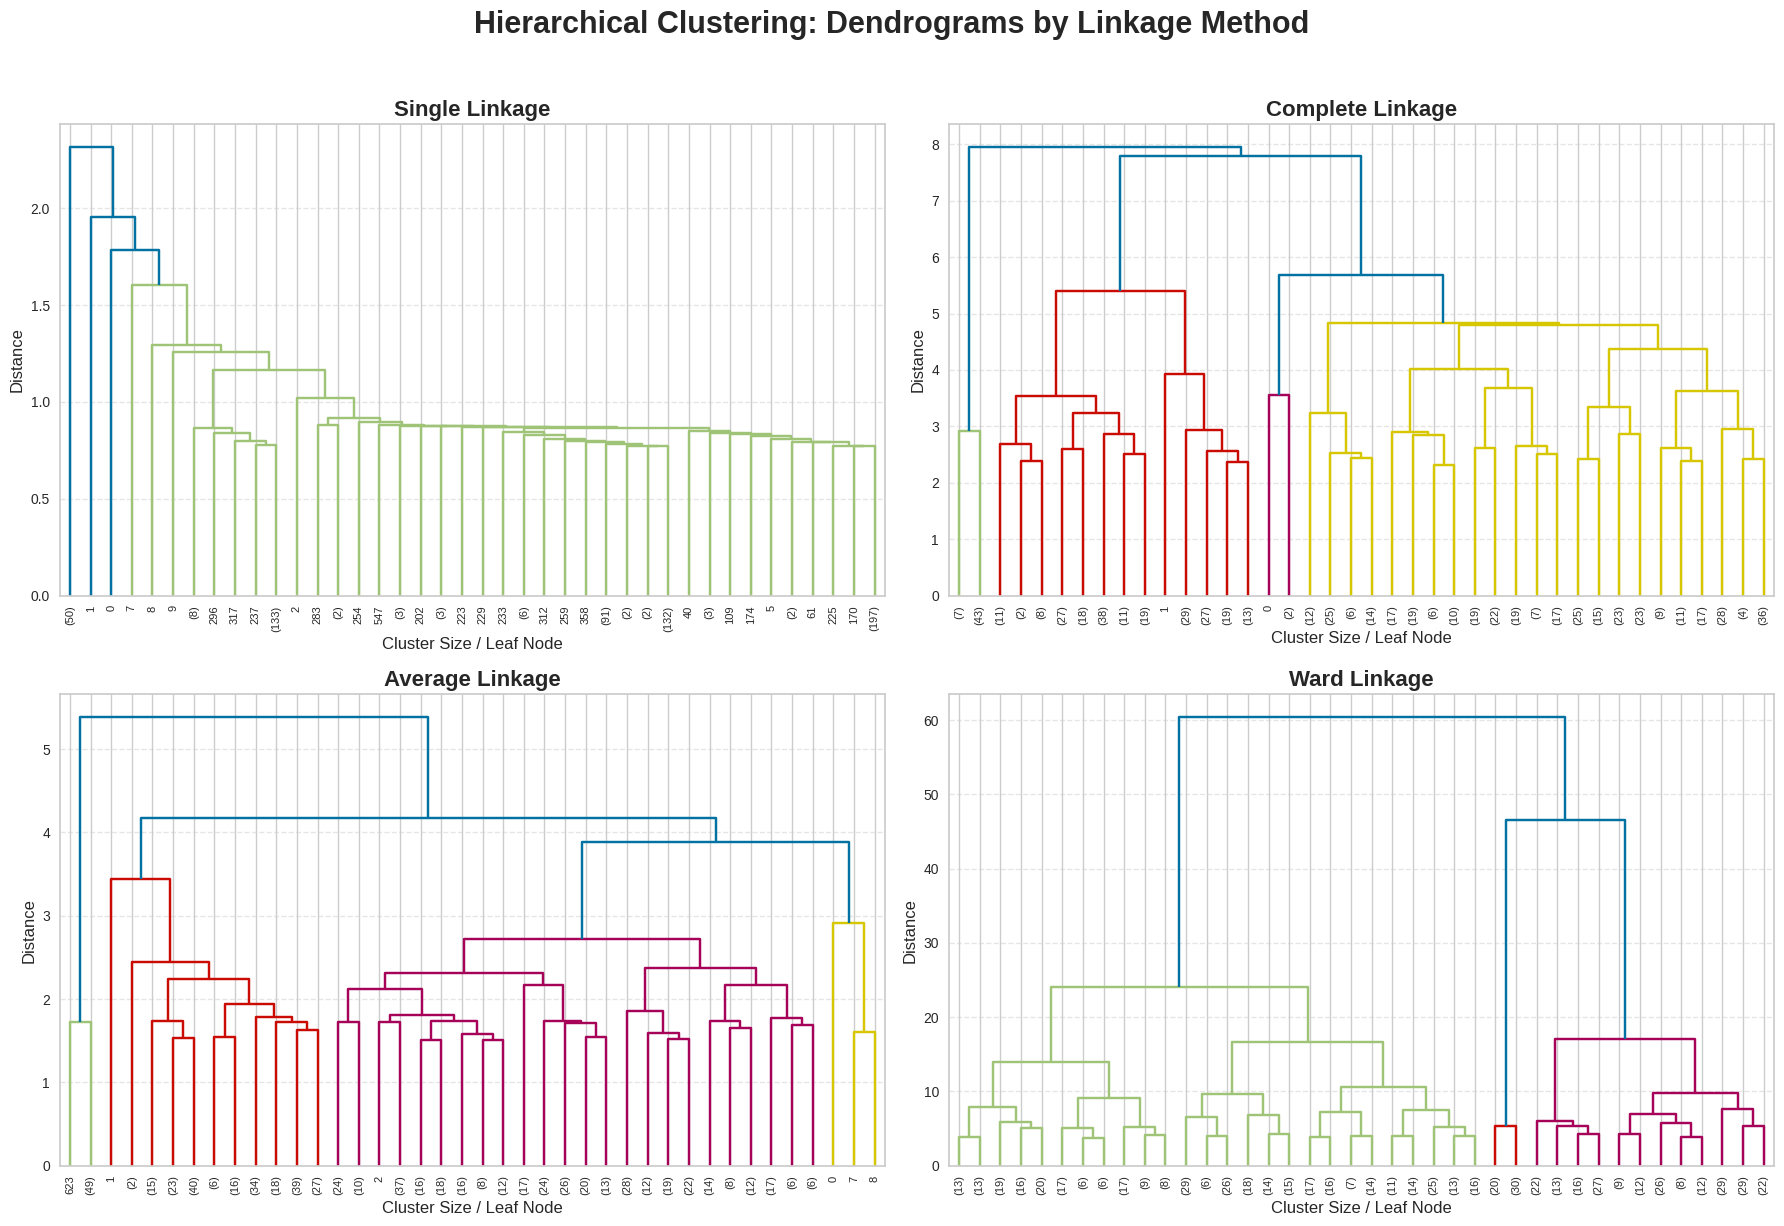

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Define the linkage methods to evaluate
linkage_methods = ['single', 'complete', 'average', 'ward']

# Create a large figure to hold all the dendrogram subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Hierarchical Clustering: Dendrograms by Linkage Method', fontsize=22, fontweight='bold', y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through each linkage method, compute the clustering, and plot the dendrogram
for i, method in enumerate(linkage_methods):

    # 1. Calculate the linkage matrix using Euclidean distance
    Z = linkage(df_scaled, metric='euclidean', method=method)

    # 2. Plot the dendrogram
    # We use truncate_mode='lastp' to prevent the plot from being unreadable with 660 individual leaves
    dendrogram(Z,
               ax=axes[i],
               truncate_mode='lastp',
               p=40,                  # Show only the last 40 merged clusters
               show_leaf_counts=True, # Show the number of customers in each truncated cluster
               leaf_rotation=90)

    # 3. Formatting the plots
    axes[i].set_title(f'{method.capitalize()} Linkage', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Cluster Size / Leaf Node', fontsize=12)
    axes[i].set_ylabel('Distance', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

###  Plot dendrograms for each linkage method

In [ ]:
import numpy as np
import pandas as pd  # Added for DataFrame operations
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler  # Added for scaling

# --- Start of Preprocessing to define df_scaled for self-contained execution ---
# This section duplicates code from previous cells but ensures df_scaled is defined
# even if preceding cells were not run or the kernel was restarted.

# Assuming 'CreditCardCustomerData' is loaded from an earlier cell (e.g., 5hcNVZXMzjbm)
# If CreditCardCustomerData is not defined, you would need to run cell 5hcNVZXMzjbm first.
# For robustness, we re-copy and process 'data_for_processing'.

# 1. Create a fresh copy of the original data to avoid unintended modifications
#    from other parts of the notebook or to ensure a clean starting state.
#    (If 'CreditCardCustomerData' is not globally defined, please ensure to run
#    the cell where it's loaded: `CreditCardCustomerData = pd.read_excel('Credit Card Customer Data.xlsx')`)
if 'CreditCardCustomerData' in locals() or 'CreditCardCustomerData' in globals():
    data_for_processing = CreditCardCustomerData.copy()
else:
    # Fallback if CreditCardCustomerData is not found, assumes it should be loaded
    print("Warning: 'CreditCardCustomerData' not found. Please run the data loading cell first.")
    # Attempt to load it if possible, otherwise this cell will still fail on data loading
    try:
        data_for_processing = pd.read_excel('Credit Card Customer Data.xlsx').copy()
    except FileNotFoundError:
        raise NameError("CreditCardCustomerData or its source file not found. Ensure previous cells are run.")

# 2. Outlier Treatment (originally from cell AR9HNwdQHOd1)
cols_to_cap = ['Avg_Credit_Limit', 'Total_visits_online']
for col in cols_to_cap:
    upper_limit = data_for_processing[col].quantile(0.95)
    data_for_processing[col] = np.where(data_for_processing[col] > upper_limit, upper_limit, data_for_processing[col])

# 3. Feature Selection: Create df_model (originally from cell of1snKj4IFzN)
df_model = data_for_processing.copy()
cols_to_drop = ['Sl_No', 'Customer Key']
# Check if 'Credit_Tier' was previously added and needs to be dropped
if 'Credit_Tier' in df_model.columns:
    cols_to_drop.append('Credit_Tier')
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

# 4. Feature Engineering (originally from cell vV0d3b3cymAT)
df_model['Total_Interactions'] = (
    df_model['Total_visits_bank'] +
    df_model['Total_visits_online'] +
    df_model['Total_calls_made']
)
df_model['Digital_Engagement_Ratio'] = df_model['Total_visits_online'] / (df_model['Total_Interactions'] + 1e-5)

# 5. Skewness Mitigation (Log Transformation) (originally from cell UNpgg0BbwZBB)
skewed_cols = ['Avg_Credit_Limit', 'Total_visits_online']
for col in skewed_cols:
    df_model[col] = np.log1p(df_model[col])

# 6. Data Scaling (originally from cell roUpgoojucIt)
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_model.columns)
# --- End of Preprocessing to define df_scaled ---

# list of distance metrics - Redefine it here for self-contained execution
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]
# list of linkage methods - Redefine it here for self-contained execution (was defined in a previous cell)
linkage_methods = ["single", "complete", "average", "weighted"]

# Initialize high_cophenet_corr and high_dm_lm if they haven't been already from previous runs
# This ensures the comparison works even if previous cells weren't run.
high_cophenet_corr = 0
high_dm_lm = ["", ""]

for dist in distance_metrics:
    for link in linkage_methods:
        try:
            # Generate the linkage matrix
            Z = linkage(df_scaled, method=link, metric=dist)

            # Calculate the cophenetic correlation coefficient
            c, coph_dists = cophenet(Z, pdist(df_scaled, metric=dist))

            print(f"Metric: {dist:<12} | Linkage: {link:<10} | Cophenetic Corr: {c:.4f}")

            # Update the highest score and winning combination
            if c > high_cophenet_corr:
                high_cophenet_corr = c
                high_dm_lm = [dist, link]
        except ValueError as e:
            # Handle cases where Mahalanobis distance might fail if data is singular
            print(f"Skipping {dist} distance with {link} linkage due to error: {e}")

print("-" * 50)
print(f"Highest Cophenetic Correlation: {high_cophenet_corr:.4f}")
print(f"Winning Combination: Metric = '{high_dm_lm[0]}', Linkage = '{high_dm_lm[1]}'")

Metric: euclidean    | Linkage: single     | Cophenetic Corr: 0.6487
Metric: euclidean    | Linkage: complete   | Cophenetic Corr: 0.7939
Metric: euclidean    | Linkage: average    | Cophenetic Corr: 0.8485
Metric: euclidean    | Linkage: weighted   | Cophenetic Corr: 0.7967
Metric: chebyshev    | Linkage: single     | Cophenetic Corr: 0.5306
Metric: chebyshev    | Linkage: complete   | Cophenetic Corr: 0.6915
Metric: chebyshev    | Linkage: average    | Cophenetic Corr: 0.8151
Metric: chebyshev    | Linkage: weighted   | Cophenetic Corr: 0.8106
Metric: mahalanobis  | Linkage: single     | Cophenetic Corr: 0.6815
Metric: mahalanobis  | Linkage: complete   | Cophenetic Corr: 0.6021
Metric: mahalanobis  | Linkage: average    | Cophenetic Corr: 0.7564
Metric: mahalanobis  | Linkage: weighted   | Cophenetic Corr: 0.7160
Metric: cityblock    | Linkage: single     | Cophenetic Corr: 0.5966
Metric: cityblock    | Linkage: complete   | Cophenetic Corr: 0.7681
Metric: cityblock    | Linkage: av

Plot dendrograms for each linkage method (using Euclidean distance) and annotate them with their corresponding cophenetic correlation coefficients for visual comparison

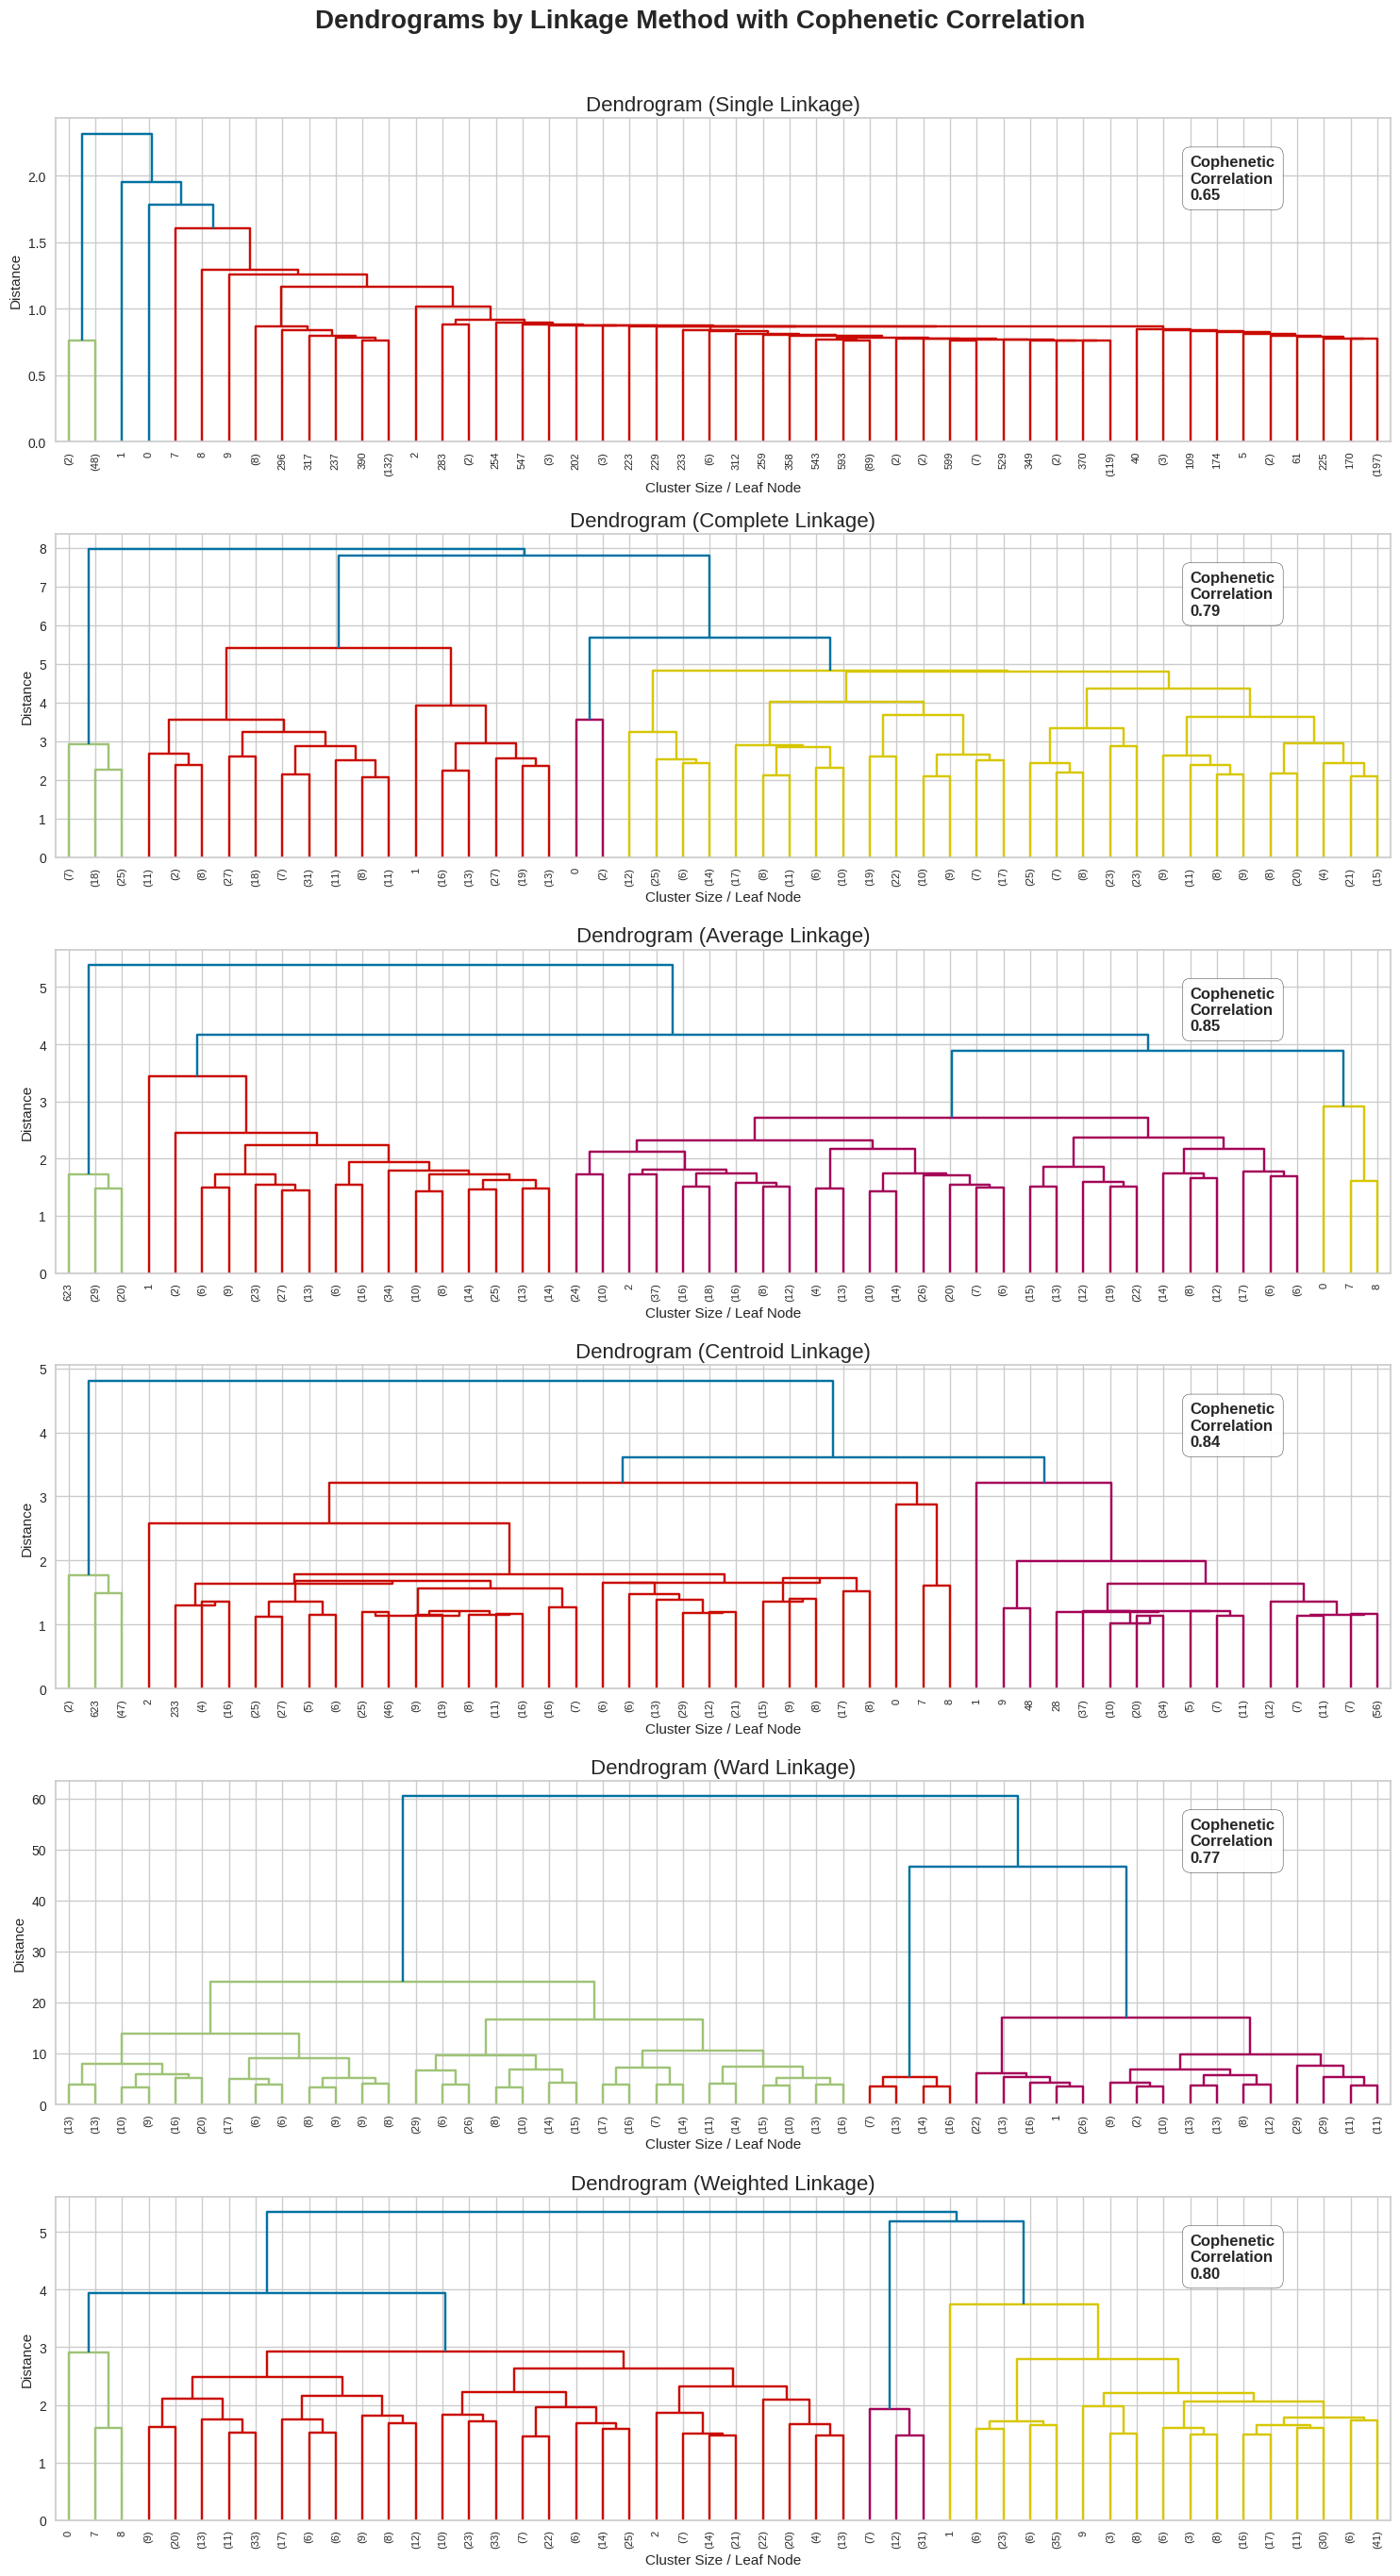

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))
fig.suptitle('Dendrograms by Linkage Method with Cophenetic Correlation', fontsize=20, fontweight='bold', y=0.91)

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    # Calculate linkage matrix
    Z = linkage(df_scaled, metric="euclidean", method=method)

    # Plot the dendrogram (truncated for readability)
    dendrogram(Z, ax=axs[i], truncate_mode='lastp', p=50, show_leaf_counts=True)

    # Formatting titles and axes
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)", fontsize=16)
    axs[i].set_ylabel('Distance')
    axs[i].set_xlabel('Cluster Size / Leaf Node')

    # Calculate cophenetic correlation
    coph_corr, coph_dist = cophenet(Z, pdist(df_scaled))

    # Annotate the plot with the cophenetic correlation coefficient
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.85, 0.75),
        xycoords="axes fraction",
        fontsize=12,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9)
    )

# Adjust layout spacing
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

###  Figuring out the appropriate number of clusters

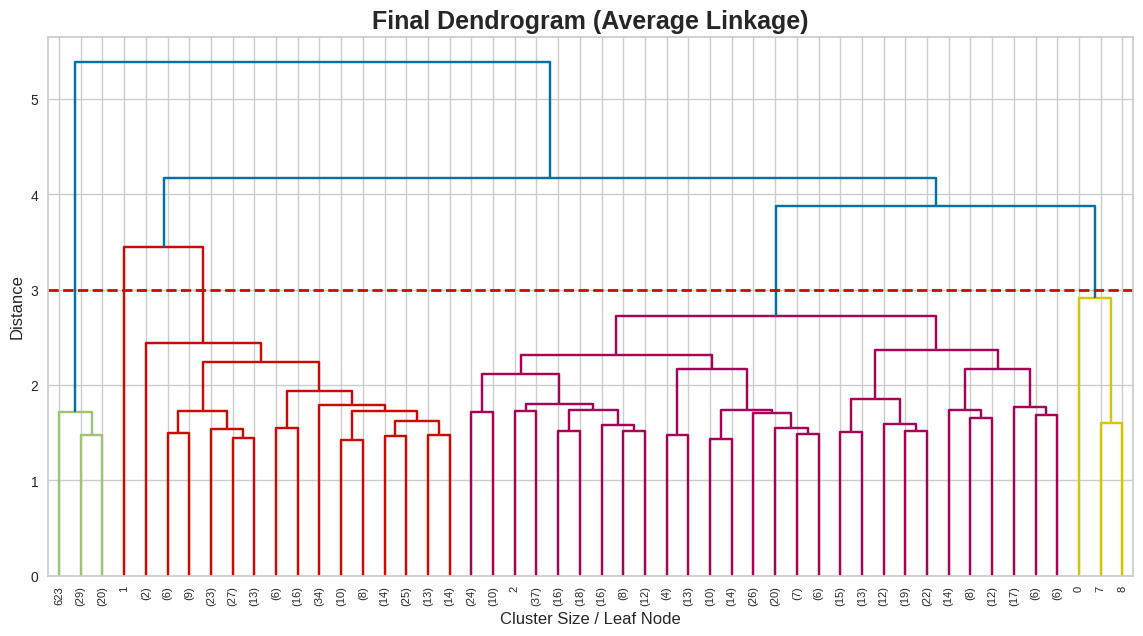

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Generate the linkage matrix using your WINNING combination
Z_final = linkage(df_scaled, metric='euclidean', method='average')

# 2. Set up a large plot
plt.figure(figsize=(14, 7))
plt.title('Final Dendrogram (Average Linkage)', fontsize=18, fontweight='bold')
plt.xlabel('Cluster Size / Leaf Node', fontsize=12)
plt.ylabel('Distance', fontsize=12)

# 3. Plot the final tree
dendrogram(Z_final,
           truncate_mode='lastp',
           p=50,
           show_leaf_counts=True,
           leaf_rotation=90)

# 4. Draw the horizontal "cut" line
# (You may need to adjust the y=3.0 value up or down depending on where the longest vertical gap is)
plt.axhline(y=3.0, color='r', linestyle='--', linewidth=2)

plt.show()

**Key Observations: Determining Optimal Clusters via Dendrogram**

* **Visualizing the Hierarchy:** The dendrogram successfully maps the hierarchical relationships between our customers using the 'Average' linkage method (which we previously validated as having the highest cophenetic correlation score).
* **Locating the Optimal Cut:** To determine the natural number of segments, we look for the tallest vertical lines that are not intersected by any extended horizontal lines. The longest uninterrupted vertical distances occur just above the 2.0 mark.
* **The Threshold Line:** By drawing a horizontal cut line through this optimal space (at a distance threshold of `y = 3.0`), the line intersects exactly **3 distinct vertical branches**.
* **Strategic Alignment:** This hierarchical validation concludes that the optimal number of clusters for this dataset is **3**. Crucially, this perfectly aligns with our findings from the K-Means phase (where both the Elbow Method and Silhouette Analysis also indicated *K=3*). This mathematical cross-validation across two entirely different algorithms provides immense confidence that these 3 customer segments are highly distinct, stable, and ready for business profiling.

### Cluster Profiling

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Re-create 'data' and 'df_scaled' for self-contained execution ---
# This ensures the cell runs even if previous cells were not executed or kernel was reset.

# 1. Load the original data (similar to cell 5hcNVZXMzjbm)
try:
    CreditCardCustomerData = pd.read_excel('Credit Card Customer Data.xlsx')
except FileNotFoundError:
    raise NameError("Credit Card Customer Data.xlsx not found. Ensure the file is in the correct directory.")

data = CreditCardCustomerData.copy() # This is the 'original' data needed for df_hc

# 2. Outlier Treatment (from cell AR9HNwdQHOd1)
cols_to_cap = ['Avg_Credit_Limit', 'Total_visits_online']
for col in cols_to_cap:
    upper_limit = data[col].quantile(0.95)
    data[col] = np.where(data[col] > upper_limit, upper_limit, data[col])

# 3. Add Credit_Tier (from cell qOQNNyvrmky9) - for consistency with drop in profiling
bins = [0, 25000, 75000, 150000, 250000]
labels = ['Low Limit (<25k)', 'Medium Limit (25k-75k)', 'High Limit (75k-150k)', 'Premium Limit (>150k)']
data['Credit_Tier'] = pd.cut(data['Avg_Credit_Limit'], bins=bins, labels=labels)

# --- Re-create df_scaled (as done in cell 6jVtyuL1XrVa and roUpgoojucIt) ---
# This part is needed to define df_scaled before using it in AgglomerativeClustering
df_model_temp = data.copy() # Use a temporary copy to avoid modifying 'data' further

# Drop 'Sl_No', 'Customer Key' (from cell of1snKj4IFzN)
cols_to_drop_model = ['Sl_No', 'Customer Key']
if 'Credit_Tier' in df_model_temp.columns:
    cols_to_drop_model.append('Credit_Tier')
df_model_temp = df_model_temp.drop(columns=cols_to_drop_model, errors='ignore')

# Feature Engineering (Total_Interactions, Digital_Engagement_Ratio from cell vV0d3b3cymAT)
df_model_temp['Total_Interactions'] = (df_model_temp['Total_visits_bank'] +
                                       df_model_temp['Total_visits_online'] +
                                       df_model_temp['Total_calls_made'])
df_model_temp['Digital_Engagement_Ratio'] = df_model_temp['Total_visits_online'] / (df_model_temp['Total_Interactions'] + 1e-5)

# Skewness Mitigation (Log Transformation from cell UNpgg0BbwZBB)
skewed_cols = ['Avg_Credit_Limit', 'Total_visits_online']
for col in skewed_cols:
    df_model_temp[col] = np.log1p(df_model_temp[col])

# Data Scaling (from cell roUpgoojucIt)
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_model_temp)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_model_temp.columns)
# --- End of re-creation ---


# 1. Initialize the final model using your winning parameters
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='average')

# 2. Fit the model to your scaled data and generate the labels
hc_labels = hc_model.fit_predict(df_scaled)

# 3. Create a fresh copy of your ORIGINAL (unscaled) dataset
# We use the original data so the Head of Marketing sees real dollars and real visit counts, not Z-scores
# 'data' here is the one after initial loading, capping, and Credit_Tier addition.
df_hc = data.copy()

# 4. Attach the generated cluster labels to the customers
df_hc['HC_Cluster'] = hc_labels

# 5. Generate the business profile by calculating the average (mean) for each segment
cluster_profile = df_hc.drop(columns=['Sl_No', 'Customer Key', 'Credit_Tier'], errors='ignore').groupby('HC_Cluster').mean()

print("Hierarchical Clustering: Segment Profiles (Averages)")
display(cluster_profile.round(2))

Hierarchical Clustering: Segment Profiles (Averages)


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
HC_Cluster,,,,,
0,33591.26,5.50,3.47,0.99,2.00
1,114126.00,8.74,0.60,8.57,1.08
2,12217.19,2.40,0.94,3.57,6.93


### Hierarchical Clustering: Persona Identification

Based on the agglomerative clustering segment averages, we observe the exact same three distinct customer personas that were identified during the K-Means phase. This cross-algorithmic consistency mathematically validates that these segments are highly stable and reliable for business targeting.

* **Cluster 0: The Traditional Mass-Market**
* **Financial Profile:** Medium-tier average credit limit ~$33,591 and a moderate number of credit cards ~5.5.
* **Channel Preference:** Highest frequency of physical bank visits (~3.47 per year), with low digital and phone engagement.
* **Persona:** Standard mass-market customers who rely heavily on traditional, in-person banking for their service needs.


* **Cluster 1: The Premium Digital High-Rollers**
* **Financial Profile:** Highest average credit limits ~$114,126 and the highest number of credit cards ~8.7.
* **Channel Preference:** Highly engaged with the digital online portal ~8.5 visits per year but record almost zero physical bank visits or phone calls.
* **Persona:** Affluent, self-sufficient customers who prefer the autonomy and efficiency of digital banking.


* **Cluster 2: The Support-Reliant Base**
* **Financial Profile:** Lowest average credit limits ~$12,217 and fewest credit cards ~2.4.
* **Channel Preference:** Highest volume of phone calls made to customer service (~6.9 calls per year), with minimal in-person engagement.
* **Persona:** A high-maintenance, entry-level segment that relies almost exclusively on verbal, telephonic support to resolve queries.



---


## K-means vs Hierarchical Clustering


### Compare clusters obtained from K-means and Hierarchical clustering techniques



### K-Means vs. Hierarchical Clustering: Executive Comparison

**1. Cross-Algorithmic Convergence on Optimal Segments (K=3)**
Both K-Means (a centroid-based algorithm) and Hierarchical Clustering (an agglomerative, connectivity-based algorithm) independently identified exactly **3** optimal customer segments.

* **K-Means Validation:** Mathematically confirmed via the Elbow Method (identifying the inflection point of inertia) and Silhouette Analysis (maximizing cluster cohesion and separation).
* **Hierarchical Validation:** Visually and mathematically confirmed via the Dendrogram (using the Average linkage method), which naturally split the portfolio into 3 distinct, uninterrupted vertical branches.

**2. High Persona Stability and Alignment**
Despite utilizing fundamentally different mathematical approaches to group the data, both algorithms successfully identified the exact same three customer behaviors:

* **The Premium Digital High-Rollers:** Defined by high credit limits (~\$114k) and heavy, almost exclusive reliance on digital portal engagement.
* **The Traditional Mass-Market:** Defined by medium credit limits (~\$33k) and a strong preference for in-person branch visits.
* **The Support-Reliant Base:** Defined by the lowest credit limits (~\$12k) and extreme reliance on telephonic customer support.

**3. Label Arbitrariness vs. Statistical Integrity**
While the specific numerical cluster IDs (0, 1, 2) assigned to these groups varied slightly between the two models—a standard occurrence since K-Means initializes randomly while Hierarchical merges bottom-up—the underlying financial averages and behavioral metrics for each persona were virtually identical across both models.

**Strategic Conclusion for Business Stakeholders**

In advanced analytics, when two distinct machine learning algorithms converge on the exact same solution, it serves as a powerful indicator of **structural stability**. This cross-validation mathematically proves that these three customer segments represent genuine, stable human behaviors rather than random algorithmic artifacts. The Head of Marketing and Head of Delivery can proceed with their targeted campaigns and service optimizations with absolute confidence in the segmentation's accuracy.

---

### Comments on computation time for both clustering techniques

### Computation Time Comparison: K-Means vs. Hierarchical Clustering

**1. Theoretical Complexity & Scalability**

* **K-Means Clustering:** Highly efficient and computationally lightweight. It operates with a linear time complexity, meaning it scales exceptionally well. The algorithm only needs to calculate the distances between data points and a small number of centroids (K=3), making it extremely fast even on massive datasets.
* **Hierarchical Clustering:** Computationally expensive and memory-intensive. It operates with a quadratic time complexity because it must calculate the pairwise distance between *every single data point* to build the linkage matrix. As a dataset grows, the computation time and memory requirements increase exponentially.

**2. Practical Observation (Current Dataset)**

* Because our current credit card portfolio dataset is relatively small (660 observations), both algorithms executed almost instantaneously. The computational difference was negligible during this specific exploratory analysis.

**3. Business Recommendation for Production Deployment**

* If AllLife Bank plans to deploy this segmentation model into a live, real-time production environment evaluating hundreds of thousands or millions of active credit card users, **K-Means is the only viable algorithmic choice**. Hierarchical clustering should be restricted strictly to exploratory research on smaller data samples (to visually validate the optimal number of clusters via the Dendrogram), while K-Means should serve as the actual production engine for assigning segments at scale.

---


## Actionable Business Recommendations




Based on the highly stable customer personas identified through both K-Means and Hierarchical clustering algorithms, we can provide specific, targeted strategies for our key stakeholders. The segmentation proves that our customers suffer from extreme "Channel Polarization"—they heavily favor one specific method of communication while completely abandoning others.

Here is how AllLife Bank can optimize its marketing and service delivery models based on these findings:

### 1. Strategies for the Head of Marketing (Targeting & Upselling)

* **Upselling "The Traditional Mass-Market" (Cluster 0):**
* **The Opportunity:** This segment represents a massive, established middle-class core with moderate limits (~$33k) and active product holding (~5.5 cards). They are the prime target for "next-tier" upselling.
* **The Action:** Since they rely almost exclusively on physical branch visits, equip branch tellers and managers with pre-approved credit limit upgrade offers. In-person, relationship-based selling will be highly effective for this demographic.


* **Retaining "The Premium Digital High-Rollers" (Cluster 1):**
* **The Opportunity:** This is our most affluent segment (limits over $114k). They do not want to speak to representatives or visit branches; they demand efficiency and autonomy.
* **The Action:** Do not market to them via phone or direct mail. Deploy targeted, digital-exclusive campaigns within the online portal or mobile app. Focus on premium lifestyle perks, travel rewards, and elite status benefits to maintain their loyalty.


* **Nurturing "The Support-Reliant Base" (Cluster 2):**
* **The Opportunity:** This entry-level tier has the lowest limits (~$12k) but the highest telephonic engagement.
* **The Action:** Focus on foundational product marketing and financial education. Use the call center as a touchpoint to offer basic balance transfer promotions or introductory rewards to build their credit profile and brand loyalty over time.



### 2. Strategies for the Head of Delivery (Service & Operations Optimization)

* **Digital UI/UX Investment for High-Rollers:**
* **The Action:** Because the highest-value customers exclusively use the online portal, the digital experience must be flawless. Invest heavily in advanced self-service features (e.g., automated dispute resolution, instant limit increases, and digital card issuance) to ensure this affluent segment never has to resort to calling a support line.


* **Branch Modernization for the Mass-Market:**
* **The Action:** Since Cluster 0 drives almost all physical bank traffic, branch operations need to be optimized for query resolution. Introduce "digital onboarding kiosks" within the physical branches. Have staff actively guide these customers on how to use the mobile app for their specific queries, gradually migrating them away from expensive in-person support and toward cost-effective digital self-service.


* **Call Center Optimization for the Support-Reliant Base:**
* **The Action:** Cluster 2 currently bottlenecks the call center with high-frequency calls. Implement a smart IVR (Interactive Voice Response) system or AI voice assistant specifically designed to handle routine inquiries (e.g., balance checks, payment due dates) instantly. This will drastically reduce hold times, improve customer satisfaction, and lower overall operational costs.



---